# WARNING
fenotag gpio=1st

# START

In [1]:
import pandas as pd
import numpy as np
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
import re
import ast
from itertools import product
from scipy.spatial.distance import cdist # Added for cdist

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, accuracy_score # Added accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# from keras.models import Sequential
# from keras.layers import Dense, Dropout
# from keras.utils import to_categorical
# from sklearn.metrics import classification_report, accuracy_score

# from keras.models import Sequential, Model
# from keras.layers import Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten
# from keras.utils import to_categorical, set_random_seed

# from keras.optimizers import Adam
# from keras.callbacks import ModelCheckpoint, EarlyStopping

#
import tensorflow as tf
from keras.utils import set_random_seed, to_categorical
from keras.models import Sequential, Model
from keras.layers import (Dense, Dropout, Input, Conv1D, Conv2D, MaxPooling1D, MaxPooling2D,
                          Flatten, Reshape, LSTM, SpatialDropout2D, BatchNormalization, concatenate)
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2
from keras.constraints import max_norm
#

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import json
from json import loads, dumps

from scipy.signal import find_peaks

def get_nearest_antenna(points, antennas):
    # Returns index of nearest antenna for each point
    dists = cdist(points, antennas)
    return np.argmin(dists, axis=1)


In [2]:


import sklearn
sklearn.__version__

'1.6.1'

file.split('__')[-1].rstrip('.csv')

In [3]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Apr 25 20:30:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
os.getcwd()

'/content'

In [7]:
os.listdir()

['.config', 'drive', 'sample_data']

In [8]:
os.listdir('drive')

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']

In [9]:
# os.listdir('drive/MyDrive')

In [10]:
%cd 'drive/MyDrive/RTLS_SF'

/content/drive/MyDrive/RTLS_SF


In [11]:
os.listdir()

['notebook',
 'raw_data',
 'rtls.xlsx',
 'HQ 21Jan.csv',
 '10.160.230.78.csv',
 '10.160.230.84.csv',
 'final_dataset.csv',
 'final_dataset_foam.csv',
 'ds_basic_17Feb26.csv',
 'ds_advanced_17Feb26.csv',
 'ds_basic_18Feb26.csv',
 'ds_advanced_18Feb26.gsheet',
 'ds_9March26.csv',
 'ds_advanced_18Feb26.csv',
 'ds_Tx.csv',
 'ds_Tx_Rx.csv',
 'Actuals.csv',
 'HQ STAR3K RTLS Layout.pptx',
 'ds_power_tx_rx_freq.csv',
 'tags_pick_power_tx_rx_freq.csv',
 'ds_elemen.csv']

# RFID data

pathfiles

# PX2025 & HQ

In [12]:


# Pathfiles_dict = {\

#       # ESISAR PX small room, square2m
#       'ConfID=2025-10-21 14h00__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=esisar__antConf=floor__ antSep=2m__antTilt=0':\
#       {'Reader=SF__Session=S0__Power=30dBm__Q=4':\
#            [ 'id=2025-10-21 16h00'],\
#       },\

#       # ESISAR PX small room, colocated antennas in NSEW
#       # 'ConfID=2025-11-18__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=esisar__antConf=floor__ antSep=0m__antTilt=45':\
#       # {'Reader=SF__Session=S0__Power=30dBm__Q=4':\
#       #      [ 'id=2025-11-18 14h00'],\
#       #  },\

#       # ESISAR PX anechoic chamber, colocated antennas in NSEW
#       #  'ConfID=2025-12-02__Item=foam__Qtags=10__Carrier=sapiens__Speed=static__Site=anechoic_esisar__antConf=floor__ antSep=0m__antTilt=45':\
#       #  {'Reader=SF__Session=S0__Power=30dBm__Q=6':\
#       #       [ 'id=2025-12-02 14h00'],\
#       #  },\

#       # HQ
#       # 'ConfID=2025-12-10__Item=cardboard__Qtags=20__antQ=8__Site=AcceliotIncHQ':\
#       # {'Reader=SF__Session=S?__Power=30dBm__Q=?':\
#       #      [ 'id=2025-12-10'],\
#       # },\
#       #'ConfID=2026-01-21__obj=test__Item=cardboard__Qtags=20__antQ=8__Site=AcceliotIncHQ':\
#       #{'Reader=SF__Session=S1__Power=31.5dBm':\
#       #     [ 'id=2026-01-21 22h'],\
#       # },\
#                  }


# SuitSupply

In [ ]:
Pathfiles_dict = {\

#       # SS

      # 'ConfID=2026-01-29__site=SuitSupply_Paris__zone=FOH__reader=SF8' :
#       {'pgm=mojixMCON':\
#           ['id=2026-02-01'],\
#       },\
#                   }
# Pathfiles_dict = {\

#       # SS

      'ConfID=2026-02-19__site=SuitSupply__SF=SF8' :

      {'pgm=AEP__Q=5-10':\
          ['id=2026-02-19 00h15'],\
      },\

      # 30min run S1Q8
      # {'pgm=AEP__Q=8__session=S1':\
      #     ['id=2026-02-20'],\
      # },\

                 }


# HQ 1 tower

In [13]:
Pathfiles_dict = {\

      # HQ

      'ConfID=2026-02-03__site=HQ' :
      {'pgm=AEP_OK':\
          ['id=2026-02-04', 'id=2026-02-05', 'id=2026-02-06', 'id=2026-02-10', 'id=2026-02-11', 'id=2026-02-12', 'id=2026-02-13', 'id=2026-02-17'],\
      },\

      # Q
      # {'pgm=AEP__Q=5-10':\
      #     ['id=2026-02-20'],\
      # },\

      # s2q8 basic
      #  {'pgm=basic__session=s1s2__q=8':\
      #     ['id=2026-02-22'],\
      # },\

#     adjSF + 1000 tags, id=2026-02-21 10h00=3min, id=2026-02-21 11h00=30min
      # 'ConfID=2026-02-21__Qtags=1000__adjSF=True__site=HQ' :
      # {'pgm=AEP__session=1__q=8':\
      #     ['id=2026-02-21 11h00'],\
      # },\
                  }

# raw data

HQ: runs (x,y,z0), Actuals (z_rel)

In [122]:
RoundStart = pd.DataFrame()
gpio = pd.DataFrame()
Runs = []
tags = pd.DataFrame()
Actuals = pd.DataFrame()

for Conf in Pathfiles_dict.keys():
  #print(Conf)
  for Reader in Pathfiles_dict[Conf].keys():
    #print(Reader)
    settings_Conf_Reader = Conf + '__' + Reader
    # print(settings_Conf_Reader)
    for runID in Pathfiles_dict[Conf][Reader]:
      #print(runID)
      settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID

      pathfile = os.path.join ('raw_data', Conf, Reader, runID)
      # print(os.listdir(pathfile))
      for file in os.listdir(pathfile):
        print(file)
        if file.endswith('txt'):
      # print(file)
          settings = settings_Conf_Reader_runID + '__' + file.rstrip('.txt')
          #print(settings)
          settings = [x.split('=') for x in settings.split('__') ]
          #print(settings)
          settings = {key:value for key, value in settings}
      # print(settings)
          filename = os.path.join(pathfile, file)
          errors_json=0
          counter_lines=0
          with open(filename, 'rt') as lines:
            run=0
            tags_run=[]
            RoundStart_run=[]
            gpio_run=[]

            for line in lines:
              if line.startswith('data: '):
                data_str = line.split('data: ')[1]
                try:
                  data_json = json.loads(data_str)
                  if run==0:
                    run=data_json['datestamp']
                    run=pd.to_datetime(run, format='%y/%m/%d %H:%M:%S.%f').round('1s')
                    #print(run)
                    settings['run']=run

                  if data_json['type']=='RoundStart':
                    RoundStart_run.append(data_json)
                  if data_json['type']=='TagReadData':
                    tags_run.append(data_json)
                  if data_json['type']=='SensorData':
                    gpio_run.append(data_json)
                except:
                  errors_json += 1
        # print(tags_run)
            tags_run = pd.DataFrame(tags_run)
            tags_run['run'] = run
        # ConfID = settings['ConfID']
        # tags_run['ConfID'] = ConfID
    #
        # for key, value in settings.items():
        #   tags_run[key] = value

            Runs.append(settings)

            tags = pd.concat([tags, tags_run])
            RoundStart_run = pd.DataFrame(RoundStart_run)
            RoundStart_run['run'] = run
        # RoundStart_run['ConfID'] = ConfID
            RoundStart = pd.concat([RoundStart, RoundStart_run])
            gpio_run = pd.DataFrame(gpio_run)
            gpio_run['run'] = run
        # gpio_run['ConfID'] = ConfID
            gpio = pd.concat([gpio, gpio_run])

      #print(errors_json)
  #
  # Actuals
  #
  pathfile_Actuals = os.path.join ('raw_data', Conf, 'Actuals')
  #print(pathfile_Actuals)

  for file in os.listdir(pathfile_Actuals):
    print(file)
    filename = os.path.join(pathfile_Actuals, file)
    settings_temp = {x.split('=')[0] : x.split('=')[1]  for x in file.rstrip('.csv').split('__')}
    # Actuals with labelled columns (EPC, x, y, z) or without label (EPC list only )
    Actuals_temp = pd.read_csv(filename, sep=';', dtype=str, decimal=',')
    for key, value in settings_temp.items():
      Actuals_temp[key] = value
    ConfID=settings['ConfID']
    Actuals_temp['ConfID']=ConfID
    Actuals = pd.concat([Actuals, Actuals_temp])
  print(Actuals.shape)
  #
  # antConf
  #
  pathfile_antConf = os.path.join ('raw_data', Conf, 'antConf')
  file = os.listdir(pathfile_antConf)[0]
  filename = os.path.join(pathfile_antConf, file)
  #print(filename)
  antConf = pd.read_csv(filename, sep=';', decimal=',')
  # print(antConf.shape)

x=1.82__y=2.51__z0=0__P=31.5.txt
x=1.82__y=2.51__z0=0__P=27.txt
x=1.82__y=2.51__z0=0__P=24.txt
x=3.76__y=3.33__z0=0__P=31.5.txt
x=3.76__y=3.33__z0=0__P=27.txt
x=3.76__y=3.33__z0=0__P=24.txt
x=5.49__y=4.30__z0=0__P=31.5.txt
x=5.49__y=4.30__z0=0__P=27.txt
x=5.49__y=4.30__z0=0__P=24.txt
x=7.73__y=4.45__z0=0__P=31.5.txt
x=7.73__y=4.45__z0=0__P=27.txt
x=7.73__y=4.45__z0=0__P=24.txt
x=8.50__y=2.55__z0=0__P=31.5.txt
x=8.50__y=2.55__z0=0__P=27.txt
x=8.50__y=2.55__z0=0__P=24.txt
x=8.87__y=4.79__z0=0__P=31.5.txt
x=8.87__y=4.79__z0=0__P=27.txt
x=8.87__y=4.79__z0=0__P=24.txt
x=11.23__y=3.36__z0=0__P=31.5.txt
x=11.23__y=3.36__z0=0__P=27.txt
x=11.23__y=3.36__z0=0__P=24.txt
x=12.91__y=3.39__z0=0__P=31.5.txt
x=12.91__y=3.39__z0=0__P=27.txt
x=12.91__y=3.39__z0=0__P=24.txt
x=14.53__y=1.52__z0=0__P=31.5.txt
x=14.53__y=1.52__z0=0__P=27.txt
x=14.53__y=1.52__z0=0__P=24.txt
x=14.30__y=3.59__z0=0__P=31.5.txt
x=14.30__y=3.59__z0=0__P=27.txt
x=14.30__y=3.59__z0=0__P=24.txt
x=0.58__y=3.17__z0=0__P=31.5.txt
x=0.5

In [123]:
# import os
# import json
# import pandas as pd

# RoundStart = pd.DataFrame()
# gpio = pd.DataFrame()
# Runs = []
# tags = pd.DataFrame()
# Actuals = pd.DataFrame()

# for Conf in Pathfiles_dict.keys():
#     for Reader in Pathfiles_dict[Conf].keys():
#         settings_Conf_Reader = Conf + '__' + Reader

#         for runID in Pathfiles_dict[Conf][Reader]:
#             settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID
#             pathfile = os.path.join('raw_data', Conf, Reader, runID)

#             # Skip missing folders
#             if not os.path.isdir(pathfile):
#                 print(f"Skipping missing folder: {pathfile}")
#                 continue

#             for file in os.listdir(pathfile):
#                 print(file)

#                 if file.endswith('.txt'):
#                     # safer than rstrip('.txt')
#                     file_stem = os.path.splitext(file)[0]

#                     settings_str = settings_Conf_Reader_runID + '__' + file_stem
#                     settings = [x.split('=', 1) for x in settings_str.split('__') if '=' in x]
#                     settings = {key: value for key, value in settings}

#                     filename = os.path.join(pathfile, file)
#                     errors_json = 0

#                     with open(filename, 'rt') as lines:
#                         run = 0
#                         tags_run = []
#                         RoundStart_run = []
#                         gpio_run = []

#                         for line in lines:
#                             if line.startswith('data: '):
#                                 data_str = line.split('data: ', 1)[1]

#                                 try:
#                                     data_json = json.loads(data_str)

#                                     if run == 0:
#                                         run = data_json['datestamp']
#                                         run = pd.to_datetime(
#                                             run,
#                                             format='%y/%m/%d %H:%M:%S.%f',
#                                             errors='coerce'
#                                         )
#                                         if pd.notna(run):
#                                             run = run.round('1s')
#                                         settings['run'] = run

#                                     if data_json.get('type') == 'RoundStart':
#                                         RoundStart_run.append(data_json)

#                                     elif data_json.get('type') == 'TagReadData':
#                                         tags_run.append(data_json)

#                                     elif data_json.get('type') == 'SensorData':
#                                         gpio_run.append(data_json)

#                                 except Exception:
#                                     errors_json += 1

#                     Runs.append(settings)

#                     # Tags
#                     tags_run = pd.DataFrame(tags_run)
#                     if not tags_run.empty:
#                         tags_run['run'] = run
#                         for key, value in settings.items():
#                             tags_run[key] = value
#                         tags = pd.concat([tags, tags_run], ignore_index=True)

#                     # RoundStart
#                     RoundStart_run = pd.DataFrame(RoundStart_run)
#                     if not RoundStart_run.empty:
#                         RoundStart_run['run'] = run
#                         for key, value in settings.items():
#                             RoundStart_run[key] = value
#                         RoundStart = pd.concat([RoundStart, RoundStart_run], ignore_index=True)

#                     # GPIO
#                     gpio_run = pd.DataFrame(gpio_run)
#                     if not gpio_run.empty:
#                         gpio_run['run'] = run
#                         for key, value in settings.items():
#                             gpio_run[key] = value
#                         gpio = pd.concat([gpio, gpio_run], ignore_index=True)

#                     if errors_json > 0:
#                         print(f"{errors_json} JSON parse errors in {filename}")

#     # =========================
#     # Actuals
#     # =========================
#     pathfile_Actuals = os.path.join('raw_data', Conf, 'Actuals')

#     if os.path.isdir(pathfile_Actuals):
#         for file in os.listdir(pathfile_Actuals):
#             print(file)

#             if file.endswith('.csv'):
#                 filename = os.path.join(pathfile_Actuals, file)

#                 # safer than rstrip('.csv')
#                 file_stem = os.path.splitext(file)[0]
#                 settings_temp = {
#                     x.split('=', 1)[0]: x.split('=', 1)[1]
#                     for x in file_stem.split('__')
#                     if '=' in x
#                 }

#                 Actuals_temp = pd.read_csv(
#                     filename,
#                     sep=';',
#                     dtype=str,
#                     decimal=','
#                 )

#                 for key, value in settings_temp.items():
#                     Actuals_temp[key] = value

#                 # use ConfID from settings_temp, not from old "settings"
#                 Actuals_temp['ConfID'] = settings_temp.get('ConfID', None)

#                 Actuals = pd.concat([Actuals, Actuals_temp], ignore_index=True)

#         print("Actuals shape:", Actuals.shape)
#     else:
#         print(f"Missing Actuals folder: {pathfile_Actuals}")

#     # =========================
#     # antConf
#     # =========================
#     pathfile_antConf = os.path.join('raw_data', Conf, 'antConf')

#     if os.path.isdir(pathfile_antConf):
#         antconf_files = os.listdir(pathfile_antConf)

#         if len(antconf_files) > 0:
#             file = antconf_files[0]
#             filename = os.path.join(pathfile_antConf, file)
#             antConf = pd.read_csv(filename, sep=';', decimal=',')
#             print("antConf shape:", antConf.shape)
#         else:
#             print(f"No files found in antConf folder: {pathfile_antConf}")
#     else:
#         print(f"Missing antConf folder: {pathfile_antConf}")

In [124]:
# RoundStart = pd.DataFrame()
# gpio = pd.DataFrame()
# Runs = []
# tags = pd.DataFrame()
# Actuals = pd.DataFrame()

# for Conf in Pathfiles_dict.keys():
#   #print(Conf)
#   for Reader in Pathfiles_dict[Conf].keys():
#     #print(Reader)
#     settings_Conf_Reader = Conf + '__' + Reader
#     # print(settings_Conf_Reader)
#     for runID in Pathfiles_dict[Conf][Reader]:
#       #print(runID)
#       settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID

#       pathfile = os.path.join ('raw_data', Conf, Reader, runID)
#       # print(os.listdir(pathfile))
#       for file in os.listdir(pathfile):
#         print(file)
#         if file.endswith('txt'):
#       # print(file)
#           settings = settings_Conf_Reader_runID + '__' + file.rstrip('.txt')
#           #print(settings)
#           settings = [x.split('=') for x in settings.split('__') ]
#           #print(settings)
#           settings = {key:value for key, value in settings}
#       # print(settings)
#           filename = os.path.join(pathfile, file)
#           errors_json=0
#           counter_lines=0
#           with open(filename, 'rt') as lines:
#             run=0
#             tags_run=[]
#             RoundStart_run=[]
#             gpio_run=[]

#             for line in lines:
#               if line.startswith('data: '):
#                 data_str = line.split('data: ')[1]
#                 try:
#                   data_json = json.loads(data_str)
#                   if run==0:
#                     run=data_json['datestamp']
#                     run=pd.to_datetime(run, format='%y/%m/%d %H:%M:%S.%f').round('1s')
#                     #print(run)
#                     settings['run']=run

#                   if data_json['type']=='RoundStart':
#                     RoundStart_run.append(data_json)
#                   if data_json['type']=='TagReadData':
#                     tags_run.append(data_json)
#                   if data_json['type']=='SensorData':
#                     gpio_run.append(data_json)
#                 except:
#                   errors_json += 1
#         # print(tags_run)
#             tags_run = pd.DataFrame(tags_run)
#             tags_run['run'] = run
#         # ConfID = settings['ConfID']
#         # tags_run['ConfID'] = ConfID
#     #
#         # for key, value in settings.items():
#         #   tags_run[key] = value

#             Runs.append(settings)

#             tags = pd.concat([tags, tags_run])
#             RoundStart_run = pd.DataFrame(RoundStart_run)
#             RoundStart_run['run'] = run
#         # RoundStart_run['ConfID'] = ConfID
#             RoundStart = pd.concat([RoundStart, RoundStart_run])
#             gpio_run = pd.DataFrame(gpio_run)
#             gpio_run['run'] = run
#         # gpio_run['ConfID'] = ConfID
#             gpio = pd.concat([gpio, gpio_run])


# Runs

In [125]:
Runs = pd.DataFrame(Runs)
Runs

,ConfID,site,pgm,id,x,y,z0,P,run
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,31.5,2026-02-04 21:23:51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,27,2026-02-04 21:25:01
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0,24,2026-02-04 21:25:58
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0,31.5,2026-02-04 21:28:08
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0,27,2026-02-04 21:28:55
...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20


In [126]:
Runs['xy'] = Runs[['x', 'y']].apply(lambda x: '__'.join([str(y) for y in x]), axis=1)
Runs['x'] = Runs['x'].astype(float)
Runs['y'] = Runs['y'].astype(float)
Runs['z0'] = Runs['z0'].astype(float)
Runs

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33
...,...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99


In [127]:
Runs['xy'].nunique()

81

In [128]:
SN = Runs.groupby(['xy'])['P'].nunique().rename('Ps').reset_index(drop=False)
SN = SN[SN['Ps']!=3]
pd.merge(SN, Runs, on='xy')

,xy,Ps,ConfID,site,pgm,id,x,y,z0,P,run


In [129]:
Runs['run'] = pd.to_datetime(Runs['run'])
Runs = Runs.sort_values('run', ascending=True).reset_index(drop=True)

Runs[:10]

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,27,2026-02-04 21:25:01,1.82__2.51
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,24,2026-02-04 21:25:58,1.82__2.51
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,31.5,2026-02-04 21:28:08,3.76__3.33
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,27,2026-02-04 21:28:55,3.76__3.33
5,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.0,24,2026-02-04 21:29:42,3.76__3.33
6,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,31.5,2026-02-04 21:32:13,5.49__4.30
7,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,27,2026-02-04 21:33:38,5.49__4.30
8,2026-02-03,HQ,AEP_OK,2026-02-04,5.49,4.30,0.0,24,2026-02-04 21:34:30,5.49__4.30
9,2026-02-03,HQ,AEP_OK,2026-02-04,7.73,4.45,0.0,31.5,2026-02-04 21:38:34,7.73__4.45


In [130]:
tags[:1]

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,decoderQuality,vgaValues,numBits,rxPhasors,digitalGain,data,alias,run
0,TagReadData,1770240230641,26/02/04 21:23:50.641,619014163,58106560,PORT_4,NONE,INTERNAL,"[-65.66, -67.96]",7969,1324986,"[232, 132]",128,"[[21567, -25186], [25892, -161]]",8.223862,0x3400E2004708EC206021C9A5010BCEDC,ANT4,2026-02-04 21:23:51


In [131]:
tags.groupby('run').size().describe()

,0
count,243.000000
mean,2494.806584
std,473.223760
min,1157.000000
25%,2192.000000
50%,2511.000000
75%,2838.000000
max,4088.000000


In [132]:
Actuals[:1]

,EPC,z_rel,polar,tagID,site,actual,ConfID
0,BA0101000000000000000000,"0,05",H,1,HQ,P,2026-02-03


In [133]:
Actuals['z_rel'] = Actuals['z_rel'].str.replace(',', '.').astype(float)
Actuals.dtypes

,0
EPC,object
z_rel,float64
polar,object
tagID,object
site,object
actual,object
ConfID,object


In [134]:
antConf

,Antenna,x,y,z
0,041A9F60__NONE,2.8,2.2,3.6
1,041A9F61__NONE,2.7,3.8,3.6
2,PORT_1__NONE,5.7,4.0,3.9
3,PORT_2__NONE,8.5,3.8,3.9
4,PORT_3__NONE,5.6,1.7,3.9
5,PORT_4__NONE,8.4,2.1,3.9
6,0F173B12__NONE,11.0,1.7,4.1
7,0F173B13__NONE,11.2,4.0,4.3


In [135]:
antConf = antConf.rename(columns={'x': 'x_ant', 'y':'y_ant', 'z':'z_ant'})
antConf

,Antenna,x_ant,y_ant,z_ant
0,041A9F60__NONE,2.8,2.2,3.6
1,041A9F61__NONE,2.7,3.8,3.6
2,PORT_1__NONE,5.7,4.0,3.9
3,PORT_2__NONE,8.5,3.8,3.9
4,PORT_3__NONE,5.6,1.7,3.9
5,PORT_4__NONE,8.4,2.1,3.9
6,0F173B12__NONE,11.0,1.7,4.1
7,0F173B13__NONE,11.2,4.0,4.3


In [136]:
RoundStart[:1]

,type,timestamp,datestamp,seqNum,inventoryCycleCount,round,freq_MHz,jurisdiction,txAntennaPort,txExpanderPort,transmitSource,txPower_dBm,rxAntennaConfig,validBackchannel,run
0,RoundStart,1770240230645,26/02/04 21:23:50.645,619014167,8,58106561,907.75,US,041A9F60,NONE,ENM_3004,31.5,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N...",-1,2026-02-04 21:23:51


In [137]:
# weir runs
Runs [~Runs['run'].isin(tags['run'].unique())]

,ConfID,site,pgm,id,x,y,z0,P,run,xy


# tags

## RoundStart rxAntennaConfig

In [138]:
RoundStart['Tx'] = RoundStart[['txAntennaPort', 'txExpanderPort']].apply(lambda x:'__'.join(x), axis=1)
RoundStart['Tx']

,Tx
0,041A9F60__NONE
1,041A9F61__NONE
2,0F173B12__NONE
3,0F173B13__NONE
4,PORT_1__NONE
...,...
226,041A9F60__NONE
227,041A9F61__NONE
228,0F173B12__NONE
229,0F173B13__NONE


In [139]:
RoundStart.loc[0, 'rxAntennaConfig']

,rxAntennaConfig
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_4', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_4', 'expanderPort1': 'N..."
...,...
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N..."
0,"{'antennaPort1': 'PORT_2', 'expanderPort1': 'N..."


In [140]:
RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort1']+'__'+x['expanderPort1'])

,rxAntennaConfig
0,PORT_3__NONE
1,PORT_3__NONE
2,PORT_3__NONE
3,PORT_3__NONE
4,PORT_1__NONE
...,...
226,PORT_4__NONE
227,PORT_4__NONE
228,PORT_4__NONE
229,PORT_4__NONE


In [141]:
RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort2']+'__'+x['expanderPort2'])

,rxAntennaConfig
0,PORT_4__NONE
1,PORT_4__NONE
2,PORT_4__NONE
3,PORT_4__NONE
4,PORT_4__NONE
...,...
226,PORT_2__NONE
227,PORT_2__NONE
228,PORT_2__NONE
229,PORT_2__NONE


In [142]:
RoundStart['rx1_ant'] = RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort1']+'__'+x['expanderPort1'])
RoundStart['rx2_ant'] =RoundStart['rxAntennaConfig'].apply(lambda x:x['antennaPort2']+'__'+x['expanderPort2'])
RoundStart['rx1_rx2_ant'] = RoundStart['rx1_ant'] +'|' +  RoundStart['rx2_ant']
RoundStart[:1]

,type,timestamp,datestamp,seqNum,inventoryCycleCount,round,freq_MHz,jurisdiction,txAntennaPort,txExpanderPort,transmitSource,txPower_dBm,rxAntennaConfig,validBackchannel,run,Tx,rx1_ant,rx2_ant,rx1_rx2_ant
0,RoundStart,1770240230645,26/02/04 21:23:50.645,619014167,8,58106561,907.75,US,041A9F60,NONE,ENM_3004,31.5,"{'antennaPort1': 'PORT_3', 'expanderPort1': 'N...",-1,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE


In [143]:
RoundStart.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'inventoryCycleCount',
       'round', 'freq_MHz', 'jurisdiction', 'txAntennaPort', 'txExpanderPort',
       'transmitSource', 'txPower_dBm', 'rxAntennaConfig', 'validBackchannel',
       'run', 'Tx', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant'],
      dtype='object')

In [144]:
tags[:1]

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,decoderQuality,vgaValues,numBits,rxPhasors,digitalGain,data,alias,run
0,TagReadData,1770240230641,26/02/04 21:23:50.641,619014163,58106560,PORT_4,NONE,INTERNAL,"[-65.66, -67.96]",7969,1324986,"[232, 132]",128,"[[21567, -25186], [25892, -161]]",8.223862,0x3400E2004708EC206021C9A5010BCEDC,ANT4,2026-02-04 21:23:51


In [145]:
tags.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'round', 'txAntennaPort',
       'txExpanderPort', 'transmitSource', 'rssi', 'preambleQuality',
       'decoderQuality', 'vgaValues', 'numBits', 'rxPhasors', 'digitalGain',
       'data', 'alias', 'run'],
      dtype='object')

In [146]:
def func(df):
  run = df['run'].values[0]
  RoundStart_run = RoundStart [ RoundStart['run'] == run]
  df = pd.merge(df, RoundStart_run[['round', 'Tx','rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'txPower_dBm', 'freq_MHz']], on='round')
  return df
tags = tags.groupby('run').apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_4390/1129368344.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run').apply(func).reset_index(drop=True)


,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,digitalGain,data,alias,run,Tx,rx1_ant,rx2_ant,rx1_rx2_ant,txPower_dBm,freq_MHz
0,TagReadData,1770240230645,26/02/04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,8.403122,0x3400ACC102000000000000ACC1022413,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
1,TagReadData,1770240230646,26/02/04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,10.363052,0x3112323032302D322D32393034377F6A,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
2,TagReadData,1770240230647,26/02/04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,18.703186,0x3400BA05070000000000000000008BEF,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
3,TagReadData,1770240230647,26/02/04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,9.201904,0x3400BA060400000000000000000042DA,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75
4,TagReadData,1770240230648,26/02/04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,8.672211,0x3400BA0508000000000000000000DD5E,41A9F6:0,2026-02-04 21:23:51,041A9F60__NONE,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75


In [147]:
tags.shape

(604560, 24)

In [148]:
tags.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'round', 'txAntennaPort',
       'txExpanderPort', 'transmitSource', 'rssi', 'preambleQuality',
       'decoderQuality', 'vgaValues', 'numBits', 'rxPhasors', 'digitalGain',
       'data', 'alias', 'run', 'Tx', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant',
       'txPower_dBm', 'freq_MHz'],
      dtype='object')

## 3 values per detection: rssi1, rssi2, Delta_rssi

In [149]:
tags['rssi1 (dBm)'] = tags['rssi'].apply(lambda x:x[0])
tags['rssi1'] = 10**6 * 10**(tags['rssi1 (dBm)']/10)
# tags['rx1_ant'] = tags['rxAntennaConfig'].apply(lambda x:x[0])

tags['rssi2 (dBm)'] = tags['rssi'].apply(lambda x:x[1])
tags['rssi2'] = 10**6 * 10**(tags['rssi2 (dBm)']/10)
# tags['rx2_ant'] = tags['rxAntennaConfig'].apply(lambda x:x[1])

tags['Delta_rssi (dBm)'] = tags['rssi1 (dBm)'] - tags['rssi2 (dBm)']
tags['Delta_rssi'] = tags['rssi1'] - tags['rssi2']
# tags['rx1_rx2_ant'] = tags['rx1_ant'] +'__' +  tags['rx2_ant']

tags.head()

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,rx2_ant,rx1_rx2_ant,txPower_dBm,freq_MHz,rssi1 (dBm),rssi1,rssi2 (dBm),rssi2,Delta_rssi (dBm),Delta_rssi
0,TagReadData,1770240230645,26/02/04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-63.88,0.409261,-62.82,0.522396,-1.06,-0.113136
1,TagReadData,1770240230646,26/02/04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-74.51,0.035400,-78.19,0.015171,3.68,0.020229
2,TagReadData,1770240230647,26/02/04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-77.97,0.015959,-83.32,0.004656,5.35,0.011303
3,TagReadData,1770240230647,26/02/04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.42,0.022803,-75.39,0.028907,-1.03,-0.006103
4,TagReadData,1770240230648,26/02/04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.44,0.022699,-71.35,0.073282,-5.09,-0.050584


In [150]:
tags['Delta_rssi (dBm)'].describe()

,Delta_rssi (dBm)
count,604560.000000
mean,-0.276069
std,9.332288
min,-35.330000
25%,-6.760000
50%,-0.640000
75%,5.880000
max,47.480000


In [151]:
tags['Delta_rssi'].describe()

,Delta_rssi
count,604560.000000
mean,0.005846
std,0.753457
min,-20.386057
25%,-0.107514
50%,-0.005894
75%,0.104587
max,7.985978


In [152]:
tags[['rssi1 (dBm)', 'rssi2 (dBm)']]

,rssi1 (dBm),rssi2 (dBm)
0,-63.88,-62.82
1,-74.51,-78.19
2,-77.97,-83.32
3,-76.42,-75.39
4,-76.44,-71.35
...,...,...
604555,-67.29,-61.28
604556,-73.93,-71.19
604557,-78.01,-70.46
604558,-78.07,-76.39


In [153]:
tags[['Tx']].drop_duplicates().reset_index(drop=True)

,Tx
0,041A9F60__NONE
1,041A9F61__NONE
2,0F173B12__NONE
3,0F173B13__NONE
4,PORT_1__NONE
5,PORT_2__NONE
6,PORT_3__NONE
7,PORT_4__NONE


In [154]:
tags[['Tx', 'rx1_ant']].drop_duplicates().sort_values(['Tx', 'rx1_ant']).reset_index(drop=True)

,Tx,rx1_ant
0,041A9F60__NONE,PORT_1__NONE
1,041A9F60__NONE,PORT_2__NONE
2,041A9F60__NONE,PORT_3__NONE
3,041A9F60__NONE,PORT_4__NONE
4,041A9F61__NONE,PORT_1__NONE
5,041A9F61__NONE,PORT_2__NONE
6,041A9F61__NONE,PORT_3__NONE
7,041A9F61__NONE,PORT_4__NONE
8,0F173B12__NONE,PORT_1__NONE
9,0F173B12__NONE,PORT_2__NONE


In [155]:
tags[['Tx', 'rx2_ant']].drop_duplicates().sort_values(['Tx', 'rx2_ant']).reset_index(drop=True)

,Tx,rx2_ant
0,041A9F60__NONE,PORT_1__NONE
1,041A9F60__NONE,PORT_2__NONE
2,041A9F60__NONE,PORT_3__NONE
3,041A9F60__NONE,PORT_4__NONE
4,041A9F61__NONE,PORT_1__NONE
5,041A9F61__NONE,PORT_2__NONE
6,041A9F61__NONE,PORT_3__NONE
7,041A9F61__NONE,PORT_4__NONE
8,0F173B12__NONE,PORT_1__NONE
9,0F173B12__NONE,PORT_2__NONE


In [156]:
tags[['Tx', 'rx1_rx2_ant']].drop_duplicates().sort_values(['Tx', 'rx1_rx2_ant']).reset_index(drop=True)

,Tx,rx1_rx2_ant
0,041A9F60__NONE,PORT_1__NONE|PORT_2__NONE
1,041A9F60__NONE,PORT_1__NONE|PORT_3__NONE
2,041A9F60__NONE,PORT_1__NONE|PORT_4__NONE
3,041A9F60__NONE,PORT_2__NONE|PORT_1__NONE
4,041A9F60__NONE,PORT_2__NONE|PORT_3__NONE
5,041A9F60__NONE,PORT_2__NONE|PORT_4__NONE
6,041A9F60__NONE,PORT_3__NONE|PORT_1__NONE
7,041A9F60__NONE,PORT_3__NONE|PORT_2__NONE
8,041A9F60__NONE,PORT_3__NONE|PORT_4__NONE
9,041A9F60__NONE,PORT_4__NONE|PORT_1__NONE


## EPC, datestamp

In [157]:
tags['EPC'] = tags['data'].apply(lambda x:x[6:30])
tags['datestamp'] = pd.to_datetime(tags['datestamp'], format='%y/%m/%d %H:%M:%S.%f')
tags

,type,timestamp,datestamp,seqNum,round,txAntennaPort,txExpanderPort,transmitSource,rssi,preambleQuality,...,rx1_rx2_ant,txPower_dBm,freq_MHz,rssi1 (dBm),rssi1,rssi2 (dBm),rssi2,Delta_rssi (dBm),Delta_rssi,EPC
0,TagReadData,1770240230645,2026-02-04 21:23:50.645,619014168,58106561,041A9F60,NONE,ENM_3004,"[-63.88, -62.82]",7799,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-63.88,0.409261,-62.82,0.522396,-1.06,-0.113136,ACC102000000000000ACC102
1,TagReadData,1770240230646,2026-02-04 21:23:50.646,619014169,58106561,041A9F60,NONE,ENM_3004,"[-74.51, -78.19]",6324,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-74.51,0.035400,-78.19,0.015171,3.68,0.020229,323032302D322D3239303437
2,TagReadData,1770240230647,2026-02-04 21:23:50.647,619014170,58106561,041A9F60,NONE,ENM_3004,"[-77.97, -83.32]",3504,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-77.97,0.015959,-83.32,0.004656,5.35,0.011303,BA0507000000000000000000
3,TagReadData,1770240230647,2026-02-04 21:23:50.647,619014171,58106561,041A9F60,NONE,ENM_3004,"[-76.42, -75.39]",7122,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.42,0.022803,-75.39,0.028907,-1.03,-0.006103,BA0604000000000000000000
4,TagReadData,1770240230648,2026-02-04 21:23:50.648,619014172,58106561,041A9F60,NONE,ENM_3004,"[-76.44, -71.35]",7557,...,PORT_3__NONE|PORT_4__NONE,31.5,907.75,-76.44,0.022699,-71.35,0.073282,-5.09,-0.050584,BA0508000000000000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604555,TagReadData,1771365805576,2026-02-17 22:03:25.576,656892922,64015436,0F173B12,NONE,ENM_3004,"[-67.29, -61.28]",7105,...,PORT_4__NONE|PORT_2__NONE,24.0,925.25,-67.29,0.186638,-61.28,0.744732,-6.01,-0.558094,BA0502000000000000000000
604556,TagReadData,1771365805634,2026-02-17 22:03:25.634,656892924,64015437,0F173B13,NONE,ENM_3004,"[-73.93, -71.19]",6278,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-73.93,0.040458,-71.19,0.076033,-2.74,-0.035575,1A8ED2CF9349A22CE5926D80
604557,TagReadData,1771365805655,2026-02-17 22:03:25.655,656892925,64015437,0F173B13,NONE,ENM_3004,"[-78.01, -70.46]",6830,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-78.01,0.015812,-70.46,0.089950,-7.55,-0.074137,ACC114000000000000ACC114
604558,TagReadData,1771365805656,2026-02-17 22:03:25.656,656892926,64015437,0F173B13,NONE,ENM_3004,"[-78.07, -76.39]",5180,...,PORT_4__NONE|PORT_2__NONE,24.0,925.75,-78.07,0.015596,-76.39,0.022961,-1.68,-0.007366,ACC118000000000000ACC118


In [158]:
tags.columns

Index(['type', 'timestamp', 'datestamp', 'seqNum', 'round', 'txAntennaPort',
       'txExpanderPort', 'transmitSource', 'rssi', 'preambleQuality',
       'decoderQuality', 'vgaValues', 'numBits', 'rxPhasors', 'digitalGain',
       'data', 'alias', 'run', 'Tx', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant',
       'txPower_dBm', 'freq_MHz', 'rssi1 (dBm)', 'rssi1', 'rssi2 (dBm)',
       'rssi2', 'Delta_rssi (dBm)', 'Delta_rssi', 'EPC'],
      dtype='object')

In [159]:
# tags = tags [['run', 'EPC','datestamp', 'Tx', 'txPower_dBm', 'rx1_ant', 'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rssi2', 'rx1_rx2_ant', 'Delta_rssi', 'Delta_rssi (dBm)']]
tags = tags [['run', 'EPC','datestamp', 'freq_MHz', 'Tx', 'txPower_dBm', 'rx1_ant', 'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi']]
tags

,run,EPC,datestamp,freq_MHz,Tx,txPower_dBm,rx1_ant,rssi1 (dBm),rssi1,rx2_ant,rssi2 (dBm),rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,ACC102000000000000ACC102,2026-02-04 21:23:50.645,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-63.88,0.409261,PORT_4__NONE,-62.82,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,323032302D322D3239303437,2026-02-04 21:23:50.646,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-74.51,0.035400,PORT_4__NONE,-78.19,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
2,2026-02-04 21:23:51,BA0507000000000000000000,2026-02-04 21:23:50.647,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-77.97,0.015959,PORT_4__NONE,-83.32,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
3,2026-02-04 21:23:51,BA0604000000000000000000,2026-02-04 21:23:50.647,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-76.42,0.022803,PORT_4__NONE,-75.39,PORT_3__NONE|PORT_4__NONE,-1.03,-0.006103
4,2026-02-04 21:23:51,BA0508000000000000000000,2026-02-04 21:23:50.648,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-76.44,0.022699,PORT_4__NONE,-71.35,PORT_3__NONE|PORT_4__NONE,-5.09,-0.050584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604555,2026-02-17 22:03:05,BA0502000000000000000000,2026-02-17 22:03:25.576,925.25,0F173B12__NONE,24.0,PORT_4__NONE,-67.29,0.186638,PORT_2__NONE,-61.28,PORT_4__NONE|PORT_2__NONE,-6.01,-0.558094
604556,2026-02-17 22:03:05,1A8ED2CF9349A22CE5926D80,2026-02-17 22:03:25.634,925.75,0F173B13__NONE,24.0,PORT_4__NONE,-73.93,0.040458,PORT_2__NONE,-71.19,PORT_4__NONE|PORT_2__NONE,-2.74,-0.035575
604557,2026-02-17 22:03:05,ACC114000000000000ACC114,2026-02-17 22:03:25.655,925.75,0F173B13__NONE,24.0,PORT_4__NONE,-78.01,0.015812,PORT_2__NONE,-70.46,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137
604558,2026-02-17 22:03:05,ACC118000000000000ACC118,2026-02-17 22:03:25.656,925.75,0F173B13__NONE,24.0,PORT_4__NONE,-78.07,0.015596,PORT_2__NONE,-76.39,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366


In [160]:
tags["freq_MHz"].unique()

array([907.75, 912.75, 905.75, 922.25, 904.75, 912.25, 906.25, 909.25,
       908.25, 905.25, 916.75, 910.25, 913.75, 918.25, 914.25, 908.75,
       919.75, 911.25, 907.25, 921.25, 921.75, 913.25, 914.75, 911.75,
       923.75, 924.25, 924.75, 925.25, 925.75, 926.25, 926.75, 927.25,
       919.25, 918.75, 923.25, 916.25, 920.75, 917.75, 902.75, 904.25,
       922.75, 915.25, 915.75, 917.25, 903.25, 920.25, 910.75, 909.75,
       903.75, 906.75])

In [161]:
tags.head()

,run,EPC,datestamp,freq_MHz,Tx,txPower_dBm,rx1_ant,rssi1 (dBm),rssi1,rx2_ant,rssi2 (dBm),rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,ACC102000000000000ACC102,2026-02-04 21:23:50.645,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-63.88,0.409261,PORT_4__NONE,-62.82,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,323032302D322D3239303437,2026-02-04 21:23:50.646,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-74.51,0.035400,PORT_4__NONE,-78.19,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
2,2026-02-04 21:23:51,BA0507000000000000000000,2026-02-04 21:23:50.647,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-77.97,0.015959,PORT_4__NONE,-83.32,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
3,2026-02-04 21:23:51,BA0604000000000000000000,2026-02-04 21:23:50.647,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-76.42,0.022803,PORT_4__NONE,-75.39,PORT_3__NONE|PORT_4__NONE,-1.03,-0.006103
4,2026-02-04 21:23:51,BA0508000000000000000000,2026-02-04 21:23:50.648,907.75,041A9F60__NONE,31.5,PORT_3__NONE,-76.44,0.022699,PORT_4__NONE,-71.35,PORT_3__NONE|PORT_4__NONE,-5.09,-0.050584


## melt

In [162]:
tags.shape

(604560, 14)

In [163]:
tags.columns

Index(['run', 'EPC', 'datestamp', 'freq_MHz', 'Tx', 'txPower_dBm', 'rx1_ant',
       'rssi1 (dBm)', 'rssi1', 'rx2_ant', 'rssi2 (dBm)', 'rx1_rx2_ant',
       'Delta_rssi (dBm)', 'Delta_rssi'],
      dtype='object')

WARNING freq

In [164]:
tags = pd.melt(tags, id_vars=['run','datestamp', 'freq_MHz', 'EPC', 'Tx', 'txPower_dBm', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi'], value_vars=['rssi1 (dBm)', 'rssi2 (dBm)'],\
               value_name='rssi (dBm)').sort_values('datestamp').reset_index(drop=True)
tags

,run,datestamp,freq_MHz,EPC,Tx,txPower_dBm,rx1_ant,rx2_ant,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,variable,rssi (dBm)
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi1 (dBm),-63.88
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi2 (dBm),-62.82
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi2 (dBm),-78.19
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi1 (dBm),-74.51
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,rssi1 (dBm),-77.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,925.75,ACC114000000000000ACC114,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137,rssi1 (dBm),-78.01
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi2 (dBm),-76.39
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi1 (dBm),-78.07
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,925.75,E28011B0A50500719DB932CD,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549,rssi1 (dBm),-76.32


In [166]:
tags.columns

Index(['run', 'datestamp', 'freq_MHz', 'EPC', 'Tx', 'txPower_dBm', 'rx1_ant',
       'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi', 'variable',
       'rssi (dBm)'],
      dtype='object')

without freq

In [167]:
# tags = pd.melt(tags, id_vars=['run','datestamp', 'EPC', 'Tx', 'txPower_dBm', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi'], value_vars=['rssi1 (dBm)', 'rssi2 (dBm)'],\
#                value_name='rssi (dBm)').sort_values('datestamp').reset_index(drop=True)
# tags

In [168]:
# tags = pd.melt(tags, id_vars=['run','datestamp', 'EPC', 'Tx', 'txPower_dBm', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi'], value_vars=['rssi1 (dBm)', 'rssi2 (dBm)'],\
#                value_name='rssi (dBm)').sort_values('datestamp').reset_index(drop=True)
# tags

In [169]:
idx_rssi1 = tags [tags['variable']=='rssi1 (dBm)'].index
tags.loc[idx_rssi1, 'rx'] = tags.loc[idx_rssi1, 'rx1_ant']

idx_rssi2 = tags [tags['variable']=='rssi2 (dBm)'].index
tags.loc[idx_rssi2, 'rx'] = tags.loc[idx_rssi2, 'rx2_ant']

tags

,run,datestamp,freq_MHz,EPC,Tx,txPower_dBm,rx1_ant,rx2_ant,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,variable,rssi (dBm),rx
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi1 (dBm),-63.88,PORT_3__NONE
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,rssi2 (dBm),-62.82,PORT_4__NONE
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi2 (dBm),-78.19,PORT_4__NONE
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,rssi1 (dBm),-74.51,PORT_3__NONE
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,041A9F60__NONE,31.5,PORT_3__NONE,PORT_4__NONE,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,rssi1 (dBm),-77.97,PORT_3__NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,925.75,ACC114000000000000ACC114,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137,rssi1 (dBm),-78.01,PORT_4__NONE
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi2 (dBm),-76.39,PORT_2__NONE
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366,rssi1 (dBm),-78.07,PORT_4__NONE
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,925.75,E28011B0A50500719DB932CD,0F173B13__NONE,24.0,PORT_4__NONE,PORT_2__NONE,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549,rssi1 (dBm),-76.32,PORT_4__NONE


## rssi linear

In [170]:
tags['rssi'] = (10**6 * 10**(tags['rssi (dBm)']/10))

In [171]:
pd.concat([tags['rssi'].describe(), tags['rssi (dBm)'].describe()], axis=1)

,rssi,rssi (dBm)
count,1.209120e+06,1.209120e+06
mean,2.206703e-01,-7.148544e+01
std,5.379932e-01,6.726846e+00
min,3.097419e-05,-1.050900e+02
25%,2.558586e-02,-7.592000e+01
50%,7.227698e-02,-7.141000e+01
75%,2.070141e-01,-6.684000e+01
max,2.074914e+01,-4.683000e+01


In [172]:
pd.concat([tags['Delta_rssi'].describe(), tags['Delta_rssi (dBm)'].describe()], axis=1)

,Delta_rssi,Delta_rssi (dBm)
count,1.209120e+06,1.209120e+06
mean,5.845935e-03,-2.760686e-01
std,7.534563e-01,9.332285e+00
min,-2.038606e+01,-3.533000e+01
25%,-1.075142e-01,-6.760000e+00
50%,-5.894342e-03,-6.400000e-01
75%,1.045873e-01,5.880000e+00
max,7.985978e+00,4.748000e+01


In [173]:
tags = tags [['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx',  'rx', 'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi']]
tags


,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303
...,...,...,...,...,...,...,...,...,...,...,...,...
1209115,2026-02-17 22:03:05,2026-02-17 22:03:25.655,925.75,ACC114000000000000ACC114,24.0,0F173B13__NONE,PORT_4__NONE,-78.01,0.015812,PORT_4__NONE|PORT_2__NONE,-7.55,-0.074137
1209116,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,24.0,0F173B13__NONE,PORT_2__NONE,-76.39,0.022961,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366
1209117,2026-02-17 22:03:05,2026-02-17 22:03:25.656,925.75,ACC118000000000000ACC118,24.0,0F173B13__NONE,PORT_4__NONE,-78.07,0.015596,PORT_4__NONE|PORT_2__NONE,-1.68,-0.007366
1209118,2026-02-17 22:03:05,2026-02-17 22:03:25.674,925.75,E28011B0A50500719DB932CD,24.0,0F173B13__NONE,PORT_4__NONE,-76.32,0.023335,PORT_4__NONE|PORT_2__NONE,-10.01,-0.210549


In [174]:
tags['rssi (dBm)'].describe()

,rssi (dBm)
count,1.209120e+06
mean,-7.148544e+01
std,6.726846e+00
min,-1.050900e+02
25%,-7.592000e+01
50%,-7.141000e+01
75%,-6.684000e+01
max,-4.683000e+01


In [175]:
tags.groupby(['EPC', 'run', 'Tx', 'freq_MHz'])['rx'].nunique()

EPC                       run                  Tx            freq_MHz
00112233000000000000000C  2026-02-04 21:28:08  PORT_2__NONE  903.25      2
                          2026-02-04 21:38:34  PORT_2__NONE  904.75      2
                          2026-02-04 21:50:02  PORT_2__NONE  904.25      2
                          2026-02-04 21:54:00  PORT_2__NONE  903.75      2
                          2026-02-04 21:57:53  PORT_2__NONE  903.75      2
                                                                        ..
E28011B0A50500719DB932CD  2026-02-17 22:03:05  PORT_4__NONE  907.75      2
                                                             908.25      2
                                                             910.25      2
                                                             911.75      2
                                                             912.25      2
Name: rx, Length: 550602, dtype: int64

In [176]:
tags.groupby(['EPC', 'run', 'Tx', 'txPower_dBm'])['rx'].nunique().describe()

,rx
count,97361.000000
mean,3.308265
std,0.820940
min,2.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,4.000000


## antRound

In [177]:
tags = tags.sort_values('datestamp').reset_index(drop=True)

tags['Tx'].unique(), len(tags['Tx'].unique())

(array(['041A9F60__NONE', '041A9F61__NONE', '0F173B12__NONE',
        '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE',
        'PORT_4__NONE'], dtype=object),
 8)

### WARNING antenna sequence

In [178]:
# HQ
Tx_sequence = {'041A9F60__NONE':1, '041A9F61__NONE':2, '0F173B12__NONE':3, '0F173B13__NONE':4, 'PORT_1__NONE':5, 'PORT_2__NONE':6, 'PORT_3__NONE':7, 'PORT_4__NONE':8  }
Tx_sequence

# # # SuitSupply
# # Tx_sequence = {'PORT_1__PORT_1':1, 'PORT_1__PORT_2':2, 'PORT_1__PORT_3':3, 'PORT_1__PORT_4':4,\
# #                'PORT_2__PORT_1':5, 'PORT_2__PORT_2':6, 'PORT_2__PORT_3':7, 'PORT_2__PORT_4':8, \
# #                'PORT_3__PORT_1':9, 'PORT_3__PORT_':10, 'PORT_3__PORT_3':11, 'PORT_4__PORT_4':12, \
# #                'PORT_4__PORT_1':13, 'PORT_4__PORT_2':14, 'PORT_4__PORT_3':15, 'PORT_4__PORT_4':16,}
# Tx_sequence

{'041A9F60__NONE': 1,
 '041A9F61__NONE': 2,
 '0F173B12__NONE': 3,
 '0F173B13__NONE': 4,
 'PORT_1__NONE': 5,
 'PORT_2__NONE': 6,
 'PORT_3__NONE': 7,
 'PORT_4__NONE': 8}

In [179]:
# Tx = pd.DataFrame( {'Tx':tags['Tx'].unique()} )
# Tx['order'] = range(1, len(Tx)+1)
# Tx_sequence = {a:b for a,b in  zip(Tx['Tx'], Tx['order'])}
# Tx_sequence


In [180]:
tags['Tx_sequence'] = tags['Tx'].map(Tx_sequence)
tags[:1]

,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1


In [181]:
def func(df):
  df['antRound'] = ((df['Tx_sequence'] - df['Tx_sequence'].shift(1))<0).cumsum()
  return df

tags = tags.groupby('run').apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_4390/1089664838.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run').apply(func).reset_index(drop=True)


,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0


In [182]:
antRounds = tags.groupby(['run', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('antRound_duration').reset_index(drop=False)
antRounds

/tmp/ipykernel_4390/2273307962.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  antRounds = tags.groupby(['run', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('antRound_duration').reset_index(drop=False)


,run,antRound,antRound_duration
0,2026-02-04 21:23:51,0,0.790
1,2026-02-04 21:23:51,1,0.820
2,2026-02-04 21:23:51,2,0.762
3,2026-02-04 21:23:51,3,0.782
4,2026-02-04 21:23:51,4,0.699
...,...,...,...
6682,2026-02-17 22:03:05,25,0.683
6683,2026-02-17 22:03:05,26,0.720
6684,2026-02-17 22:03:05,27,0.738
6685,2026-02-17 22:03:05,28,0.702


In [183]:
tags = pd.merge(tags, antRounds, on=['run', 'antRound'])
tags.shape

(1209120, 15)

In [184]:
tags = tags [tags['antRound_duration']!=0]
tags.shape

(1209106, 15)

In [185]:
tags['antRound_duration'].describe()

,antRound_duration
count,1.209106e+06
mean,7.972282e-01
std,1.446874e-01
min,1.900000e-02
25%,6.990000e-01
50%,8.010000e-01
75%,9.010000e-01
max,1.121000e+00


In [186]:
tags.groupby('run')['antRound'].nunique().describe()

,antRound
count,243.000000
mean,27.489712
std,4.087233
min,20.000000
25%,24.000000
50%,27.000000
75%,30.000000
max,40.000000


In [187]:
tags.groupby(['run']) ['EPC'].nunique().describe()

,EPC
count,243.000000
mean,155.345679
std,51.567374
min,80.000000
25%,103.000000
50%,145.000000
75%,212.500000
max,264.000000


In [188]:
tags.groupby(['run', 'antRound']) ['EPC'].nunique().describe()

,EPC
count,6680.000000
mean,60.851347
std,17.944231
min,1.000000
25%,49.000000
50%,60.500000
75%,74.000000
max,109.000000


## Slots

In [189]:
freq=pd.Timedelta(seconds=1)
freq
def func(df):
    Tmin = df['datestamp'].min()
    Tmax = df['datestamp'].max()
    Slots = pd.DataFrame({'slotStart':pd.date_range(start=Tmin, end=Tmax, freq=freq)})
#     Slots['slot_id']=range(len(Slots))
    return Slots

Slots = tags.groupby('run').apply(func).reset_index(drop=False).rename(columns={'level_1':'slot_id'})
Slots['slot_id'] = Slots['slot_id'].astype('int32')
Slots.head()

/tmp/ipykernel_4390/2361300980.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Slots = tags.groupby('run').apply(func).reset_index(drop=False).rename(columns={'level_1':'slot_id'})


,run,slot_id,slotStart
0,2026-02-04 21:23:51,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,1,2026-02-04 21:23:51.645
2,2026-02-04 21:23:51,2,2026-02-04 21:23:52.645
3,2026-02-04 21:23:51,3,2026-02-04 21:23:53.645
4,2026-02-04 21:23:51,4,2026-02-04 21:23:54.645


In [190]:
Slots.groupby('run').size().describe()

,0
count,243.000000
mean,21.415638
std,0.955672
min,19.000000
25%,21.000000
50%,21.000000
75%,22.000000
max,28.000000


In [191]:
Slots_min_max = pd.concat([\
           Slots.groupby('run')['slotStart'].min().rename('slotStart_min'),\
           Slots.groupby('run')['slotStart'].max().rename('slotStart_max')\
           ], axis=1).reset_index(drop=False)
Slots_min_max

,run,slotStart_min,slotStart_max
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,2026-02-04 21:24:10.645
1,2026-02-04 21:25:01,2026-02-04 21:25:00.826,2026-02-04 21:25:20.826
2,2026-02-04 21:25:58,2026-02-04 21:25:57.975,2026-02-04 21:26:17.975
3,2026-02-04 21:28:08,2026-02-04 21:28:07.774,2026-02-04 21:28:27.774
4,2026-02-04 21:28:55,2026-02-04 21:28:55.534,2026-02-04 21:29:15.534
...,...,...,...
238,2026-02-17 21:58:31,2026-02-17 21:58:30.655,2026-02-17 21:58:51.655
239,2026-02-17 21:59:12,2026-02-17 21:59:12.474,2026-02-17 21:59:32.474
240,2026-02-17 22:01:31,2026-02-17 22:01:31.256,2026-02-17 22:01:51.256
241,2026-02-17 22:02:20,2026-02-17 22:02:20.554,2026-02-17 22:02:41.554


In [192]:
# sanitycheck
(Slots_min_max['slotStart_min'] > Slots_min_max['slotStart_max'].shift(1))[1:].mean()

np.float64(1.0)

In [193]:
Runs_size = Slots.groupby('run').size().rename('run_size').reset_index(drop=False)
Runs_size [Runs_size['run_size']>60]

,run,run_size


In [194]:
# merge_asof tags Slots

def func(x):
  run=x['run'].values[0]
  # print(run)
  Slots_run = Slots [ Slots['run']==run ]
  x=x.sort_values('datestamp', ascending=True)
  Slots_run=Slots_run.sort_values('slotStart', ascending=True)
  x = pd.merge_asof(x, Slots_run.drop(columns=['run']) , left_on='datestamp', right_on='slotStart', direction='nearest')
  return x

tags = tags.groupby('run', group_keys=False).apply(func).reset_index(drop=True)
tags.head()

/tmp/ipykernel_4390/42560365.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags = tags.groupby('run', group_keys=False).apply(func).reset_index(drop=True)


,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound,antRound_duration,slot_id,slotStart
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0,0.79,0,2026-02-04 21:23:50.645


In [195]:
tags = tags.sort_values('datestamp').reset_index(drop=True)
tags.head()

,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,Delta_rssi (dBm),Delta_rssi,Tx_sequence,antRound,antRound_duration,slot_id,slotStart
0,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_3__NONE,-63.88,0.409261,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
1,2026-02-04 21:23:51,2026-02-04 21:23:50.645,907.75,ACC102000000000000ACC102,31.5,041A9F60__NONE,PORT_4__NONE,-62.82,0.522396,PORT_3__NONE|PORT_4__NONE,-1.06,-0.113136,1,0,0.79,0,2026-02-04 21:23:50.645
2,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_4__NONE,-78.19,0.015171,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
3,2026-02-04 21:23:51,2026-02-04 21:23:50.646,907.75,323032302D322D3239303437,31.5,041A9F60__NONE,PORT_3__NONE,-74.51,0.035400,PORT_3__NONE|PORT_4__NONE,3.68,0.020229,1,0,0.79,0,2026-02-04 21:23:50.645
4,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,5.35,0.011303,1,0,0.79,0,2026-02-04 21:23:50.645


In [196]:
tags.columns

Index(['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx', 'rx',
       'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi',
       'Tx_sequence', 'antRound', 'antRound_duration', 'slot_id', 'slotStart'],
      dtype='object')

# Actuals

In [197]:
Actuals

,EPC,z_rel,polar,tagID,site,actual,ConfID
0,BA0101000000000000000000,0.05,H,1,HQ,P,2026-02-03
1,BA0102000000000000000000,0.05,H,2,HQ,P,2026-02-03
2,BA0103000000000000000000,0.05,H,3,HQ,P,2026-02-03
3,BA0104000000000000000000,0.05,H,4,HQ,P,2026-02-03
4,BA0105000000000000000000,0.05,V,5,HQ,P,2026-02-03
5,BA0106000000000000000000,0.05,V,6,HQ,P,2026-02-03
6,BA0107000000000000000000,0.05,V,7,HQ,P,2026-02-03
7,BA0108000000000000000000,0.05,V,8,HQ,P,2026-02-03
8,BA0109000000000000000000,0.05,H,9,HQ,P,2026-02-03
9,BA0110000000000000000000,0.05,H,10,HQ,P,2026-02-03


In [198]:
Runs[:1]

,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51


In [199]:
Actuals['key']=1
Runs['key']=1
Actuals_xyz_run = pd.merge(Actuals.drop(columns=['ConfID', 'site']), Runs, on='key')
Actuals_xyz_run

,EPC,z_rel,polar,tagID,actual,key,ConfID,site,pgm,id,x,y,z0,P,run,xy
0,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51
1,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51
2,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51
3,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33
4,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83
14576,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83
14577,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99
14578,BA0610000000000000000000,1.67,H,10,P,1,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99


In [200]:
Actuals_xyz_run['z'] = Actuals_xyz_run['z0'] + Actuals_xyz_run['z_rel']
Actuals_xyz_run['xyz'] = Actuals_xyz_run[['x', 'y', 'z']].apply(lambda x:'__'.join([str(y) for y in x]), axis=1)
Actuals_xyz_run[['x', 'y', 'z']].describe()

,x,y,z
count,14580.000000,14580.000000,14580.000000
mean,7.533086,3.234938,1.319444
std,3.167620,0.793957,0.750377
min,0.580000,1.260000,0.050000
25%,5.440000,2.660000,0.700000
50%,7.730000,3.330000,1.340000
75%,9.580000,3.870000,1.770000
max,14.530000,4.790000,3.540000


In [201]:
Actuals_xyz_run[:1]

,EPC,z_rel,polar,tagID,actual,key,ConfID,site,pgm,id,x,y,z0,P,run,xy,z,xyz
0,BA0101000000000000000000,0.05,H,1,P,1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05


In [202]:
Actuals_xyz_run['key']=1
antConf['key']=1
Actuals_xyz_D_run = pd.merge(Actuals_xyz_run, antConf, on='key')
# Actuals_antConf = pd.merge(Actuals, antConf, on='key', suffixes=['', '_ant'])
Actuals_xyz_D_run = Actuals_xyz_D_run.drop(columns=['key'])
Actuals_xyz_D_run

,EPC,z_rel,polar,tagID,actual,ConfID,site,pgm,id,x,...,z0,P,run,xy,z,xyz,Antenna,x_ant,y_ant,z_ant
0,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F60__NONE,2.8,2.2,3.6
1,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F61__NONE,2.7,3.8,3.6
2,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_1__NONE,5.7,4.0,3.9
3,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_2__NONE,8.5,3.8,3.9
4,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,PORT_3__NONE,5.6,1.7,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116635,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_2__NONE,8.5,3.8,3.9
116636,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_3__NONE,5.6,1.7,3.9
116637,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,PORT_4__NONE,8.4,2.1,3.9
116638,BA0610000000000000000000,1.67,H,10,P,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,...,0.73,24,2026-02-17 22:03:05,7.86__2.99,2.40,7.86__2.99__2.4,0F173B12__NONE,11.0,1.7,4.1


In [203]:
Actuals_xyz_D_run['D'] = [np.sqrt((x**2).sum()) for x in (Actuals_xyz_D_run[['x', 'y', 'z']].values - Actuals_xyz_D_run[['x_ant', 'y_ant', 'z_ant']].values)]
Actuals_xyz_D_run[:1]

,EPC,z_rel,polar,tagID,actual,ConfID,site,pgm,id,x,...,P,run,xy,z,xyz,Antenna,x_ant,y_ant,z_ant,D
0,BA0101000000000000000000,0.05,H,1,P,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,...,31.5,2026-02-04 21:23:51,1.82__2.51,0.05,1.82__2.51__0.05,041A9F60__NONE,2.8,2.2,3.6,3.695808


In [204]:
Actuals_xyz_D_run['Antenna']

,Antenna
0,041A9F60__NONE
1,041A9F61__NONE
2,PORT_1__NONE
3,PORT_2__NONE
4,PORT_3__NONE
...,...
116635,PORT_2__NONE
116636,PORT_3__NONE
116637,PORT_4__NONE
116638,0F173B12__NONE


In [205]:
Actuals_xyz_D_run['D'].describe()

,D
count,116640.000000
mean,4.975423
std,2.071174
min,0.834146
25%,3.447854
50%,4.471135
75%,6.216096
max,12.559849


In [206]:
Actuals_xyz_D_run.shape

(116640, 22)

In [207]:
Actuals_xyz_D_run.columns

Index(['EPC', 'z_rel', 'polar', 'tagID', 'actual', 'ConfID', 'site', 'pgm',
       'id', 'x', 'y', 'z0', 'P', 'run', 'xy', 'z', 'xyz', 'Antenna', 'x_ant',
       'y_ant', 'z_ant', 'D'],
      dtype='object')

In [208]:
index=['EPC', 'run', 'x', 'y', 'z', 'xyz', 'polar']
Actuals_xyz_D_run = pd.pivot_table(Actuals_xyz_D_run, index=index, columns=['Antenna'], values=['D'])
# Cols_D = ['_'.join([str(y) for y in x]) for x in Actuals_xyz_D_run.columns]
Cols_D = [x[1] for x in Actuals_xyz_D_run.columns]
Actuals_xyz_D_run.columns = Cols_D
Actuals_xyz_D_run = Actuals_xyz_D_run.reset_index(drop=False)
Actuals_xyz_D_run

,EPC,run,x,y,z,xyz,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE
0,BA0101000000000000000000,2026-02-04 21:23:51,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
1,BA0101000000000000000000,2026-02-04 21:25:01,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
2,BA0101000000000000000000,2026-02-04 21:25:58,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
3,BA0101000000000000000000,2026-02-04 21:28:08,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454
4,BA0101000000000000000000,2026-02-04 21:28:55,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,2026-02-17 21:58:31,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280
14576,BA0610000000000000000000,2026-02-17 21:59:12,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280
14577,BA0610000000000000000000,2026-02-17 22:01:31,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842
14578,BA0610000000000000000000,2026-02-17 22:02:20,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842


In [209]:
Cols_D

['041A9F60__NONE',
 '041A9F61__NONE',
 '0F173B12__NONE',
 '0F173B13__NONE',
 'PORT_1__NONE',
 'PORT_2__NONE',
 'PORT_3__NONE',
 'PORT_4__NONE']

In [210]:
Actuals_xyz_D_run['nearestAnt'] =  Actuals_xyz_D_run[Cols_D].idxmin(axis=1)
Actuals_xyz_D_run ['nearestD'] = Actuals_xyz_D_run [Cols_D].min(axis=1)
Actuals_xyz_D_run

,EPC,run,x,y,z,xyz,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,2026-02-04 21:23:51,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,2026-02-04 21:25:01,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
2,BA0101000000000000000000,2026-02-04 21:25:58,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
3,BA0101000000000000000000,2026-02-04 21:28:08,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454,041A9F61__NONE,3.734568
4,BA0101000000000000000000,2026-02-04 21:28:55,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454,041A9F61__NONE,3.734568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,BA0610000000000000000000,2026-02-17 21:58:31,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280,PORT_4__NONE,2.095280
14576,BA0610000000000000000000,2026-02-17 21:59:12,9.58,2.83,2.33,9.58__2.83__2.33,H,6.926630,7.063158,2.534995,2.806100,4.346056,2.138270,4.425178,2.095280,PORT_4__NONE,2.095280
14577,BA0610000000000000000000,2026-02-17 22:01:31,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842,PORT_2__NONE,1.820906
14578,BA0610000000000000000000,2026-02-17 22:02:20,7.86,2.99,2.40,7.86__2.99__2.4,H,5.260010,5.359263,3.796538,3.973122,2.817037,1.820906,3.003614,1.825842,PORT_2__NONE,1.820906


Actuals_xyz_D

In [211]:
Actuals_xyz_D = Actuals_xyz_D_run.drop(columns='run').drop_duplicates().reset_index(drop=True)
Actuals_xyz_D

Actuals_xyz_D['nearestD'].describe()

,nearestD
count,4860.000000
mean,2.823577
std,0.783245
min,0.834146
25%,2.277147
50%,2.815101
75%,3.344727
max,5.375481


In [212]:
Actuals_xyz_D['xyz'].nunique()

486

In [213]:
Actuals_xyz_D.head()

,EPC,x,y,z,xyz,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,1.82,2.51,0.05,1.82__2.51__0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,3.76,3.33,0.05,3.76__3.33__0.05,H,3.847207,3.734568,8.454407,8.594475,4.362912,6.124622,4.567822,6.153454,041A9F61__NONE,3.734568
2,BA0101000000000000000000,5.49,4.30,0.05,5.49__4.3__0.05,H,4.924287,4.542752,7.315914,7.124367,3.867376,4.912494,4.646999,5.303829,PORT_1__NONE,3.867376
3,BA0101000000000000000000,7.73,4.45,0.05,7.73__4.45__0.05,H,6.478418,6.190792,5.887096,5.505079,4.375603,3.979686,5.188632,4.560033,PORT_2__NONE,3.979686
4,BA0101000000000000000000,8.50,2.55,0.05,8.5__2.55__0.05,H,6.724210,6.914116,4.834770,5.239752,4.976445,4.047839,4.894385,3.877499,PORT_4__NONE,3.877499


In [214]:
tags.shape, tags['EPC'].nunique()

((1209106, 17), 406)

In [215]:
## non ref tags
# tags_all = pd.merge(tags, Actuals_xyz_D_run, on=['run', 'EPC'], how='left')
# idx_out = tags_all [tags_all ['x'].isna()].index
# idx_in = [x for x in tags_all.index if x not in idx_out]
# tags_all.loc[idx_in, 'ref'] = 'in'
# tags_all.loc[idx_out, 'ref'] = 'out'
# tags_all.groupby('ref').size()
# tags_all.groupby(['EPC', 'run', 'ref']) ['Tx'].nunique().rename('uniqueTx').groupby('ref').mean()

## merge tags

In [216]:
tags = pd.merge(tags, Actuals_xyz_D_run, on=['run', 'EPC'], how='inner')
tags.shape, tags['EPC'].nunique()

((728138, 32), 60)

# without Actuals_xyz_D

In [217]:
# tags.shape

In [218]:
# tags.columns

In [219]:
# # tags_ss=tags.copy()
# tags_ss = pd.merge(tags, Actuals, on='EPC', how='inner')
# tags_ss.shape

In [220]:
# tags_ss['EPC'].nunique(), Actuals['EPC'].nunique()

In [221]:
# tags_ss.columns

In [222]:
# Runs

In [223]:
# # Runs['q'] = Runs['q'].astype(int)
# tags_ss = pd.merge(tags_ss, Runs, on='run')
# tags_ss

In [224]:
# tags_ss.columns

In [225]:
# tags_ss.groupby(['q'])['antRound'].nunique().reset_index(drop=False).sort_values(['q']).reset_index(drop=True)
# tags_ss.groupby(['session'])['antRound'].nunique().reset_index(drop=False).sort_values(['session']).reset_index(drop=True)

In [226]:
# tags_ss.groupby(['adjSF', 'q'])['antRound'].nunique().reset_index(drop=False).sort_values(['q', 'adjSF']).reset_index(drop=True)

In [227]:
# # tags_ss.groupby(['q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean()
# tags_ss.groupby(['session', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['session']).mean()

In [228]:
# tags_ss.groupby(['adjSF', 'q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['adjSF','q']).mean()

In [229]:
# tags_ss['EPC'].nunique()

In [230]:
# # tags_ss.groupby(['q']) ['EPC'].nunique().rename('uniqueEPCs_In3min')
# tags_ss.groupby(['session']) ['EPC'].nunique().rename('uniqueEPCs')

In [231]:
# tags_ss.groupby(['adjSF', 'q']) ['EPC'].nunique().rename('uniqueEPCs_In30min')

In [232]:
# tags_ss.groupby(['q', 'antRound']) ['EPC'].nunique().groupby(['q']).mean().round(0).rename('uniqueEPCs_In1AntCycle')

In [233]:
# tags_ss.groupby(['adjSF', 'q', 'antRound']) ['EPC'].nunique().groupby(['adjSF', 'q']).mean().round(0).rename('uniqueEPCs_In1AntCycle')

In [234]:
# duration=10
# duration_pd = pd.Timedelta(seconds=duration)

# pd.concat([\
#            tags_ss.groupby(['q', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean(),\
#            tags_ss.groupby(['q']) ['EPC'].nunique().rename('EPCs_In3min'),\
#            tags_ss.groupby(['q']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In{duration}sec'),\
#            tags_ss.groupby(['q', 'antRound']) ['EPC'].nunique().groupby(['q']).mean().round(0).rename('EPCs_perAntCycle'),\
#            ], axis=1).reset_index(drop=False)

In [235]:
# tags_ss.groupby(['q',  'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).rename('AntCycle_duration').groupby(['q']).mean()

In [236]:
# AntCycle_duration = tags_ss.groupby(['q', 'adjSF', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds())\
#                       .rename('AntCycle_duration').groupby(['q', 'adjSF']).mean().round(2)
# AntCycle_duration

# EPCs_In30min = tags_ss.groupby(['q', 'adjSF']) ['EPC'].nunique().rename('EPCs_In30min')
# EPCs_In30min

# duration=60
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In60sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In60sec')
# EPCs_In60sec

# duration=20
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In20sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In20sec')
# EPCs_In20sec

# duration=5
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In5sec = tags_ss.groupby(['q', 'adjSF']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In5sec')
# EPCs_In5sec

# EPCs_In1AntCycle = tags_ss.groupby(['q', 'adjSF', 'antRound']) ['EPC'].nunique().rename('EPCs_In1AntCycle').groupby(['q', 'adjSF']).mean().round(0)
# EPCs_In1AntCycle


# pd.concat([AntCycle_duration, EPCs_In30min, EPCs_In60sec, EPCs_In20sec, EPCs_In5sec, EPCs_In1AntCycle], axis=1).reset_index(drop=False)

In [237]:
# AntCycle_duration = tags_ss.groupby(['session', 'antRound']).apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds())\
#                       .rename('AntCycle_duration').groupby([ 'session']).mean().round(2)
# AntCycle_duration

# EPCs_In15min = tags_ss.groupby(['session']) ['EPC'].nunique().rename('EPCs_In15min')
# EPCs_In15min

# duration=60
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In60sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In60sec')
# EPCs_In60sec

# duration=20
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In20sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In20sec')
# EPCs_In20sec

# duration=5
# duration_pd = pd.Timedelta(seconds=duration)
# EPCs_In5sec = tags_ss.groupby(['session']).apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In5sec')
# EPCs_In5sec

# EPCs_In1AntCycle = tags_ss.groupby(['session', 'antRound']) ['EPC'].nunique().rename('EPCs_In1AntCycle').groupby(['session']).mean().round(0)
# EPCs_In1AntCycle

In [238]:
# pd.concat([AntCycle_duration, EPCs_In15min, EPCs_In60sec, EPCs_In20sec, EPCs_In5sec, EPCs_In1AntCycle], axis=1).reset_index(drop=False)

In [239]:
# tags_60sec_off = tags_ss [ (tags_ss['adjSF']=='off') & (tags_ss['datestamp']<=tags_ss['datestamp'].min()+pd.Timedelta(seconds=60))]
# tags_60sec.groupby('EPC')['Tx'].nunique().describe()

In [240]:
# duration=10
# duration_pd = pd.Timedelta(seconds=duration)

# tags_ss.groupby('q').apply(lambda x:x[x['datestamp']<=x['datestamp'].min()+duration_pd]['EPC'].nunique()).rename(f'EPCs_In{duration}sec')



In [241]:
# antCycle=10

# def func(df):
#   EPCs = df [df['antRound']<=antCycle]['EPC'].nunique()
#   return EPCs

# tags_ss.groupby('q').apply(func)


# sanity check, statistics

In [242]:
tags.shape

(728138, 32)

In [243]:
tags.groupby('run').apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).sum()

/tmp/ipykernel_4390/3309343654.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tags.groupby('run').apply(lambda x:(x['datestamp'].max()-x['datestamp'].min()).total_seconds()).sum()


np.float64(5069.951000000001)

In [244]:
tags.groupby([ 'xyz']) ['EPC'].nunique().describe()

,EPC
count,486.000000
mean,9.905350
std,0.429927
min,6.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [245]:
tags[(tags['polar']=='H')].groupby(['xyz']) ['EPC'].nunique().describe()

,EPC
count,486.000000
mean,5.981481
std,0.134956
min,5.000000
25%,6.000000
50%,6.000000
75%,6.000000
max,6.000000


In [246]:
tags.groupby(['EPC', 'xyz']) ['Tx'].nunique().describe()

,Tx
count,4814.000000
mean,5.396759
std,1.694774
min,1.000000
25%,4.000000
50%,6.000000
75%,7.000000
max,8.000000


## nearest antenna = RSSImax?

In [247]:
index = ['EPC', 'xyz', 'Tx']
Values=['rssi']
ds_rssimax = pd.pivot_table(tags, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})
ds_rssimax = ds_rssimax.reset_index(drop=False)

ds_rssimax = pd.merge(ds_rssimax, Actuals_xyz_D, on=['xyz', 'EPC'])
ds_rssimax.head()

/tmp/ipykernel_4390/109620596.py:3: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssimax = pd.pivot_table(tags, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
1,BA0101000000000000000000,0.58__3.17__0.05,041A9F61__NONE,0.054576,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
2,BA0101000000000000000000,0.58__3.17__0.05,PORT_3__NONE,0.051404,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
3,BA0101000000000000000000,1.82__2.51__0.05,041A9F60__NONE,0.055463,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
4,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808


nlargest(1, 'rssimax')

In [248]:
ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
(ds_rssimax_1Tx['Tx'] == ds_rssimax_1Tx['nearestAnt']).mean()

/tmp/ipykernel_4390/3991759165.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


np.float64(0.31719983381803074)

nlargest(2, 'rssimax')

In [249]:
ds_rssimax_2Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(2, 'rssimax')).reset_index(drop=True)
ds_rssimax_2Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_4390/4136575896.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_2Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(2, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_4390/4136575896.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_2Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.5450768591607811)

nlargest(3, 'rssimax')

In [250]:
ds_rssimax_3Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(3, 'rssimax')).reset_index(drop=True)
ds_rssimax_3Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_4390/3982279163.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_3Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(3, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_4390/3982279163.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_3Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.6873701703365185)

nlargest(4, 'rssimax')

In [251]:
ds_rssimax_4Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(4, 'rssimax')).reset_index(drop=True)
ds_rssimax_4Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()

/tmp/ipykernel_4390/2526421974.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_4Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(4, 'rssimax')).reset_index(drop=True)
/tmp/ipykernel_4390/2526421974.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_4Tx.groupby(['EPC', 'xyz']).apply(lambda x:(x['nearestAnt'].values[0] in list(x['Tx'])) ).mean()


np.float64(0.8024511840465309)

nlargest(1,'rssimax') versus nearestAnt

In [252]:
ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
ds_rssimax_1Tx

/tmp/ipykernel_4390/3099394696.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559
1,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
2,BA0101000000000000000000,10.1__3.82__1.29,PORT_4__NONE,0.879023,10.10,3.82,1.29,H,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
3,BA0101000000000000000000,10.34__3.33__0.05,0F173B13__NONE,0.397192,10.34,3.33,0.05,H,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901
4,BA0101000000000000000000,10.51__3.26__0.05,PORT_4__NONE,0.444631,10.51,3.26,0.05,H,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4809,BA0610000000000000000000,8.87__4.79__1.67,PORT_4__NONE,0.741310,8.87,4.79,1.67,H,6.875893,6.540176,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606,PORT_2__NONE,2.467772
4810,BA0610000000000000000000,9.01__3.85__1.67,0F173B12__NONE,3.169567,9.01,3.85,1.67,H,6.709061,6.598750,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569,PORT_2__NONE,2.288122
4811,BA0610000000000000000000,9.3__3.7__1.67,PORT_4__NONE,1.761976,9.30,3.70,1.67,H,6.944415,6.877129,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408,PORT_2__NONE,2.371265
4812,BA0610000000000000000000,9.57__2.71__2.29,PORT_2__NONE,0.464515,9.57,2.71,2.29,H,6.914412,7.078213,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610,PORT_4__NONE,2.081610


In [253]:
for Tx in Tx_sequence.keys():
  print(Tx)
  idx_DTxMax = ds_rssimax_1Tx [ds_rssimax_1Tx['Tx']==Tx].index
  ds_rssimax_1Tx.loc[idx_DTxMax, 'DTxMax'] = ds_rssimax_1Tx.loc[idx_DTxMax, Tx]
ds_rssimax_1Tx

041A9F60__NONE
041A9F61__NONE
0F173B12__NONE
0F173B13__NONE
PORT_1__NONE
PORT_2__NONE
PORT_3__NONE
PORT_4__NONE


,EPC,xyz,Tx,rssimax,x,y,z,polar,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,DTxMax
0,BA0101000000000000000000,0.58__3.17__0.05,041A9F60__NONE,0.206538,0.58,3.17,0.05,H,4.297883,4.182559,11.275629,11.468906,6.459551,8.828692,6.494906,8.781788,041A9F61__NONE,4.182559,4.297883
1,BA0101000000000000000000,1.82__2.51__0.05,041A9F61__NONE,0.114288,1.82,2.51,0.05,H,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808,3.878273
2,BA0101000000000000000000,10.1__3.82__1.29,PORT_4__NONE,0.879023,10.10,3.82,1.29,H,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454,3.558160
3,BA0101000000000000000000,10.34__3.33__0.05,0F173B13__NONE,0.397192,10.34,3.33,0.05,H,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901,4.387596
4,BA0101000000000000000000,10.51__3.26__0.05,PORT_4__NONE,0.444631,10.51,3.26,0.05,H,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631,4.540947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4809,BA0610000000000000000000,8.87__4.79__1.67,PORT_4__NONE,0.741310,8.87,4.79,1.67,H,6.875893,6.540176,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606,PORT_2__NONE,2.467772,3.525606
4810,BA0610000000000000000000,9.01__3.85__1.67,0F173B12__NONE,3.169567,9.01,3.85,1.67,H,6.709061,6.598750,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569,PORT_2__NONE,2.288122,3.806245
4811,BA0610000000000000000000,9.3__3.7__1.67,PORT_4__NONE,1.761976,9.30,3.70,1.67,H,6.944415,6.877129,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408,PORT_2__NONE,2.371265,2.888408
4812,BA0610000000000000000000,9.57__2.71__2.29,PORT_2__NONE,0.464515,9.57,2.71,2.29,H,6.914412,7.078213,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610,PORT_4__NONE,2.081610,2.219257


In [254]:
(ds_rssimax_1Tx['DTxMax']-ds_rssimax_1Tx['nearestD']).describe()

,0
count,4814.000000
mean,0.698586
std,0.953471
min,0.000000
25%,0.000000
50%,0.373739
75%,1.045330
max,7.351120


# map

In [ ]:
Runs

,ConfID,site,pgm,id,x,y,z0,P,run,xy,key
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,31.5,2026-02-04 21:23:51,1.82__2.51,1
1,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,27,2026-02-04 21:25:01,1.82__2.51,1
2,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.00,24,2026-02-04 21:25:58,1.82__2.51,1
3,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,31.5,2026-02-04 21:28:08,3.76__3.33,1
4,2026-02-03,HQ,AEP_OK,2026-02-04,3.76,3.33,0.00,27,2026-02-04 21:28:55,3.76__3.33,1
...,...,...,...,...,...,...,...,...,...,...,...
238,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,27,2026-02-17 21:58:31,9.58__2.83,1
239,2026-02-03,HQ,AEP_OK,2026-02-17,9.58,2.83,0.66,24,2026-02-17 21:59:12,9.58__2.83,1
240,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,31.5,2026-02-17 22:01:31,7.86__2.99,1
241,2026-02-03,HQ,AEP_OK,2026-02-17,7.86,2.99,0.73,27,2026-02-17 22:02:20,7.86__2.99,1


In [ ]:
antConf

,Antenna,x_ant,y_ant,z_ant,key
0,041A9F60__NONE,2.8,2.2,3.6,1
1,041A9F61__NONE,2.7,3.8,3.6,1
2,PORT_1__NONE,5.7,4.0,3.9,1
3,PORT_2__NONE,8.5,3.8,3.9,1
4,PORT_3__NONE,5.6,1.7,3.9,1
5,PORT_4__NONE,8.4,2.1,3.9,1
6,0F173B12__NONE,11.0,1.7,4.1,1
7,0F173B13__NONE,11.2,4.0,4.3,1


In [ ]:
x_ant_min = antConf['x_ant'].min()
x_ant_max = antConf['x_ant'].max()
y_ant_min = antConf['y_ant'].min()
y_ant_max = antConf['y_ant'].max()
(x_ant_min, x_ant_max), (y_ant_min, y_ant_max)

D_extra = 1.5

x_min=x_ant_min-D_extra
x_max = x_ant_max+D_extra
y_min = y_ant_min-D_extra
y_max = y_ant_max+D_extra

xy_tags = pd.DataFrame([[x_min, y_min], [x_min, y_max], [x_max, y_max], [x_max, y_min]], columns=['x', 'y'])
xy_tags

,x,y
0,1.2,0.2
1,1.2,5.5
2,12.7,5.5
3,12.7,0.2


Text(0.5, 1.0, 'Acceliot HQ, xy ground Truth')

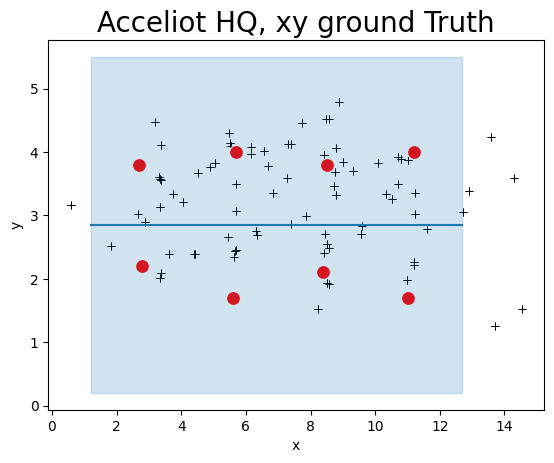

In [ ]:
sns.scatterplot(data=Runs, x='x', y='y', marker='+', color='black')
sns.scatterplot(data=antConf, x='x_ant', y='y_ant', marker='o', color='red', s=100)
sns.lineplot(data=xy_tags, x='x', y='y')
plt.title('Acceliot HQ, xy ground Truth', size=20)


In [ ]:
Runs[:1]

,ConfID,site,pgm,id,x,y,z0,P,run,xy,key
0,2026-02-03,HQ,AEP_OK,2026-02-04,1.82,2.51,0.0,31.5,2026-02-04 21:23:51,1.82__2.51,1


Text(0.5, 1.0, 'z')

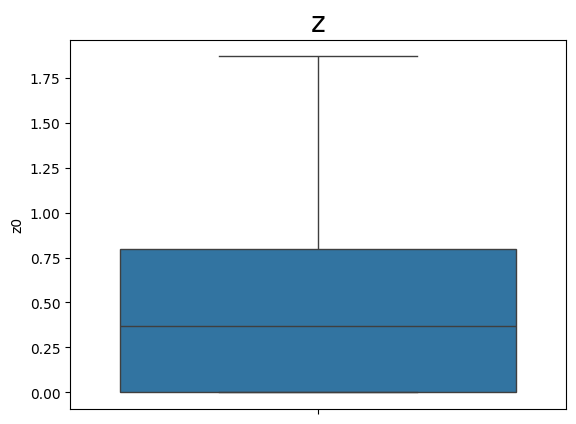

In [ ]:
sns.boxplot(data=Runs, y='z0')
plt.title('z', size=20)

# pick

In [255]:
tags_pick = tags.copy()
tags.shape, tags_pick.shape

((728138, 32), (728138, 32))

## tag xy zone

In [256]:
x_ant_min = antConf['x_ant'].min()
x_ant_max = antConf['x_ant'].max()
y_ant_min = antConf['y_ant'].min()
y_ant_max = antConf['y_ant'].max()
(x_ant_min, x_ant_max), (y_ant_min, y_ant_max)

((2.7, 11.2), (1.7, 4.0))

In [257]:
(tags_pick['x'].min(), tags_pick['x'].max()), (tags_pick['y'].min(), tags_pick['y'].max()), (tags_pick['z'].min(), tags_pick['z'].max())

((0.58, 14.53), (1.26, 4.79), (0.05, 3.54))

In [258]:
(tags_pick['x'].max() - tags_pick['x'].min()) * (tags_pick['y'].max() - tags_pick['y'].min()) * (tags_pick['z'].max() - tags_pick['z'].min())

171.85981500000003

In [259]:
D_extra = 1.5

x_min=x_ant_min-D_extra
x_max = x_ant_max+D_extra
y_min = y_ant_min-D_extra
y_max = y_ant_max+D_extra

In [260]:
tags_pick.shape

(728138, 32)

In [261]:
tags_pick = tags_pick[ (tags_pick['x']>=x_min) & (tags_pick['x']<=x_max) & (tags_pick['y']>=y_min) & (tags_pick['y']<=y_max) ]
tags_pick.shape

(703780, 32)

## map

In [262]:
tags_pick['xy'] = tags_pick['x'].astype(str) + '__' + tags_pick['y'].astype(str)
xy_unique = tags_pick['xy'].nunique()
xy_unique

74

Text(0.5, 1.0, 'Acceliot HQ, xy ground Truth, 74 xy points')

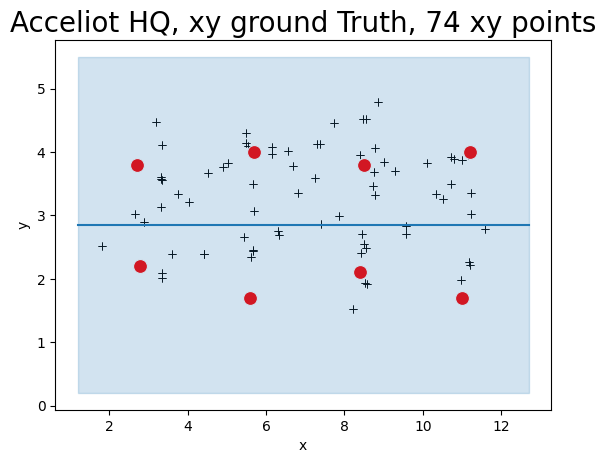

In [263]:
xy_tags = pd.DataFrame([[x_min, y_min], [x_min, y_max], [x_max, y_max], [x_max, y_min]], columns=['x', 'y'])
Runs_xy = Runs [ (Runs['x']>=x_min) & (Runs['x']<=x_max) & (Runs['y']>=y_min) & (Runs['y']<=y_max)]
sns.scatterplot(data=Runs_xy, x='x', y='y', marker='+', color='black')
sns.scatterplot(data=antConf, x='x_ant', y='y_ant', marker='o', color='red', s=100)
sns.lineplot(data=xy_tags, x='x', y='y')
plt.title(f'Acceliot HQ, xy ground Truth, {xy_unique} xy points', size=20)

In [264]:
Runs_xy['xy'].nunique()

74

## tag z

In [ ]:
tags_pick['z'].describe()

,z
count,703780.000000
mean,1.391617
std,0.700829
min,0.050000
25%,0.960000
50%,1.340000
75%,1.810000
max,3.540000


In [ ]:
# z_min = 0.5
# z_max=1.5

# z_min = 1.5
# z_max=4

# z_min = 0
# z_max=4

In [ ]:
tags_pick.shape

(703780, 31)

In [ ]:
tags_pick =  tags_pick [  (tags_pick['z']>=z_min) & (tags_pick['z']<=z_max) ]
tags_pick.shape

(310334, 31)

Text(0.5, 1.0, 'z')

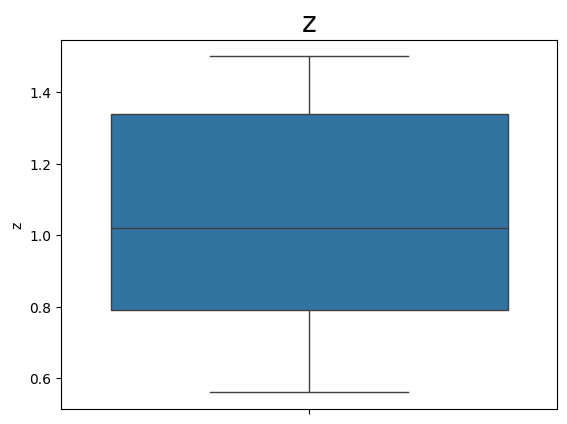

In [ ]:
sns.boxplot(data=tags_pick, y='z')
plt.title('z', size=20)

## tag polarisation

In [ ]:
# polar_list = ['H', 'V']
polar_list = ['H']

In [ ]:
tags_pick.shape

(310334, 31)

In [ ]:
tags_pick =  tags_pick [ tags_pick['polar'].isin(polar_list) ]
tags_pick.shape

(228144, 31)

## Power

In [ ]:
# Pmax_list=[24, 27, 31.5]
Pmax_list=[31.5]
# Pmax_list=[24]

In [ ]:
tags_pick.shape

(703780, 34)

In [ ]:
tags_pick =  tags_pick [  tags_pick['txPower_dBm'].isin(Pmax_list) ]
tags_pick.shape

(243776, 34)

## run_duration

In [ ]:
tags_pick.shape

In [ ]:
run_duration=pd.Timedelta(seconds=20)

def func(df):
  Tstart=df['datestamp'].min()
  Tend=Tstart + run_duration
  df = df [ df['datestamp'] < Tend]
  return df

tags_pick = tags_pick.groupby('run').apply(func).reset_index(drop=True)
tags_pick.shape

In [ ]:
tags_pick.shape

(703780, 32)

# Stats

In [265]:
tags_pick.shape

(703780, 33)

## detection per run

In [266]:
Detections = tags_pick.groupby(['x', 'y', 'z', 'xyz']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections[:1]

,x,y,z,xyz,EPCs
0,1.82,2.51,0.05,1.82__2.51__0.05,9


In [267]:
Detections['EPCs'].describe()

,EPCs
count,444.000000
mean,9.934685
std,0.352693
min,6.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [113]:
Q_expected=10
# Q_expected=6
Detections['EPCs'].describe()['mean'] / Q_expected

np.float64(0.9934684684684685)

In [114]:
MisDetections = Detections [Detections['EPCs']!=Q_expected]
MisDetections

,x,y,z,xyz,EPCs
0,1.82,2.51,0.05,1.82__2.51__0.05,9
2,1.82,2.51,0.70,1.82__2.51__0.7,7
3,1.82,2.51,1.02,1.82__2.51__1.02,9
4,1.82,2.51,1.34,1.82__2.51__1.34,9
5,1.82,2.51,1.67,1.82__2.51__1.67,9
9,2.65,3.03,1.02,2.65__3.03__1.02,9
18,3.20,4.47,0.05,3.2__4.47__0.05,9
42,3.34,2.01,0.05,3.34__2.01__0.05,8
43,3.34,2.01,0.37,3.34__2.01__0.37,9
46,3.34,2.01,1.34,3.34__2.01__1.34,9


In [ ]:
Detections_antRound = tags_pick.groupby(['run', 'xyz', 'antRound']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections_antRound['EPCs'].describe()

,EPCs
count,35421.000000
mean,5.981536
std,2.120747
min,1.000000
25%,5.000000
50%,6.000000
75%,8.000000
max,10.000000


## Tx, TxRx

In [ ]:
tags_pick.groupby(['EPC', 'xyz'])['Tx'].nunique().describe()

,Tx
count,4411.000000
mean,5.591476
std,1.583778
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,8.000000


In [ ]:
tags_pick.groupby(['EPC', 'xyz', 'Tx'])['rx'].nunique().describe()

,rx
count,24664.000000
mean,3.579428
std,0.711933
min,2.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,4.000000


In [ ]:
tags_pick.columns

Index(['run', 'datestamp', 'EPC', 'txPower_dBm', 'Tx', 'rx', 'rssi (dBm)',
       'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi', 'Tx_sequence',
       'antRound', 'antRound_duration', 'slot_id', 'slotStart', 'x', 'y', 'z',
       'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE', '0F173B12__NONE',
       '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE',
       'PORT_4__NONE', 'nearestAnt', 'nearestD'],
      dtype='object')

In [ ]:
tags_pick.groupby(['EPC', 'xyz', 'txPower_dBm'])['Tx'].nunique().groupby('txPower_dBm').describe()

,count,mean,std,min,25%,50%,75%,max
txPower_dBm,,,,,,,,
24.0,1123.0,3.058771,1.250355,1.0,2.0,3.0,4.0,7.0
27.0,1139.0,4.282704,1.461567,1.0,3.0,4.0,5.0,8.0
31.5,1137.0,5.821460,1.558359,1.0,5.0,6.0,7.0,8.0


In [ ]:
tags_pick['Tx, rx'] = tags_pick['Tx'] + ', '  + tags_pick['rx']
tags_pick.groupby(['EPC', 'xyz'])['Tx, rx'].nunique().describe()

,"Tx, rx"
count,4411.000000
mean,20.014282
std,6.468520
min,2.000000
25%,16.000000
50%,20.000000
75%,25.000000
max,32.000000


## rssimax = nearest?

In [ ]:
index = ['EPC', 'run', 'xyz', 'Tx', 'txPower_dBm']
Values=['rssi']
ds_rssimax = pd.pivot_table(tags_pick, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})
ds_rssimax = ds_rssimax.reset_index(drop=False)

ds_rssimax = pd.merge(ds_rssimax, Actuals_xyz_D, on=['xyz', 'EPC'])

ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)
print((ds_rssimax_1Tx['Tx'] == ds_rssimax_1Tx['nearestAnt']).mean())

for Tx in Tx_sequence.keys():
  idx_DTxMax = ds_rssimax_1Tx [ds_rssimax_1Tx['Tx']==Tx].index
  ds_rssimax_1Tx.loc[idx_DTxMax, 'DTxMax'] = ds_rssimax_1Tx.loc[idx_DTxMax, Tx]

ds_rssimax_1Tx['Delta_D'] = ds_rssimax_1Tx['DTxMax']-ds_rssimax_1Tx['nearestD']
ds_rssimax_1Tx['Delta_D'].describe()

/tmp/ipykernel_4580/2210509164.py:3: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssimax = pd.pivot_table(tags_pick, index=index, values=Values, aggfunc=max).rename(columns={'rssi':'rssimax'})


0.2783143107989464


/tmp/ipykernel_4580/2210509164.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_rssimax_1Tx = ds_rssimax.groupby(['EPC', 'xyz']) .apply(lambda x:x.nlargest(1, 'rssimax')).reset_index(drop=True)


,Delta_D
count,1139.000000
mean,0.631843
std,0.795300
min,0.000000
25%,0.000000
50%,0.410402
75%,0.903591
max,5.455754


In [ ]:
ds_rssimax_1Tx

,EPC,run,xyz,Tx,txPower_dBm,rssimax,x,y,z,polar,...,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,DTxMax,Delta_D
0,BA0101000000000000000000,2026-02-12 21:58:28,10.1__3.82__1.29,PORT_4__NONE,24.0,0.879023,10.10,3.82,1.29,H,...,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454,3.558160,0.496706
1,BA0101000000000000000000,2026-02-13 20:09:34,10.98__1.98__1.1300000000000001,0F173B12__NONE,31.5,0.024604,10.98,1.98,1.13,H,...,2.983236,3.765329,6.295371,4.139529,6.057698,3.787308,0F173B12__NONE,2.983236,2.983236,0.000000
2,BA0101000000000000000000,2026-02-05 22:58:19,11.01__3.87__1.08,PORT_2__NONE,31.5,0.088920,11.01,3.87,1.08,H,...,3.718790,3.228219,6.013768,3.775897,6.475291,4.230532,0F173B13__NONE,3.228219,3.775897,0.547678
3,BA0101000000000000000000,2026-02-12 22:03:49,11.16__3.95__1.07,0F173B12__NONE,27.0,0.033497,11.16,3.95,1.07,H,...,3.777433,3.230635,6.150041,3.886772,6.632119,4.364516,0F173B13__NONE,3.230635,3.777433,0.546798
4,BA0101000000000000000000,2026-02-12 22:09:23,11.19__2.26__0.91,0F173B12__NONE,24.0,0.143549,11.19,2.26,0.91,H,...,3.244349,3.810486,6.489052,4.306716,6.364102,4.092652,0F173B12__NONE,3.244349,3.244349,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1886,BA0510000000000000000000,2026-02-11 21:24:54,8.79__3.32__1.34,PORT_4__NONE,31.5,4.045759,8.79,3.32,1.34,H,...,3.889229,3.877125,4.069902,2.620706,4.399329,2.862534,PORT_2__NONE,2.620706,2.862534,0.241828
1887,BA0510000000000000000000,2026-02-10 21:15:22,8.79__4.06__1.34,PORT_1__NONE,31.5,2.494595,8.79,4.06,1.34,H,...,4.251035,3.817499,4.013141,2.589459,4.722213,3.247661,PORT_2__NONE,2.589459,4.013141,1.423682
1888,BA0510000000000000000000,2026-02-04 21:46:13,8.87__4.79__1.34,0F173B13__NONE,31.5,1.061696,8.87,4.79,1.34,H,...,4.658605,3.848974,4.150494,2.769585,5.176350,3.743074,PORT_2__NONE,2.769585,3.848974,1.079389
1889,BA0510000000000000000000,2026-02-06 21:43:05,9.01__3.85__1.34,0F173B12__NONE,31.5,3.483373,9.01,3.85,1.34,H,...,4.024947,3.685132,4.187147,2.610785,4.775374,3.160411,PORT_2__NONE,2.610785,4.024947,1.414162


## antRound

In [ ]:
tags_pick.groupby(['run', 'antRound'])['antRound_duration'].mean().describe()

## detections per antRound

In [ ]:
Detections_antRound = tags_pick.groupby(['x', 'y', 'z', 'xyz','txPower_dBm', 'antRound']) ['EPC'].nunique().rename('EPCs').reset_index(drop=False)
Detections_antRound['EPCs'].describe()

## visu

In [ ]:
tags_pick.columns

Index(['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx', 'rx',
       'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi',
       'Tx_sequence', 'antRound', 'antRound_duration', 'slot_id', 'slotStart',
       'x', 'y', 'z', 'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE',
       '0F173B12__NONE', '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE',
       'PORT_3__NONE', 'PORT_4__NONE', 'nearestAnt', 'nearestD', 'xy'],
      dtype='object')

BA0602000000000000000000 8.45__2.7__1.67 PORT_2__NONE 24.0 2026-02-17 21:37:05


<Figure size 1200x600 with 0 Axes>

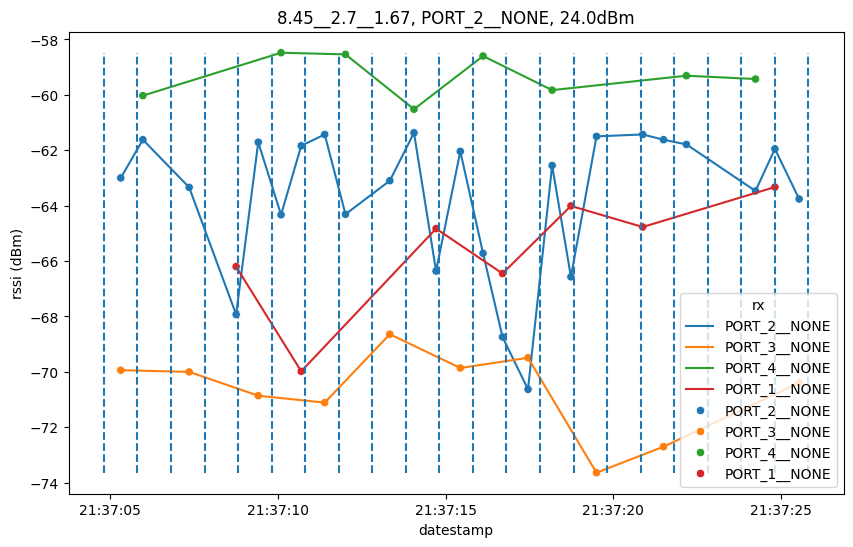

In [ ]:
plt.figure(figsize=(12,6))
for i, row in tags_pick [['EPC', 'xyz', 'run', 'Tx', 'txPower_dBm']].drop_duplicates().sample(1).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['xyz']==xyz) & (tags_pick['Tx']==Tx)& (tags_pick['txPower_dBm']==txPower_dBm) ]
  plt.figure(figsize=(10,6))
  print(EPC, xyz, Tx, txPower_dBm, run)
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')
  # plt.show()
  sns.scatterplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm')
  plt.show()

BA0506000000000000000000 6.16__4.08__1.34 041A9F60__NONE 27.0 2026-02-05 22:27:39


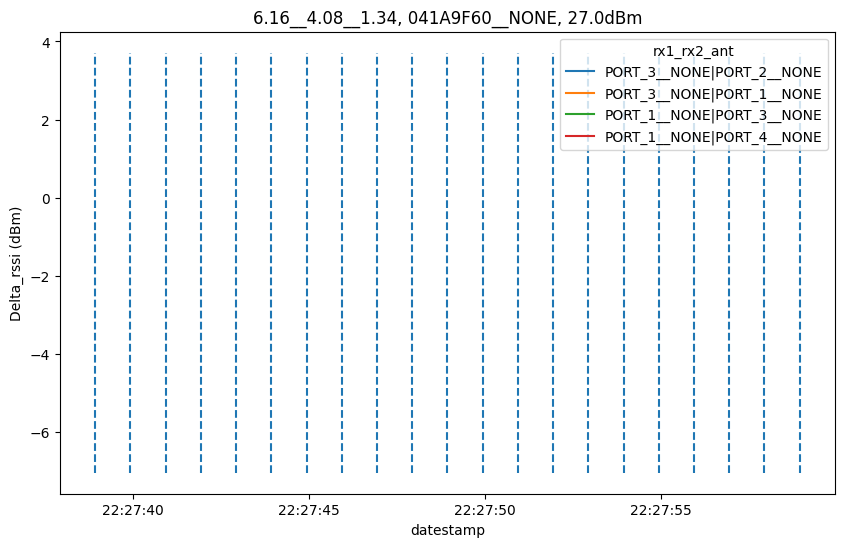

BA0310000000000000000000 2.88__2.9__0.7 PORT_2__NONE 31.5 2026-02-05 22:23:06


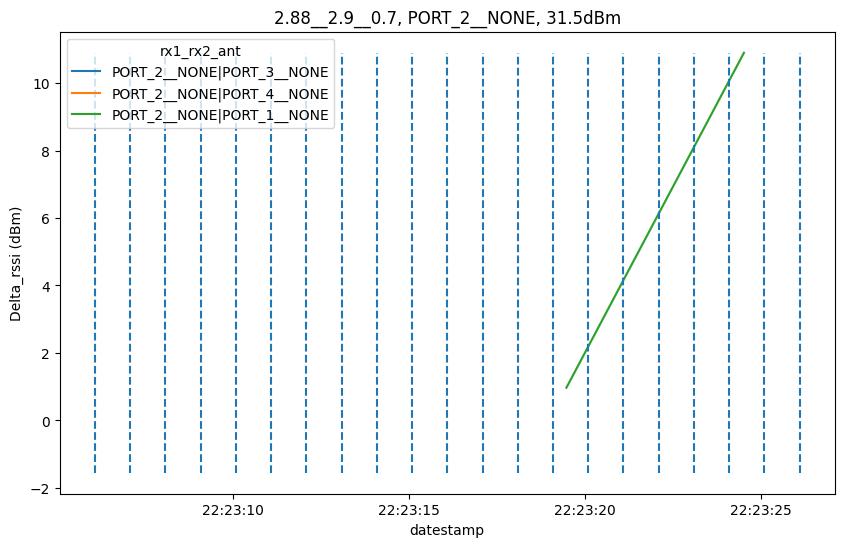

BA0408000000000000000000 4.52__3.67__1.02 PORT_1__NONE 24.0 2026-02-11 21:58:03


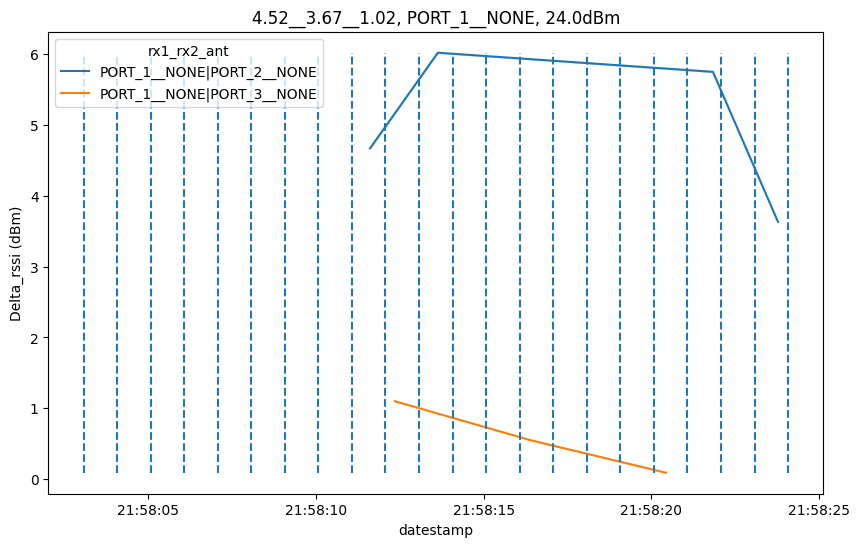

BA0610000000000000000000 3.33__3.14__1.67 PORT_4__NONE 24.0 2026-02-13 20:43:08


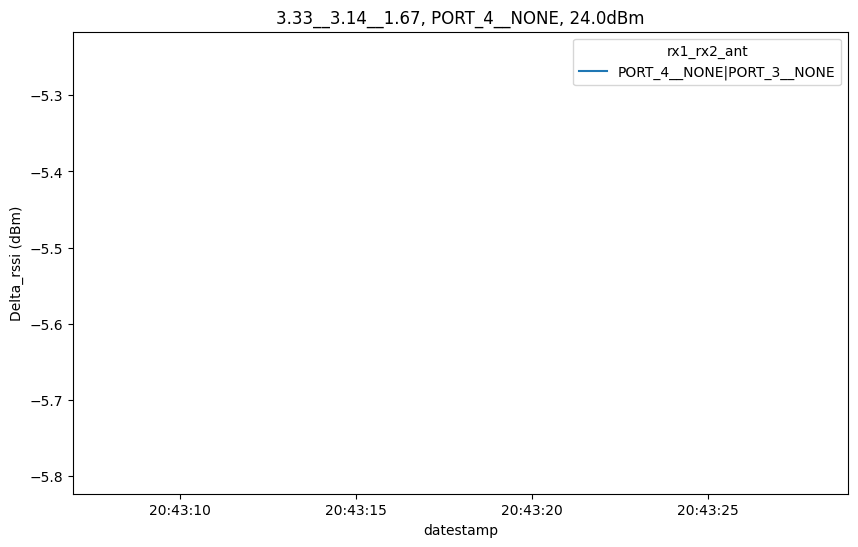

BA0503000000000000000000 5.04__3.83__2.02 041A9F60__NONE 31.5 2026-02-06 22:05:53


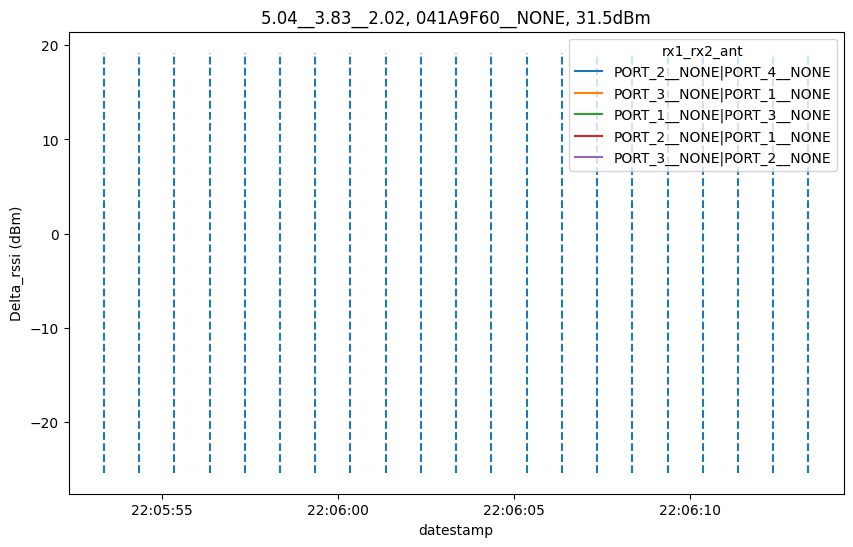

BA0403000000000000000000 6.34__2.69__1.75 PORT_3__NONE 27.0 2026-02-12 21:39:01


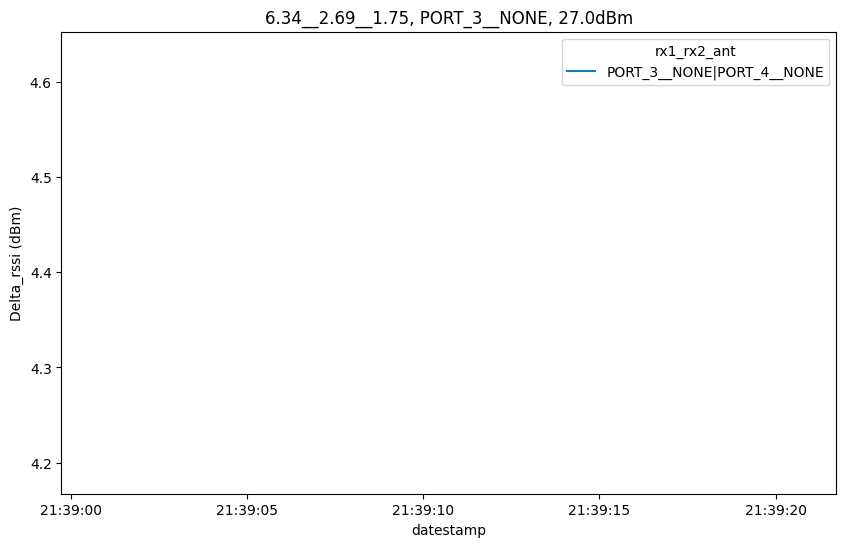

BA0307000000000000000000 7.31__4.13__1.1099999999999999 041A9F60__NONE 27.0 2026-02-06 21:55:00


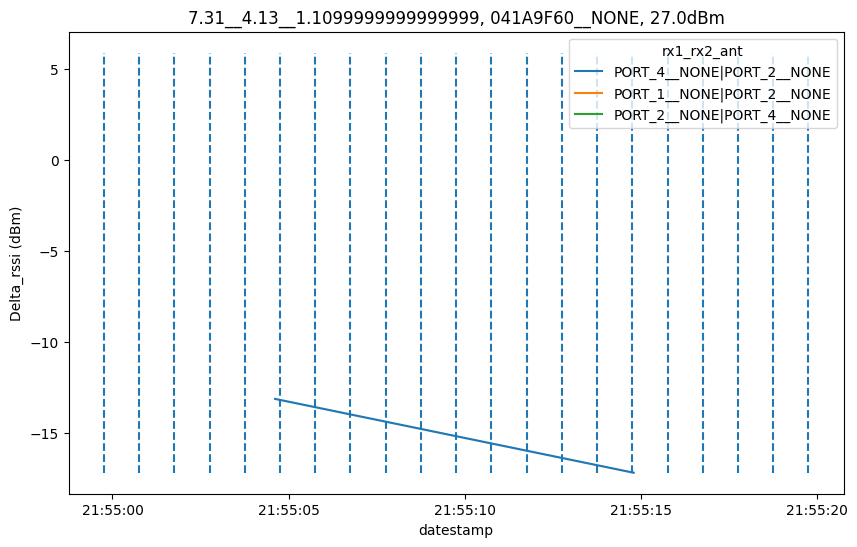

BA0207000000000000000000 5.04__3.83__1.05 PORT_1__NONE 24.0 2026-02-06 22:07:23


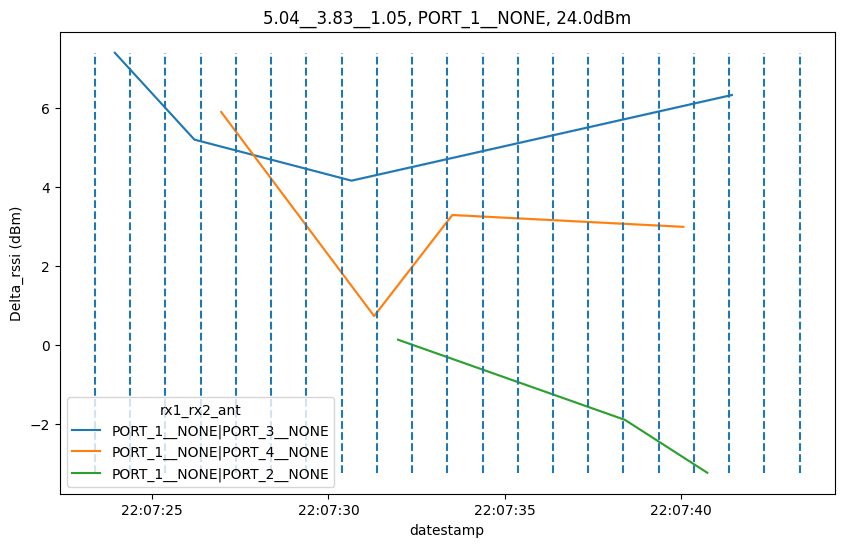

BA0406000000000000000000 11.01__3.87__2.05 0F173B12__NONE 27.0 2026-02-05 22:59:24


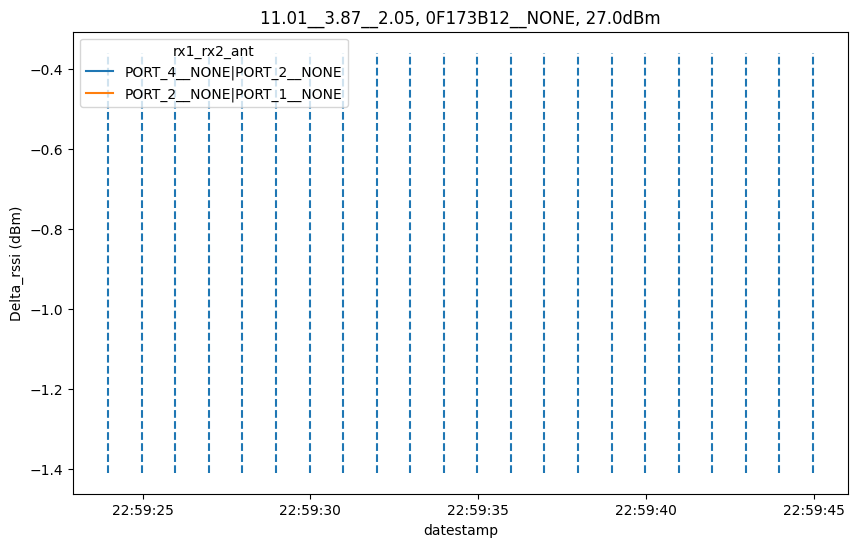

BA0401000000000000000000 5.5__4.15__1.3900000000000001 041A9F61__NONE 31.5 2026-02-17 21:49:01


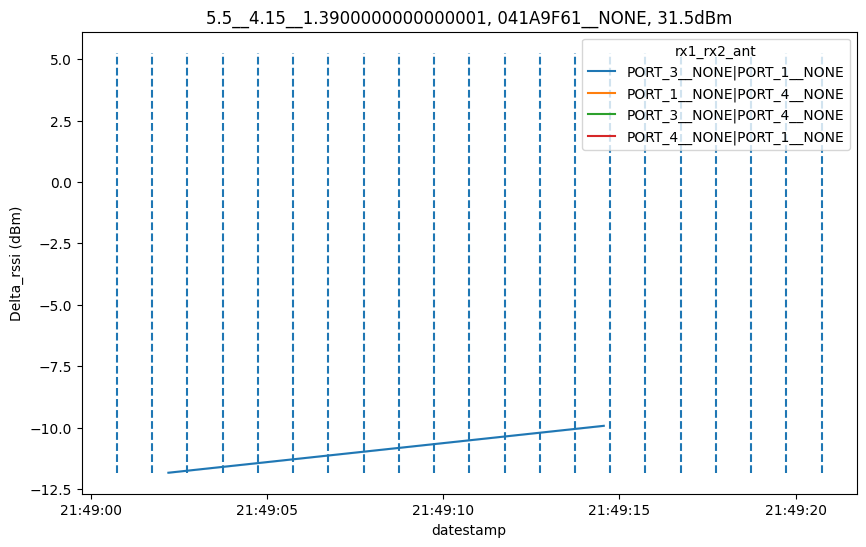

In [ ]:
for i, row in tags_pick [['EPC', 'xyz', 'run', 'Tx', 'txPower_dBm']].drop_duplicates().sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['xyz']==xyz) & (tags_pick['Tx']==Tx)& (tags_pick['txPower_dBm']==txPower_dBm) ]
  plt.figure(figsize=(10,6))
  print(EPC, xyz, Tx, txPower_dBm, run)
  sns.lineplot(data=tags_display, x='datestamp', y='Delta_rssi (dBm)', hue='rx1_rx2_ant')

  rssi_min = tags_display['Delta_rssi (dBm)'].min()
  rssi_max = tags_display['Delta_rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm')
  plt.show()

In [ ]:
tags_pick ['rx1_rx2_ant'].unique()

array(['PORT_3__NONE|PORT_4__NONE', 'PORT_1__NONE|PORT_4__NONE',
       'PORT_4__NONE|PORT_1__NONE', 'PORT_1__NONE|PORT_2__NONE',
       'PORT_3__NONE|PORT_1__NONE', 'PORT_4__NONE|PORT_2__NONE',
       'PORT_1__NONE|PORT_3__NONE', 'PORT_2__NONE|PORT_3__NONE',
       'PORT_4__NONE|PORT_3__NONE', 'PORT_2__NONE|PORT_1__NONE',
       'PORT_2__NONE|PORT_4__NONE', 'PORT_3__NONE|PORT_2__NONE'],
      dtype=object)

BA0204000000000000000000 PORT_2__NONE 31.5 2026-02-12 21:51:05


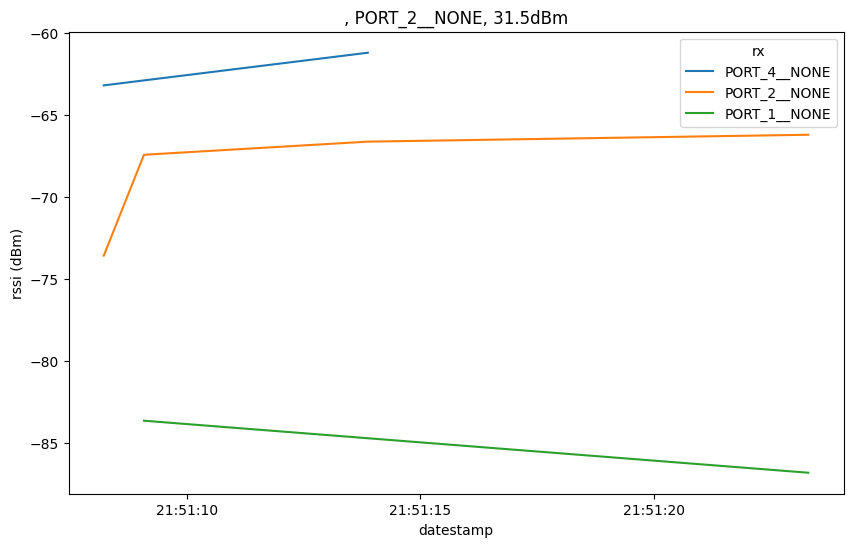

BA0503000000000000000000 0F173B13__NONE 31.5 2026-02-06 21:43:05


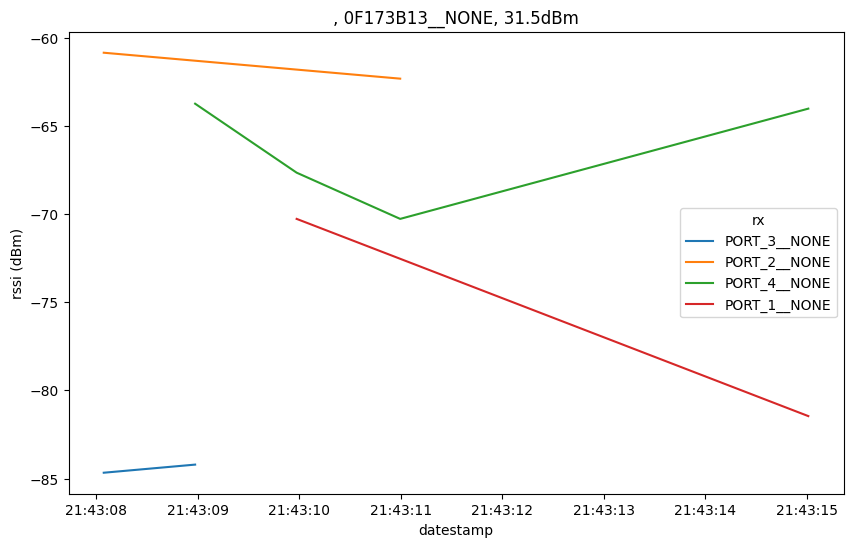

BA0103000000000000000000 PORT_2__NONE 24.0 2026-02-13 20:32:23


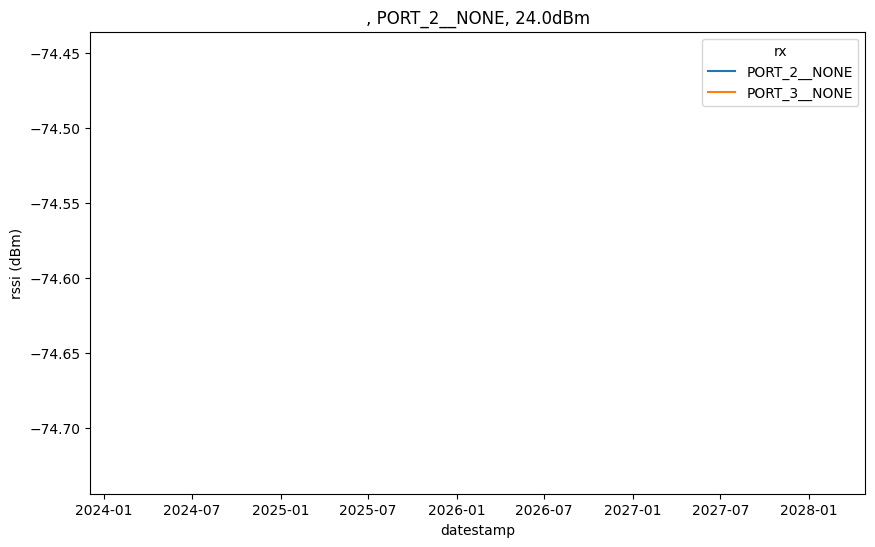

BA0401000000000000000000 PORT_2__NONE 31.5 2026-02-11 21:07:52


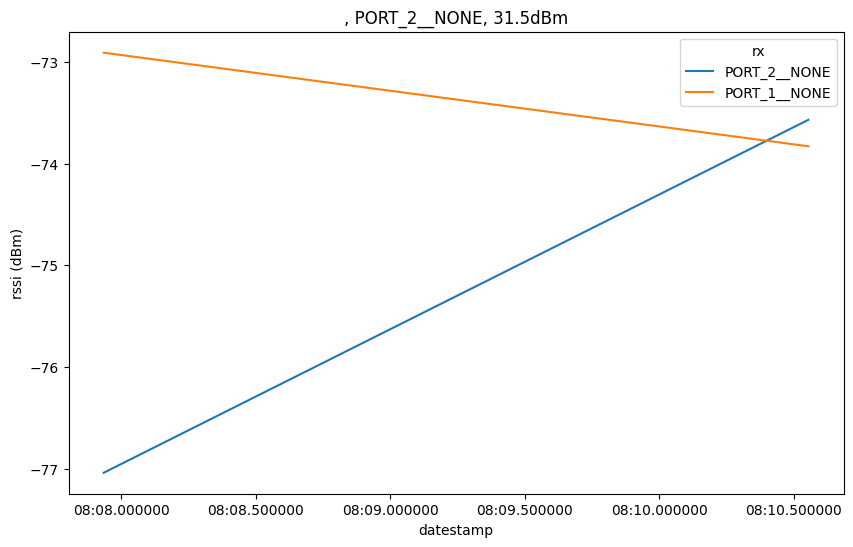

BA0301000000000000000000 PORT_1__NONE 31.5 2026-02-12 21:42:42


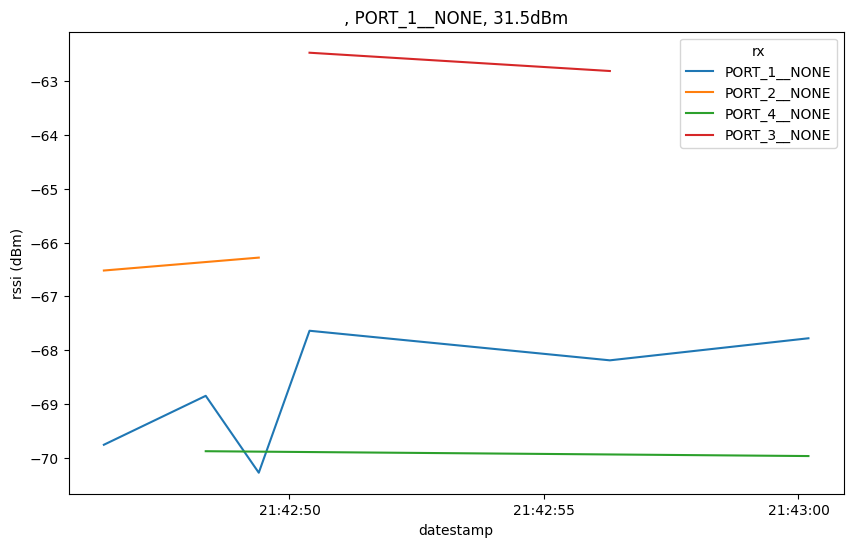

BA0503000000000000000000 PORT_3__NONE 27.0 2026-02-04 21:28:55


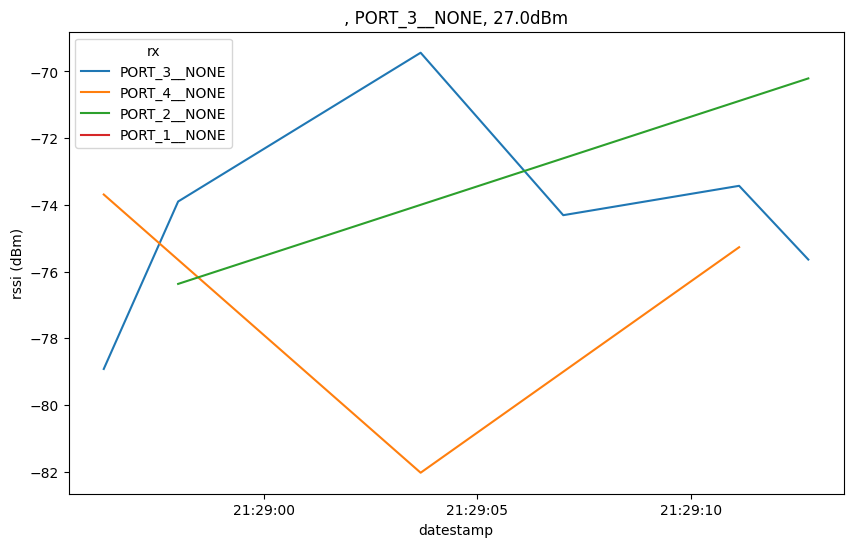

BA0503000000000000000000 041A9F61__NONE 31.5 2026-02-04 21:38:34


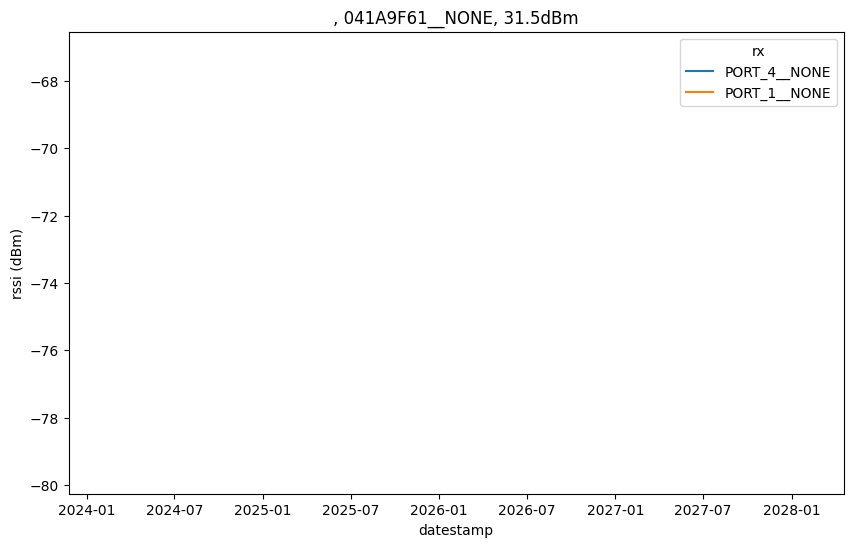

BA0409000000000000000000 PORT_1__NONE 24.0 2026-02-17 21:50:44


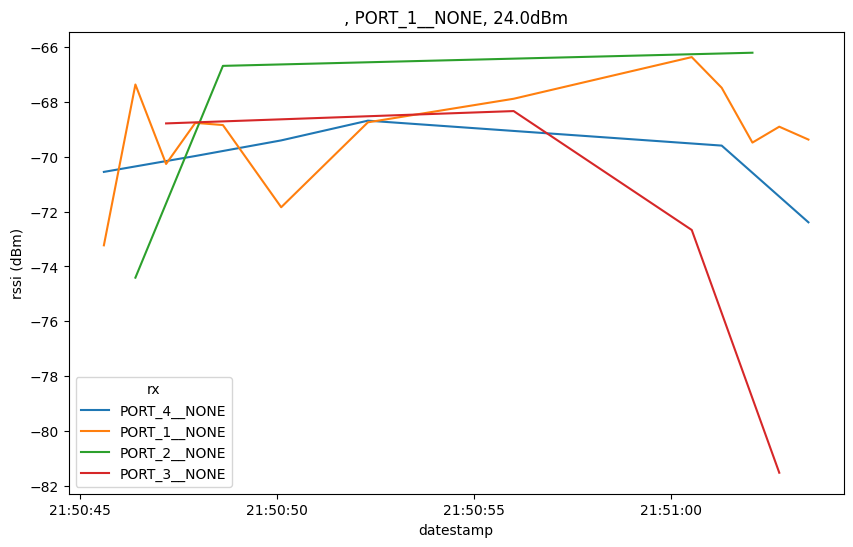

BA0404000000000000000000 PORT_1__NONE 31.5 2026-02-17 21:23:59


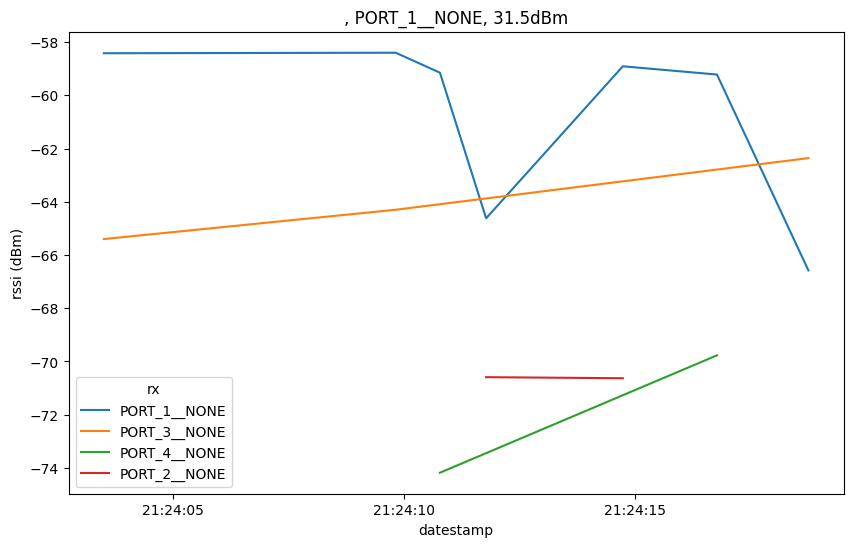

BA0202000000000000000000 041A9F61__NONE 27.0 2026-02-13 20:31:42


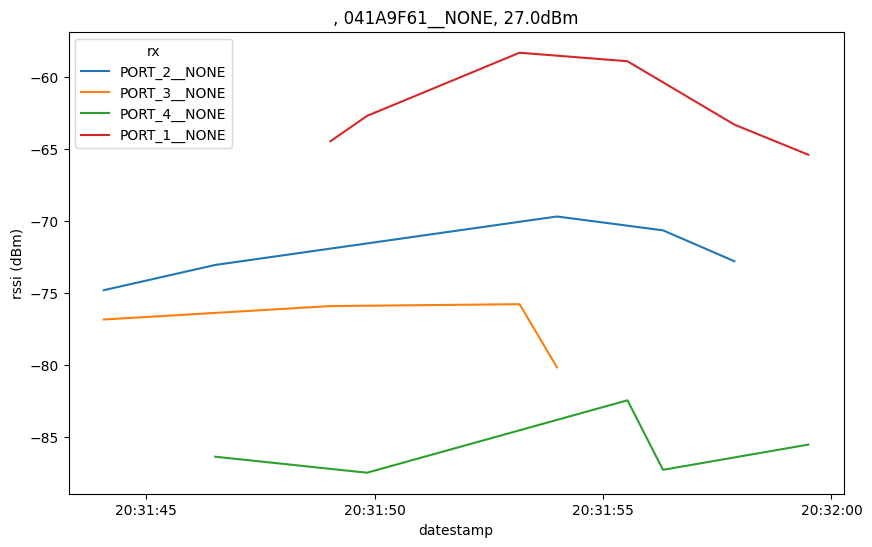

BA0110000000000000000000 PORT_3__NONE 24.0 2026-02-13 20:36:29


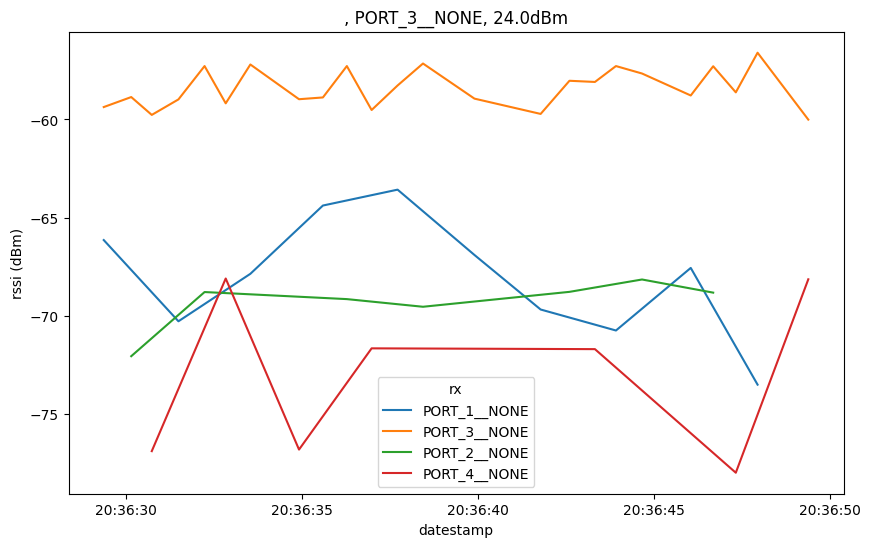

BA0104000000000000000000 041A9F60__NONE 27.0 2026-02-11 21:53:44


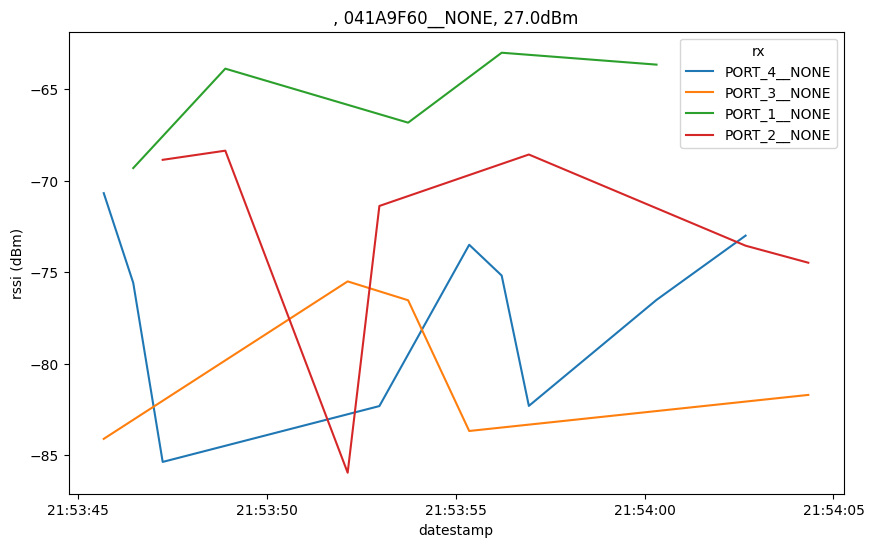

BA0401000000000000000000 PORT_2__NONE 24.0 2026-02-17 21:29:35


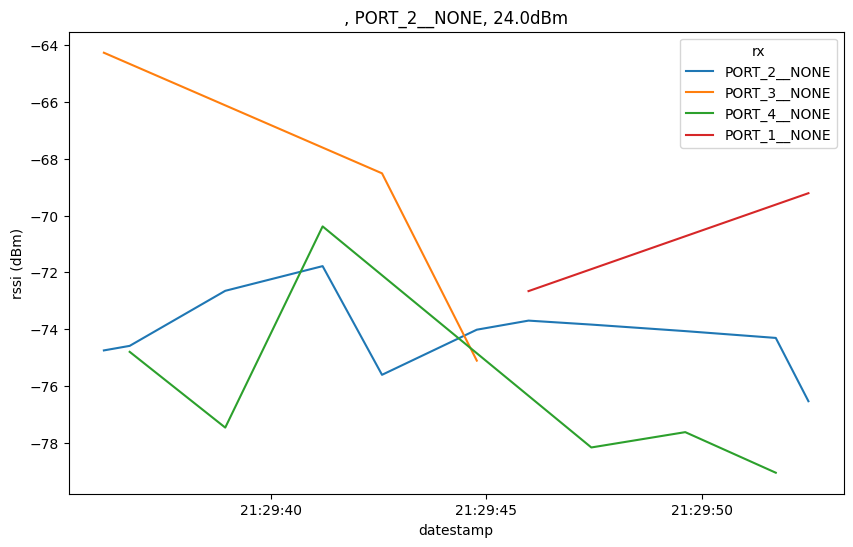

BA0302000000000000000000 0F173B12__NONE 31.5 2026-02-04 21:42:14


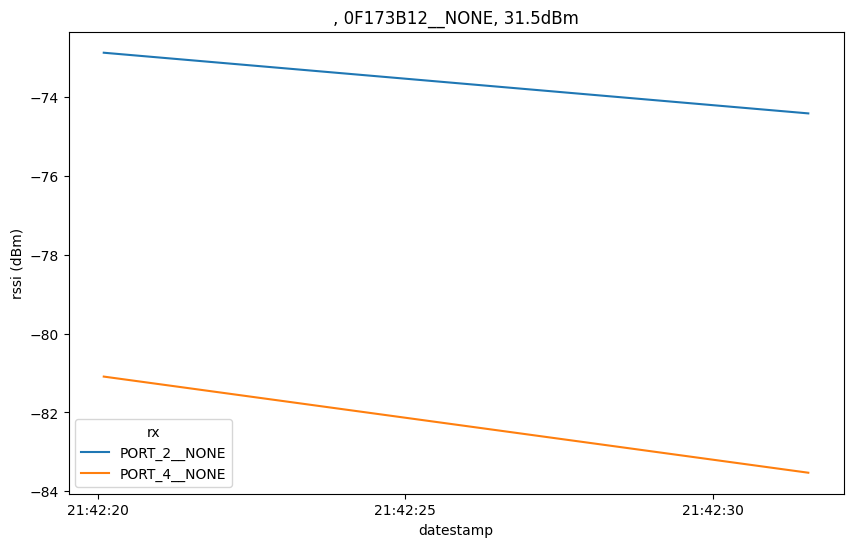

BA0404000000000000000000 0F173B12__NONE 31.5 2026-02-12 21:46:41


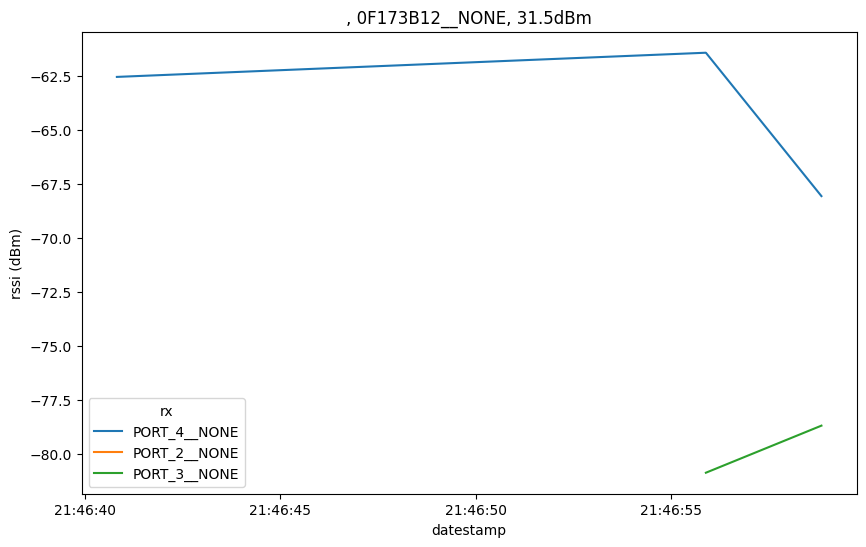

BA0202000000000000000000 PORT_1__NONE 31.5 2026-02-11 21:36:09


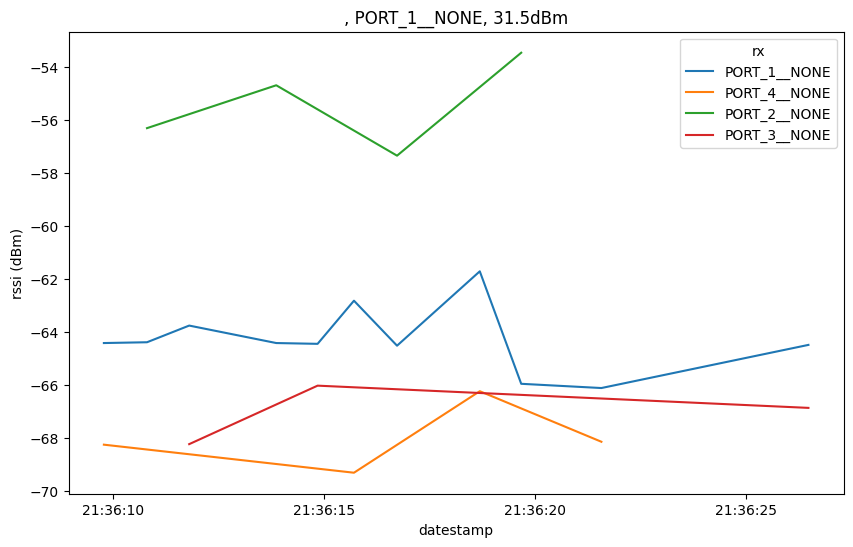

BA0302000000000000000000 PORT_3__NONE 31.5 2026-02-13 20:26:16


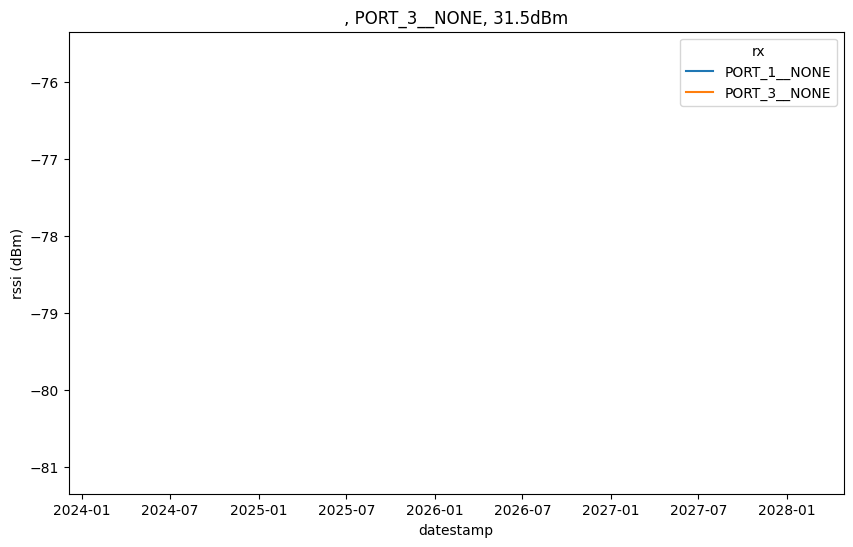

BA0404000000000000000000 0F173B13__NONE 31.5 2026-02-17 21:35:26


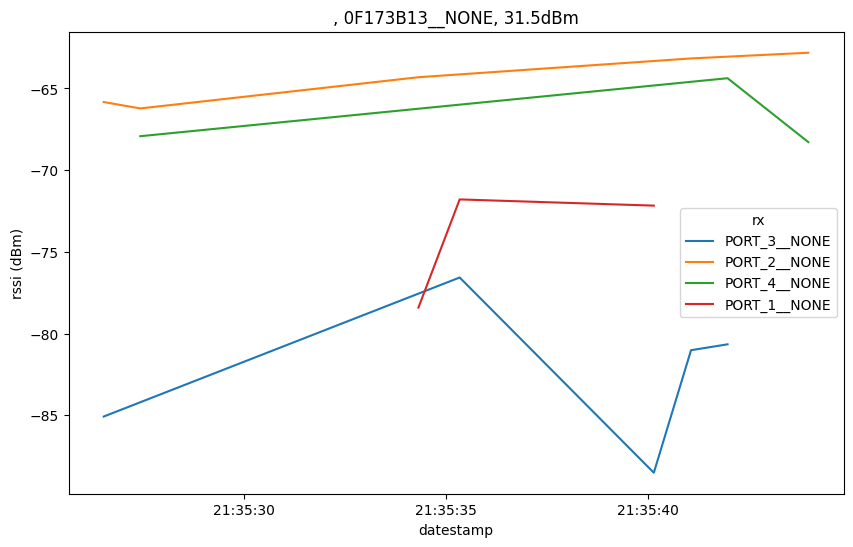

BA0101000000000000000000 PORT_1__NONE 27.0 2026-02-11 21:40:47


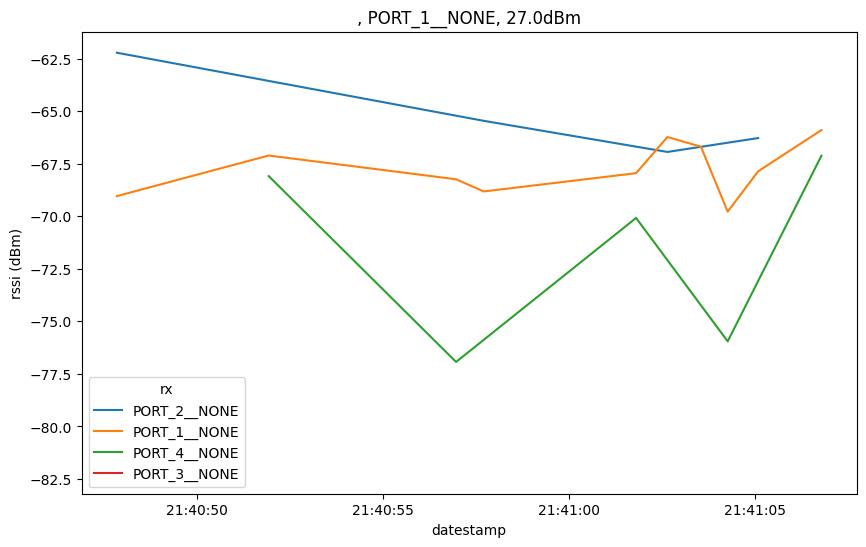

BA0403000000000000000000 PORT_1__NONE 27.0 2026-02-04 21:42:57


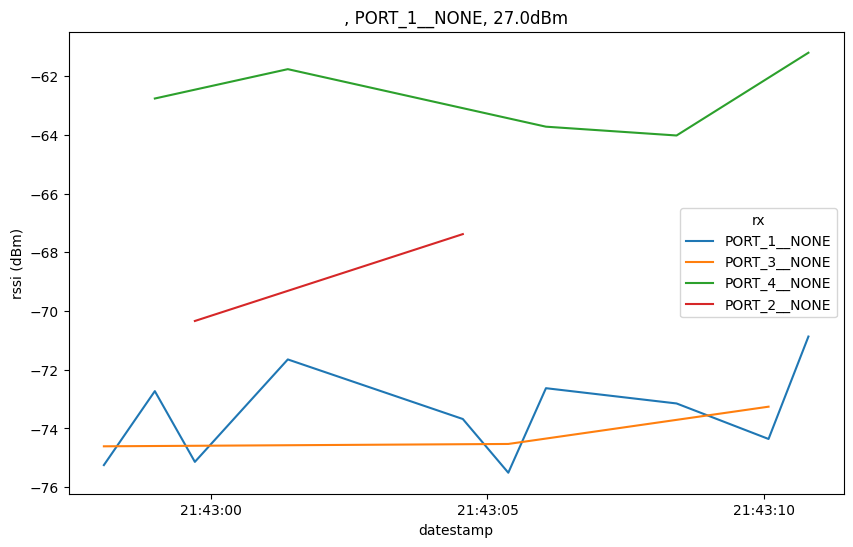

In [ ]:
for i, row in tags_pick [['EPC', 'run', 'Tx', 'txPower_dBm']].drop_duplicates().sample(20).iterrows():
  EPC=row['EPC']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['run']==run)  & (tags_pick['Tx']==Tx)& (tags_pick['txPower_dBm']==txPower_dBm) ]
  plt.figure(figsize=(10,6))
  print(EPC, Tx, txPower_dBm, run)
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  # Slots_run = Slots [Slots['run']==run]
  # plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f', {Tx}, {txPower_dBm}dBm')
  plt.show()

## extreme samples

In [ ]:
ds_rssimax_1Tx

,EPC,run,xyz,Tx,txPower_dBm,rssimax,x,y,z,polar,...,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,DTxMax,Delta_D
0,BA0101000000000000000000,2026-02-04 21:23:51,1.82__2.51__0.05,041A9F61__NONE,31.5,0.114288,1.82,2.51,0.05,H,...,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808,3.878273,0.182464
1,BA0101000000000000000000,2026-02-12 21:58:28,10.1__3.82__1.29,PORT_4__NONE,24.0,0.879023,10.10,3.82,1.29,H,...,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454,3.558160,0.496706
2,BA0101000000000000000000,2026-02-11 21:16:35,10.34__3.33__0.05,0F173B13__NONE,31.5,0.397192,10.34,3.33,0.05,H,...,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901,4.387596,0.094695
3,BA0101000000000000000000,2026-02-17 21:52:50,10.51__3.26__0.05,PORT_4__NONE,31.5,0.444631,10.51,3.26,0.05,H,...,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631,4.540947,0.173316
4,BA0101000000000000000000,2026-02-11 21:13:11,10.71__3.92__1.57,PORT_2__NONE,27.0,0.322849,10.71,3.92,1.57,H,...,3.378372,2.774779,5.525885,3.213627,6.038990,3.751986,0F173B13__NONE,2.774779,3.213627,0.438848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,BA0610000000000000000000,2026-02-04 21:48:00,8.87__4.79__1.67,PORT_4__NONE,24.0,0.741310,8.87,4.79,1.67,H,...,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606,PORT_2__NONE,2.467772,3.525606,1.057834
4407,BA0610000000000000000000,2026-02-06 21:43:05,9.01__3.85__1.67,0F173B12__NONE,31.5,3.169567,9.01,3.85,1.67,H,...,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569,PORT_2__NONE,2.288122,3.806245,1.518123
4408,BA0610000000000000000000,2026-02-13 20:18:30,9.3__3.7__1.67,PORT_4__NONE,31.5,1.761976,9.30,3.70,1.67,H,...,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408,PORT_2__NONE,2.371265,2.888408,0.517142
4409,BA0610000000000000000000,2026-02-11 21:21:08,9.57__2.71__2.29,PORT_2__NONE,31.5,0.464515,9.57,2.71,2.29,H,...,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610,PORT_4__NONE,2.081610,2.219257,0.137647


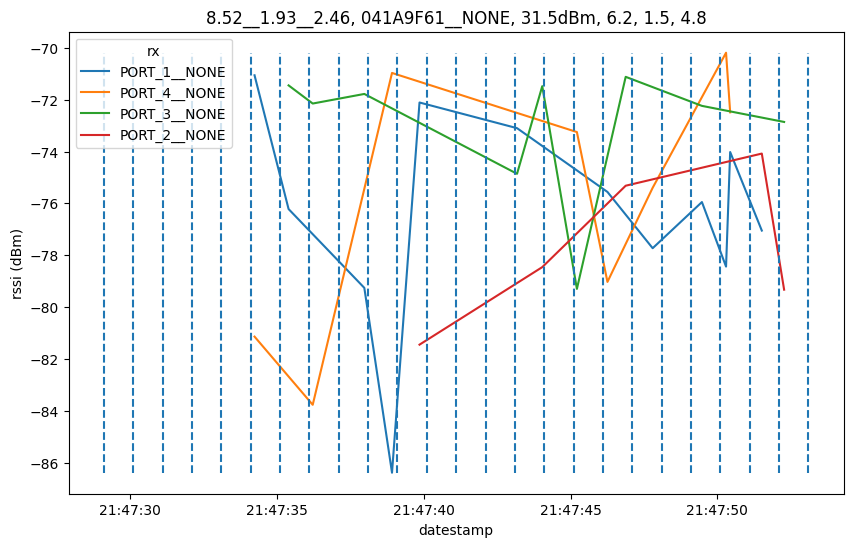

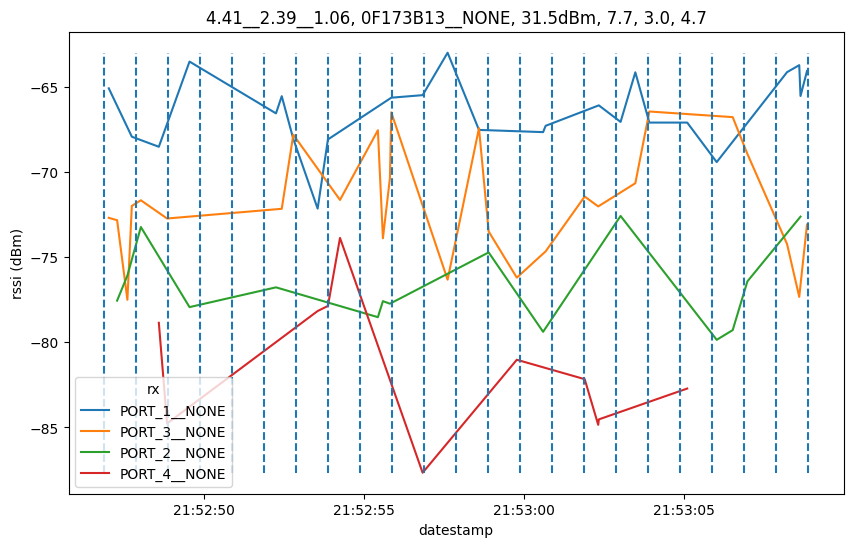

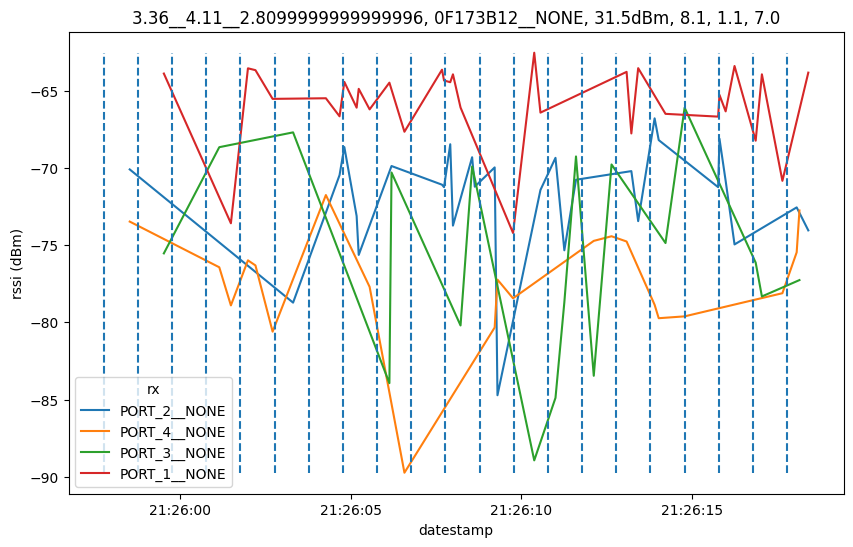

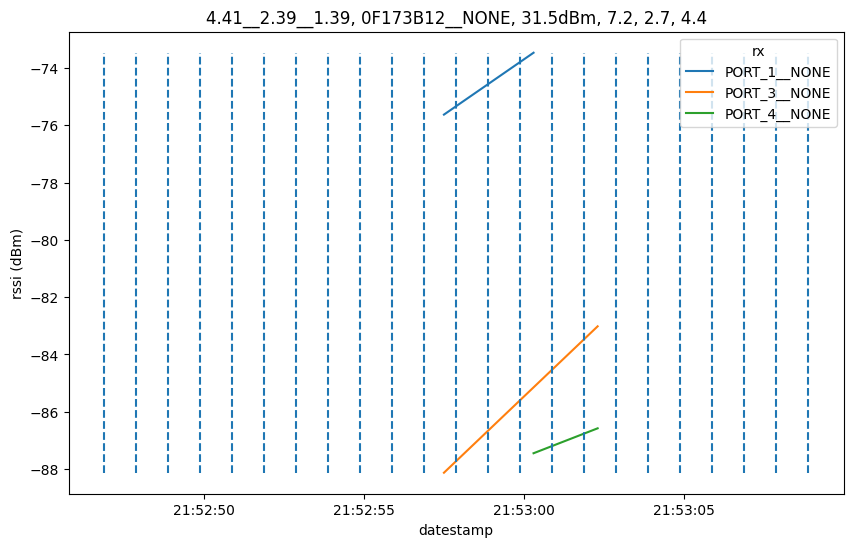

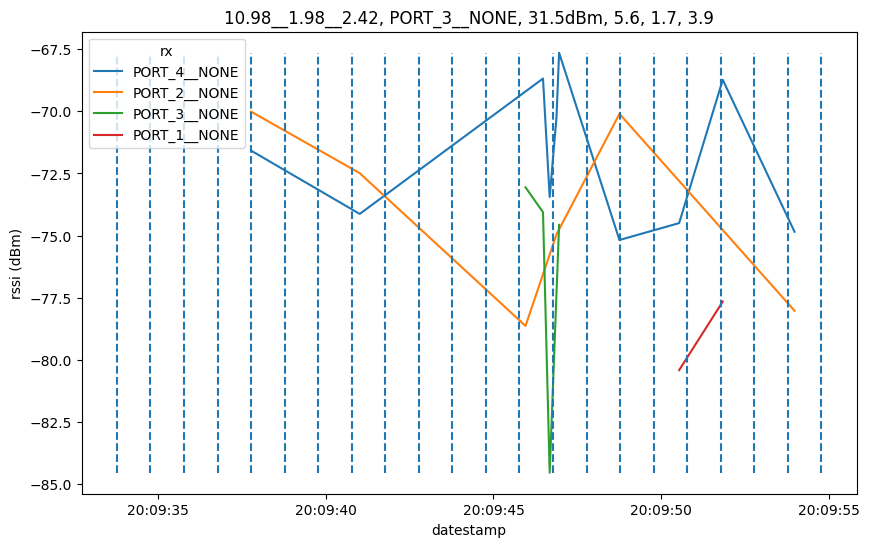

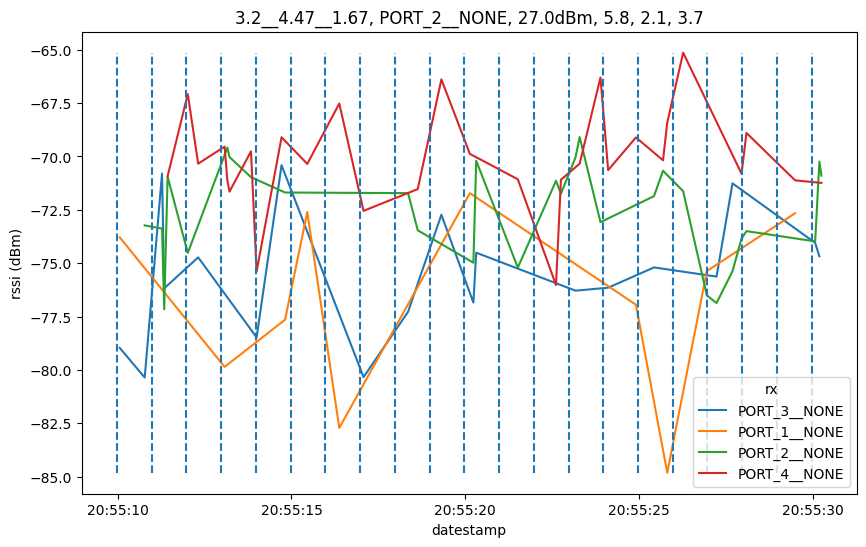

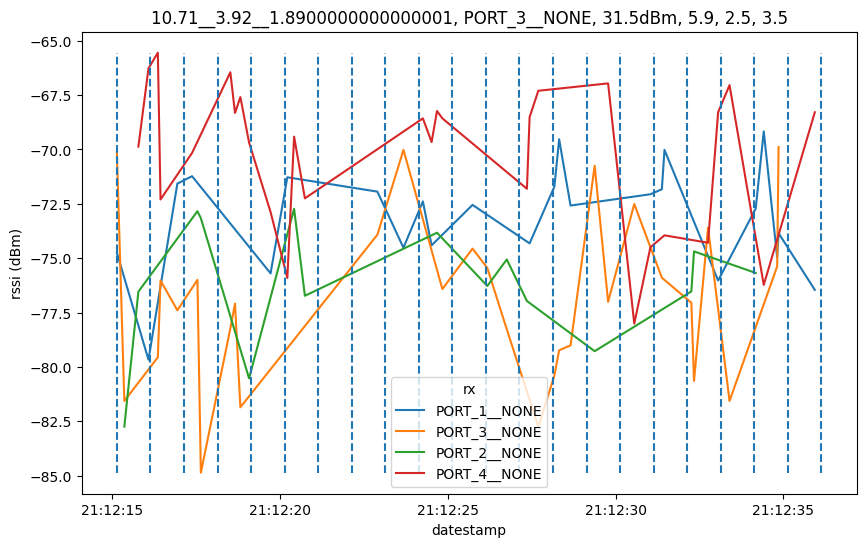

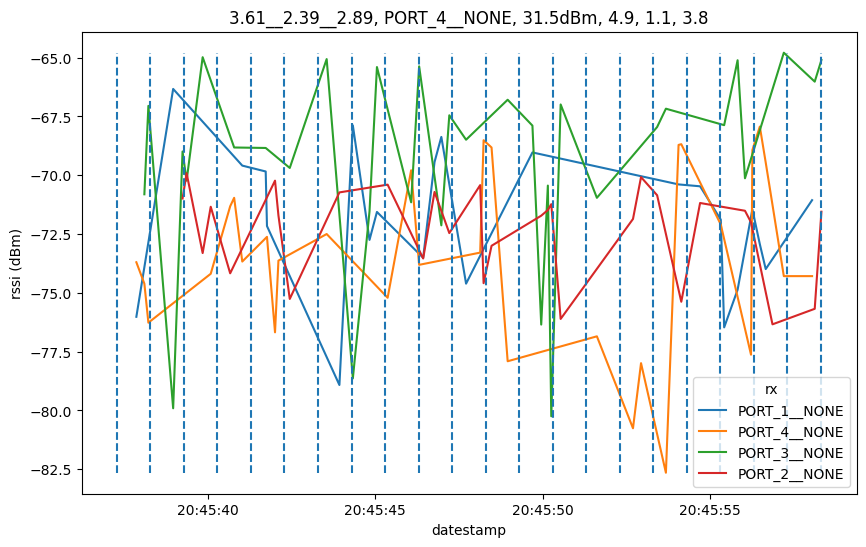

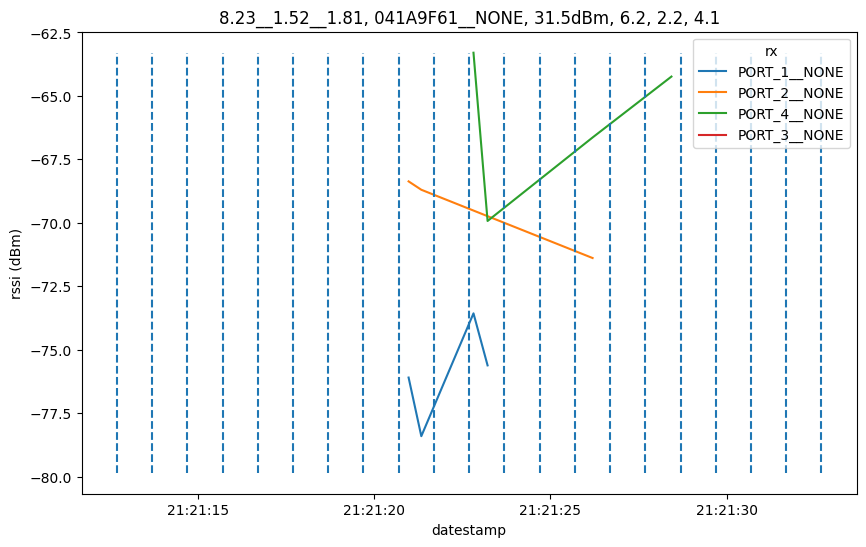

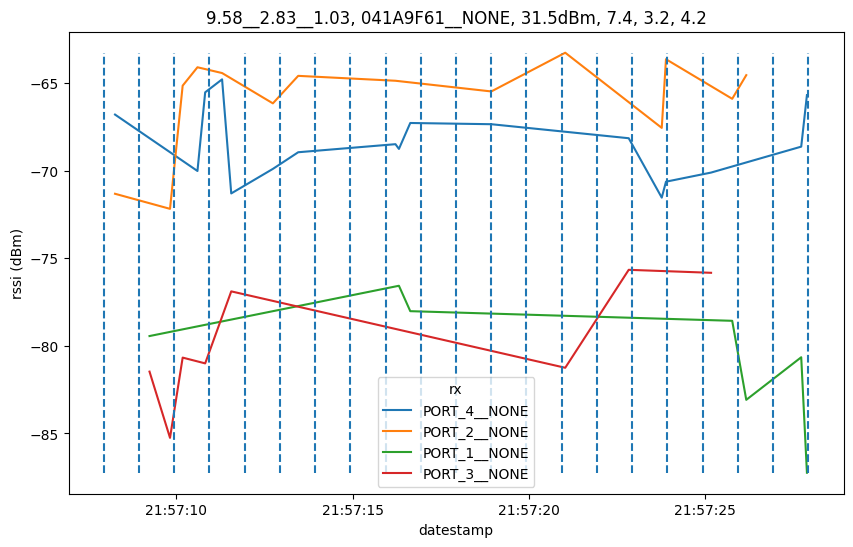

In [ ]:
hard = ds_rssimax_1Tx [ds_rssimax_1Tx['Delta_D']>3]

for i, row in hard.sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']
  nearestD = row['nearestD']
  DTxMax = row['DTxMax']
  Delta_D = row['Delta_D']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['run']==run) ]
  plt.figure(figsize=(10,6))
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm, {DTxMax:.1f}, {nearestD:.1f}, {Delta_D:.1f}')
  plt.show()



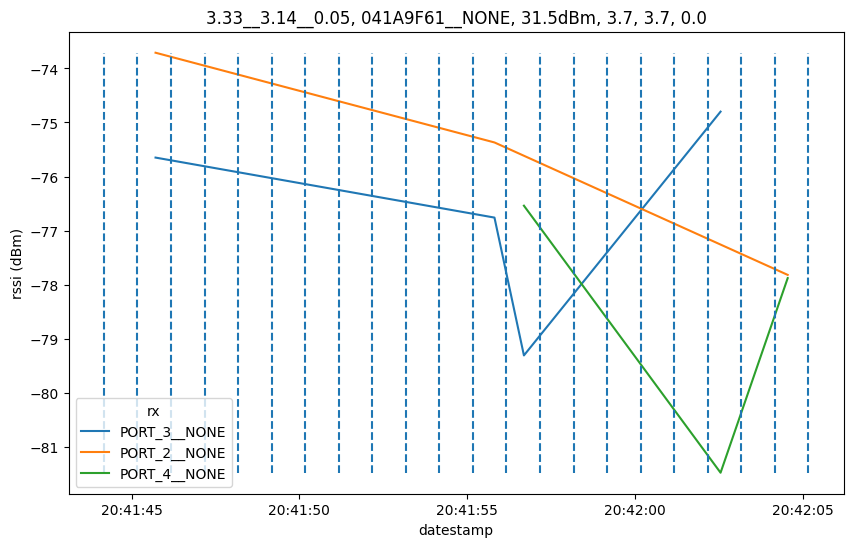

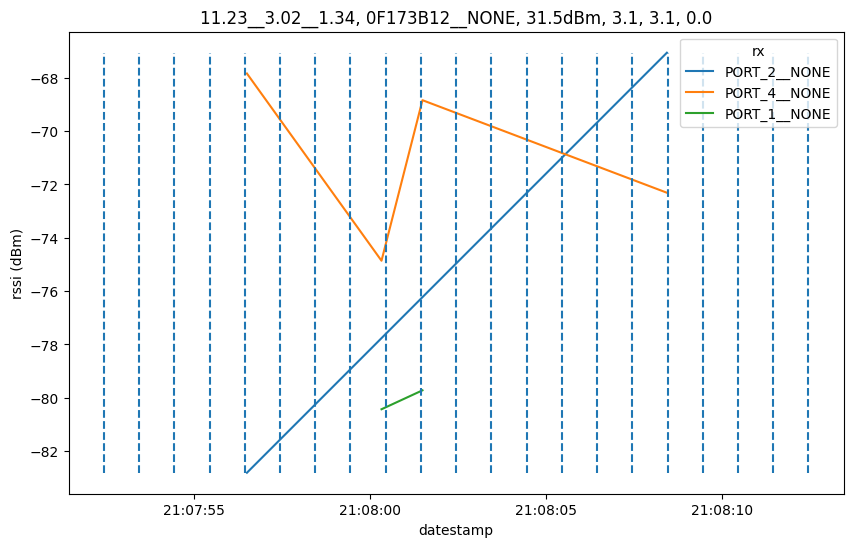

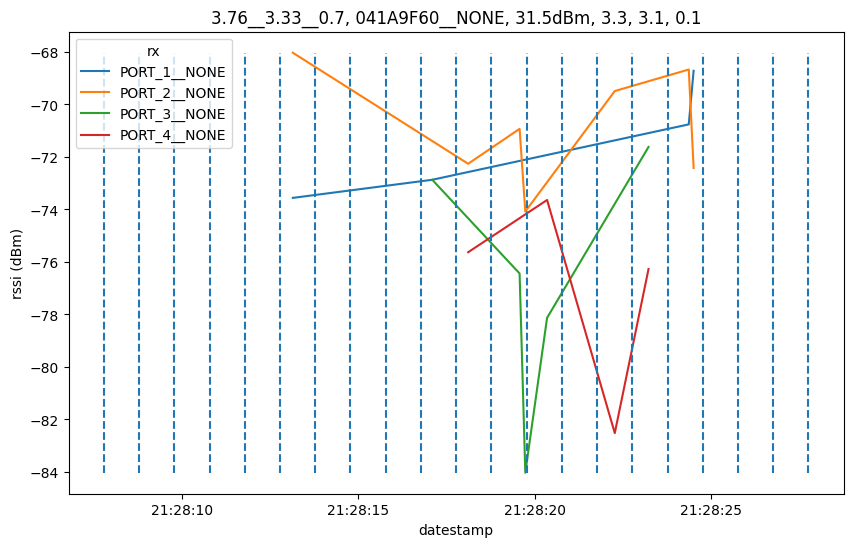

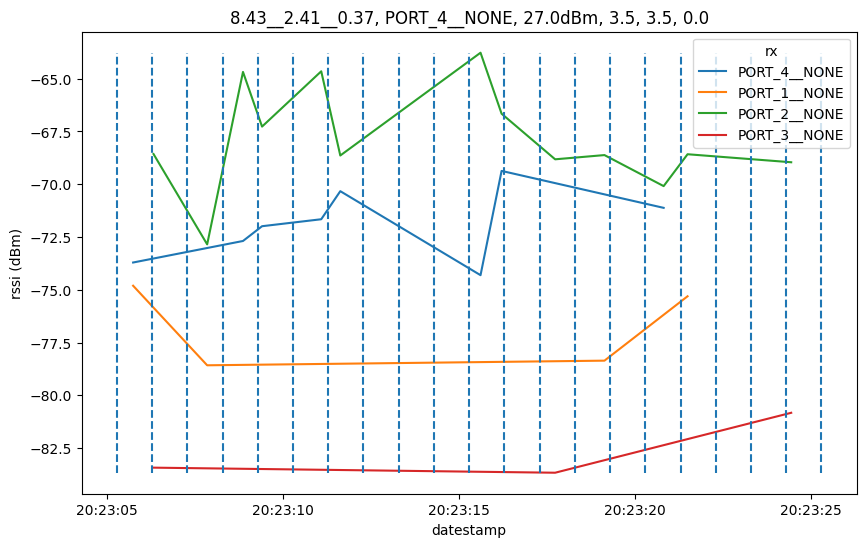

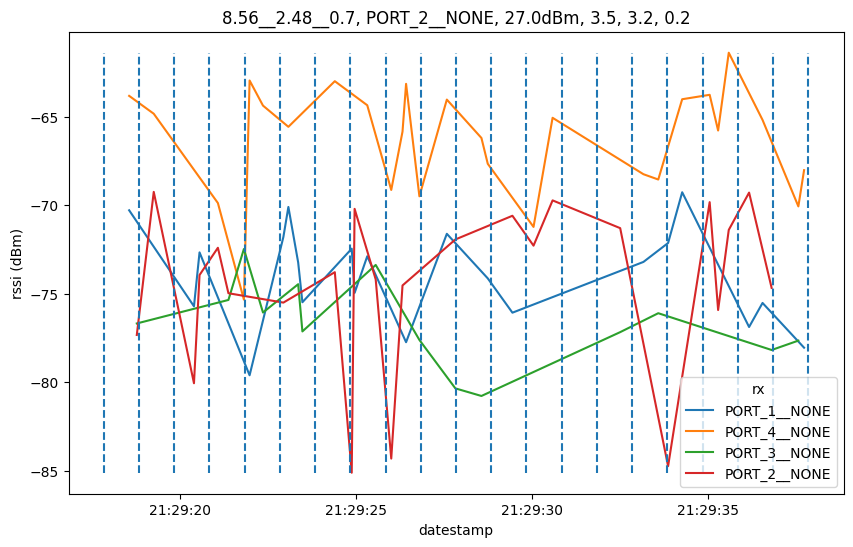

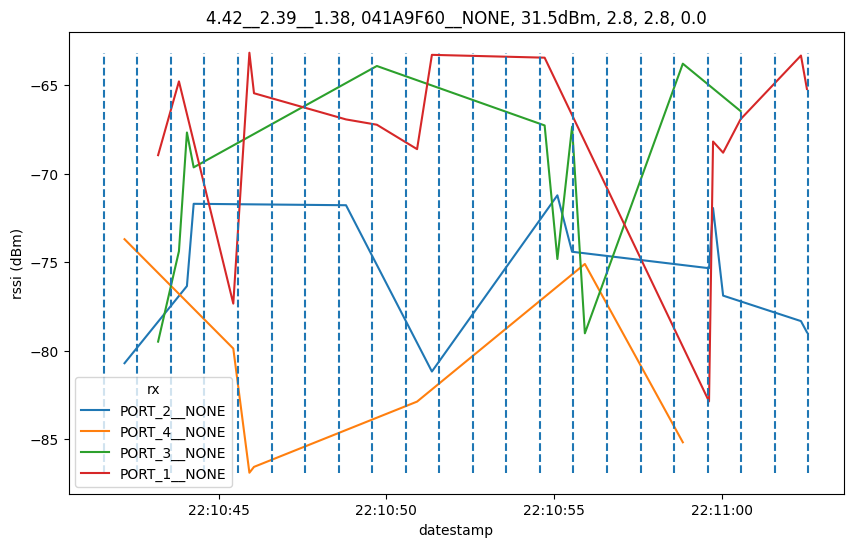

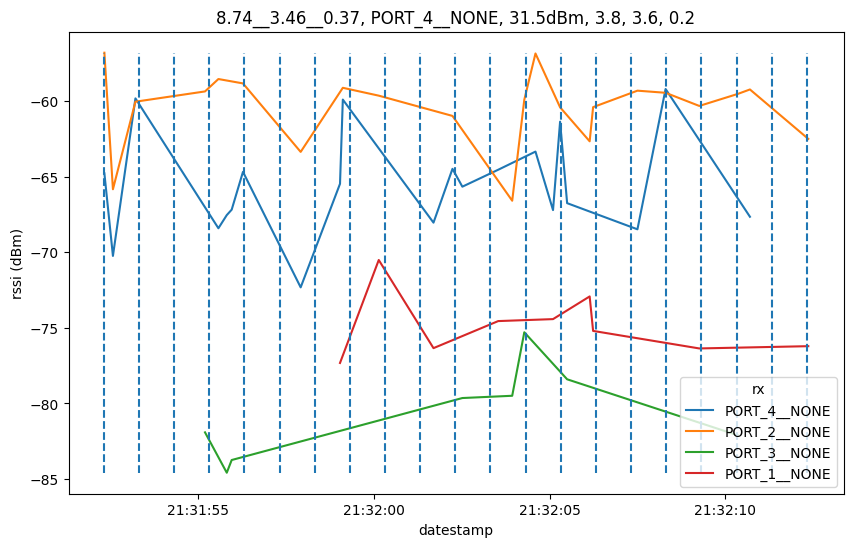

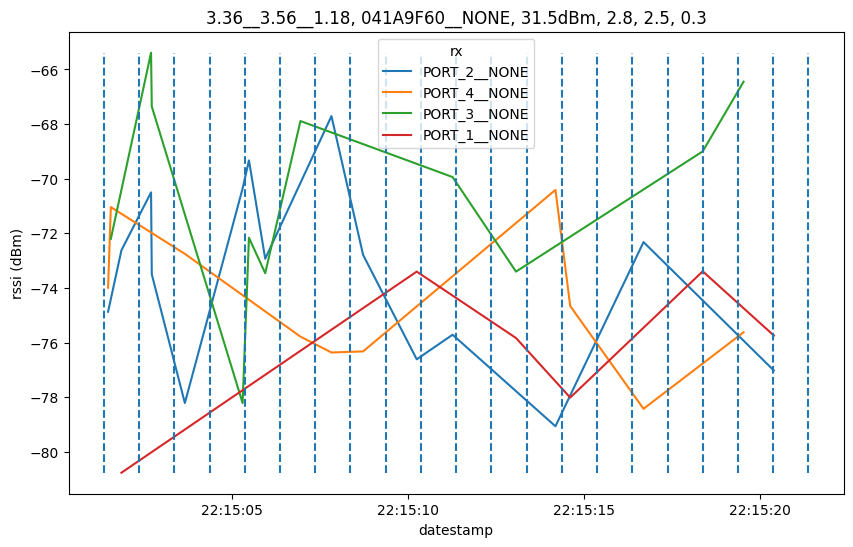

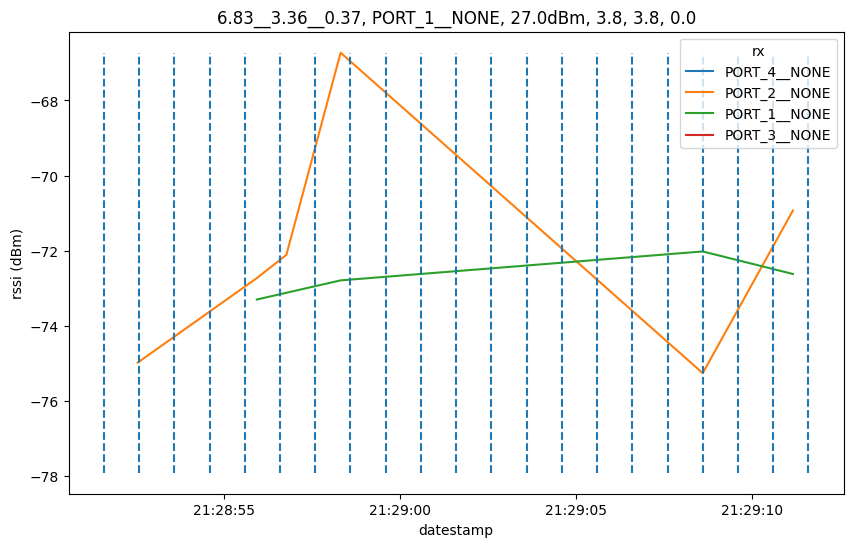

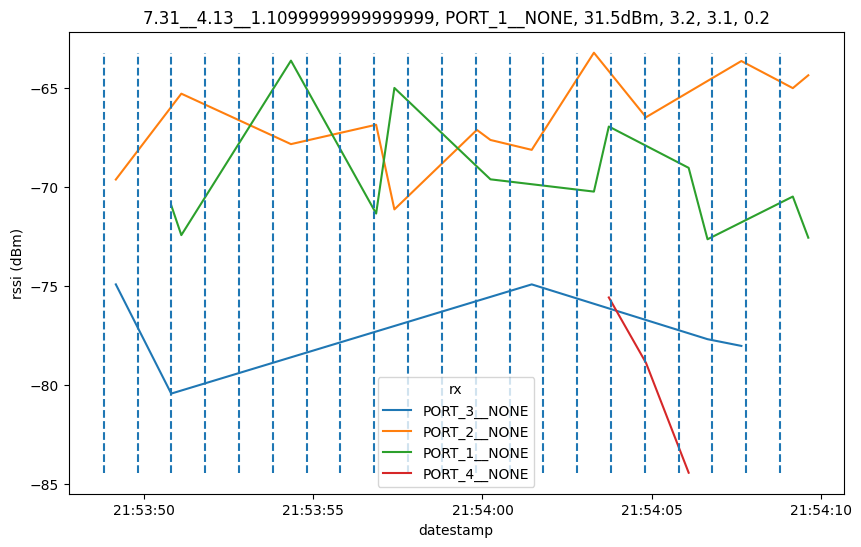

In [ ]:
easy = ds_rssimax_1Tx [ds_rssimax_1Tx['Delta_D']<0.5]

for i, row in easy.sample(10).iterrows():
  EPC=row['EPC']
  xyz=row['xyz']
  Tx = row['Tx']
  txPower_dBm=row['txPower_dBm']
  run=row['run']
  nearestD = row['nearestD']
  DTxMax = row['DTxMax']
  Delta_D = row['Delta_D']

  tags_display = tags_pick [ (tags_pick['EPC']==EPC) & (tags_pick['run']==run) ]
  plt.figure(figsize=(10,6))
  sns.lineplot(data=tags_display, x='datestamp', y='rssi (dBm)', hue='rx')

  rssi_min = tags_display['rssi (dBm)'].min()
  rssi_max = tags_display['rssi (dBm)'].max()
  Slots_run = Slots [Slots['run']==run]
  plt.vlines(Slots_run['slotStart'], ymin=rssi_min, ymax=rssi_max, linestyles='--')
  plt.title(f'{xyz}, {Tx}, {txPower_dBm}dBm, {DTxMax:.1f}, {nearestD:.1f}, {Delta_D:.1f}')
  plt.show()





In [ ]:
tags_pick.columns

Index(['run', 'datestamp', 'EPC', 'txPower_dBm', 'Tx', 'rx', 'rssi (dBm)',
       'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi', 'Tx_sequence',
       'antRound', 'antRound_duration', 'slot_id', 'slotStart', 'x', 'y', 'z',
       'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE', '0F173B12__NONE',
       '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE',
       'PORT_4__NONE', 'nearestAnt', 'nearestD'],
      dtype='object')

# freq duration

In [ ]:
def func(df):
  df['freq_round'] = (df['freq_MHz']!=df['freq_MHz'].shift(1)).cumsum()
  return df
temp = tags_pick.groupby(['run']).apply(func).reset_index(drop=True)
temp


/tmp/ipykernel_896/3970762602.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = tags_pick.groupby(['run']).apply(func).reset_index(drop=True)


,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,...,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,xy,freq_round
0,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,...,9.620088,9.948171,4.881403,7.269120,4.636604,7.072348,041A9F60__NONE,2.482761,1.82__2.51,1
1,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_4__NONE,-83.32,0.004656,PORT_3__NONE|PORT_4__NONE,...,9.620088,9.948171,4.881403,7.269120,4.636604,7.072348,041A9F60__NONE,2.482761,1.82__2.51,1
2,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0604000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-76.42,0.022803,PORT_3__NONE|PORT_4__NONE,...,9.530656,9.855019,4.716715,7.159567,4.462891,6.959698,041A9F60__NONE,2.186641,1.82__2.51,1
3,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0604000000000000000000,31.5,041A9F60__NONE,PORT_4__NONE,-75.39,0.028907,PORT_3__NONE|PORT_4__NONE,...,9.530656,9.855019,4.716715,7.159567,4.462891,6.959698,041A9F60__NONE,2.186641,1.82__2.51,1
4,2026-02-04 21:23:51,2026-02-04 21:23:50.648,907.75,BA0508000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-76.44,0.022699,PORT_3__NONE|PORT_4__NONE,...,9.620088,9.948171,4.881403,7.269120,4.636604,7.072348,041A9F60__NONE,2.482761,1.82__2.51,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703775,2026-02-17 22:03:05,2026-02-17 22:03:25.435,906.25,BA0301000000000000000000,24.0,PORT_4__NONE,PORT_4__NONE,-69.90,0.102329,PORT_4__NONE|PORT_1__NONE,...,4.318866,4.518031,3.433162,2.677051,3.587841,2.680410,PORT_2__NONE,2.677051,7.86__2.99,159
703776,2026-02-17 22:03:05,2026-02-17 22:03:25.556,924.75,BA0509000000000000000000,24.0,041A9F61__NONE,PORT_4__NONE,-70.60,0.087096,PORT_4__NONE|PORT_2__NONE,...,3.955326,4.141087,3.005761,2.101095,3.181289,2.105374,PORT_2__NONE,2.101095,7.86__2.99,160
703777,2026-02-17 22:03:05,2026-02-17 22:03:25.556,924.75,BA0509000000000000000000,24.0,041A9F61__NONE,PORT_2__NONE,-67.32,0.185353,PORT_4__NONE|PORT_2__NONE,...,3.955326,4.141087,3.005761,2.101095,3.181289,2.105374,PORT_2__NONE,2.101095,7.86__2.99,160
703778,2026-02-17 22:03:05,2026-02-17 22:03:25.576,925.25,BA0502000000000000000000,24.0,0F173B12__NONE,PORT_2__NONE,-61.28,0.744732,PORT_4__NONE|PORT_2__NONE,...,3.955326,4.141087,3.005761,2.101095,3.181289,2.105374,PORT_2__NONE,2.101095,7.86__2.99,161


In [ ]:
temp.groupby(['run', 'freq_round'])['datestamp'].apply(lambda x:x.max()-x.min()).dt.total_seconds().describe()

,datestamp
count,36291.000000
mean,0.076968
std,0.041897
min,0.000000
25%,0.042000
50%,0.081000
75%,0.102000
max,0.320000


In [ ]:
tags_pick.columns

Index(['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx', 'rx',
       'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi',
       'Tx_sequence', 'antRound', 'antRound_duration', 'slot_id', 'slotStart',
       'x', 'y', 'z', 'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE',
       '0F173B12__NONE', '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE',
       'PORT_3__NONE', 'PORT_4__NONE', 'nearestAnt', 'nearestD', 'xy',
       'Tx, rx'],
      dtype='object')

In [ ]:
tags_pick.groupby(['EPC', 'xyz'])['freq_MHz'].nunique().describe()

,freq_MHz
count,4411.000000
mean,34.804353
std,12.272955
min,1.000000
25%,27.000000
50%,38.000000
75%,45.000000
max,50.000000


In [ ]:
tags_pick.groupby(['EPC', 'xyz', 'txPower_dBm', 'Tx', 'rx'])['freq_MHz'].nunique().describe()

,freq_MHz
count,183273.000000
mean,3.645840
std,2.933278
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,25.000000


# ds

In [302]:
tags_pick[:1]

,run,datestamp,freq_MHz,EPC,txPower_dBm,Tx,rx,rssi (dBm),rssi,rx1_rx2_ant,...,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD,xy
0,2026-02-04 21:23:51,2026-02-04 21:23:50.647,907.75,BA0507000000000000000000,31.5,041A9F60__NONE,PORT_3__NONE,-77.97,0.015959,PORT_3__NONE|PORT_4__NONE,...,2.747017,9.620088,9.948171,4.881403,7.26912,4.636604,7.072348,041A9F60__NONE,2.482761,1.82__2.51


In [303]:
tags_pick.shape, tags_pick['xyz'].nunique()

((703780, 33), 444)

In [304]:
tags['rssi (dBm)'].min()

-105.09

In [305]:
tags_pick.columns

Index(['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx', 'rx',
       'rssi (dBm)', 'rssi', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi',
       'Tx_sequence', 'antRound', 'antRound_duration', 'slot_id', 'slotStart',
       'x', 'y', 'z', 'xyz', 'polar', '041A9F60__NONE', '041A9F61__NONE',
       '0F173B12__NONE', '0F173B13__NONE', 'PORT_1__NONE', 'PORT_2__NONE',
       'PORT_3__NONE', 'PORT_4__NONE', 'nearestAnt', 'nearestD', 'xy'],
      dtype='object')

## basic: all Tx, no Rx

In [306]:
index_pivot = ['EPC', 'xyz']

ds_rssi=pd.DataFrame()
ds_Delta_rssi=pd.DataFrame()

aggfunc_list=[max]
# aggfunc_list=[max, min, np.mean]

Values=['rssi']
fill_value=0

columns_pivot = ['txPower_dBm', 'Tx']
# columns_pivot = ['txPower_dBm', 'Tx', 'slot_id']
# columns_pivot = ['txPower_dBm', 'Tx', 'freq_MHz']
# columns_pivot = ['txPower_dBm', 'Tx']
# columns_pivot = ['Tx']

ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

Values=['Delta_rssi']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

/tmp/ipykernel_4390/3467826113.py:18: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
/tmp/ipykernel_4390/3467826113.py:22: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \


,EPC,xyz,max__rssi__24.0__041A9F60__NONE,max__rssi__24.0__041A9F61__NONE,max__rssi__24.0__0F173B12__NONE,max__rssi__24.0__0F173B13__NONE,max__rssi__24.0__PORT_1__NONE,max__rssi__24.0__PORT_2__NONE,max__rssi__24.0__PORT_3__NONE,max__rssi__24.0__PORT_4__NONE,...,max__Delta_rssi__27.0__PORT_3__NONE,max__Delta_rssi__27.0__PORT_4__NONE,max__Delta_rssi__31.5__041A9F60__NONE,max__Delta_rssi__31.5__041A9F61__NONE,max__Delta_rssi__31.5__0F173B12__NONE,max__Delta_rssi__31.5__0F173B13__NONE,max__Delta_rssi__31.5__PORT_1__NONE,max__Delta_rssi__31.5__PORT_2__NONE,max__Delta_rssi__31.5__PORT_3__NONE,max__Delta_rssi__31.5__PORT_4__NONE
0,BA0101000000000000000000,1.82__2.51__0.05,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.01564,-0.009261,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.214783,0.000000,0.0,0.807235,0.719449,0.879023,...,-0.289816,0.241296,0.00000,0.000000,0.238030,0.209454,-0.269141,0.072880,-0.004414,0.439902
2,BA0101000000000000000000,10.34__3.33__0.05,0.0,0.0,0.000000,0.000000,0.0,0.152757,0.000000,0.212814,...,0.000000,0.040979,0.00000,0.000000,0.044310,-0.023592,0.010713,0.149984,-0.004069,0.000000
3,BA0101000000000000000000,10.51__3.26__0.05,0.0,0.0,0.000000,0.000000,0.0,0.185353,0.000000,0.294442,...,0.000000,0.044609,0.00000,0.000000,0.076531,0.072418,-0.064579,0.184844,-0.004674,0.095776
4,BA0101000000000000000000,10.71__3.92__1.57,0.0,0.0,0.239332,0.203704,0.0,0.133968,0.000000,0.204644,...,-0.111259,0.085614,0.00000,0.000000,0.026609,0.018273,0.000000,0.057286,-0.103800,0.068389


In [307]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

,EPC,xyz,max__rssi__24.0__041A9F60__NONE,max__rssi__24.0__041A9F61__NONE,max__rssi__24.0__0F173B12__NONE,max__rssi__24.0__0F173B13__NONE,max__rssi__24.0__PORT_1__NONE,max__rssi__24.0__PORT_2__NONE,max__rssi__24.0__PORT_3__NONE,max__rssi__24.0__PORT_4__NONE,...,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,1.82__2.51__0.05,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.214783,0.000000,0.0,0.807235,0.719449,0.879023,...,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
2,BA0101000000000000000000,10.34__3.33__0.05,0.0,0.0,0.000000,0.000000,0.0,0.152757,0.000000,0.212814,...,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901
3,BA0101000000000000000000,10.51__3.26__0.05,0.0,0.0,0.000000,0.000000,0.0,0.185353,0.000000,0.294442,...,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631
4,BA0101000000000000000000,10.71__3.92__1.57,0.0,0.0,0.239332,0.203704,0.0,0.133968,0.000000,0.204644,...,8.345502,8.264103,3.378372,2.774779,5.525885,3.213627,6.038990,3.751986,0F173B13__NONE,2.774779


In [308]:
ds[Xcols_ds].isna().mean().mean()

np.float64(0.0)

In [309]:
Xcols_ds

['max__rssi__24.0__041A9F60__NONE',
 'max__rssi__24.0__041A9F61__NONE',
 'max__rssi__24.0__0F173B12__NONE',
 'max__rssi__24.0__0F173B13__NONE',
 'max__rssi__24.0__PORT_1__NONE',
 'max__rssi__24.0__PORT_2__NONE',
 'max__rssi__24.0__PORT_3__NONE',
 'max__rssi__24.0__PORT_4__NONE',
 'max__rssi__27.0__041A9F60__NONE',
 'max__rssi__27.0__041A9F61__NONE',
 'max__rssi__27.0__0F173B12__NONE',
 'max__rssi__27.0__0F173B13__NONE',
 'max__rssi__27.0__PORT_1__NONE',
 'max__rssi__27.0__PORT_2__NONE',
 'max__rssi__27.0__PORT_3__NONE',
 'max__rssi__27.0__PORT_4__NONE',
 'max__rssi__31.5__041A9F60__NONE',
 'max__rssi__31.5__041A9F61__NONE',
 'max__rssi__31.5__0F173B12__NONE',
 'max__rssi__31.5__0F173B13__NONE',
 'max__rssi__31.5__PORT_1__NONE',
 'max__rssi__31.5__PORT_2__NONE',
 'max__rssi__31.5__PORT_3__NONE',
 'max__rssi__31.5__PORT_4__NONE',
 'max__Delta_rssi__24.0__041A9F60__NONE',
 'max__Delta_rssi__24.0__041A9F61__NONE',
 'max__Delta_rssi__24.0__0F173B12__NONE',
 'max__Delta_rssi__24.0__0F173B13_

In [310]:
len(Xcols_ds)

48

In [311]:
ds.shape, ds[Xcols_ds].shape[0]*ds[Xcols_ds].shape[1]

((4411, 64), 211728)

In [312]:
(ds[Xcols_ds]==0).sum().sum()

np.int64(104971)

In [313]:
# (ds[Xcols_ds]==0).mean()

In [314]:
tags_pick.groupby('run')['freq_MHz'].nunique().describe()

,freq_MHz
count,222.000000
mean,49.698198
std,0.726920
min,45.000000
25%,50.000000
50%,50.000000
75%,50.000000
max,50.000000


In [315]:
tags_pick.groupby(['EPC', 'xyz', 'txPower_dBm', 'Tx']) ['rx1_rx2_ant'].nunique().describe()

,rx1_rx2_ant
count,53398.000000
mean,3.297071
std,2.214175
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,12.000000


In [316]:
tags_pick.groupby(['EPC', 'xyz', 'txPower_dBm', 'Tx', 'rx1_rx2_ant']) ['Delta_rssi (dBm)'].mean().describe()

,Delta_rssi (dBm)
count,176057.000000
mean,-2.794783
std,8.107627
min,-32.465000
25%,-8.422000
50%,-3.090000
75%,2.508000
max,38.250000


## advanced: (Tx, Rx)

In [ ]:
index_pivot = ['EPC', 'xyz']

ds_rssi=pd.DataFrame()
ds_Delta_rssi=pd.DataFrame()


aggfunc_list=[max]
# aggfunc_list=[max, min]

Values=['rssi']
columns_pivot = ['txPower_dBm', 'Tx', 'rx', 'freq_MHz']
# columns_pivot = ['txPower_dBm', 'Tx', 'rx']
fill_value=0
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

# Values=['Delta_rssi']
# columns_pivot = ['txPower_dBm', 'Tx', 'rx1_rx2_ant']
columns_pivot = ['txPower_dBm', 'Tx', 'rx1_rx2_ant', 'freq_MHz']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

/tmp/ipykernel_896/3889226019.py:14: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
/tmp/ipykernel_896/3889226019.py:20: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \


,EPC,xyz,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__902.75,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__903.25,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__903.75,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__904.25,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__904.75,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__905.25,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__905.75,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE__906.25,...,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__922.75,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__923.25,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__923.75,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__924.25,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__924.75,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__925.25,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__925.75,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__926.25,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__926.75,max__rssi__31.5__PORT_4__NONE__PORT_4__NONE|PORT_3__NONE__927.25
0,BA0101000000000000000000,1.82__2.51__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.450817,0.0,0.0
2,BA0101000000000000000000,10.34__3.33__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,BA0101000000000000000000,10.51__3.26__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.112720,0.0,0.0
4,BA0101000000000000000000,10.71__3.92__1.57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.11272,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [ ]:
len(Xcols_ds)

12889

In [ ]:
ds.shape, ds[Xcols_ds].shape[0]*ds[Xcols_ds].shape[1]

((4411, 278), 1217436)

In [ ]:
(ds[Xcols_ds]==0).sum().sum()

np.int64(858206)

In [ ]:
Xcols_ds

['max__rssi__24.0__041A9F60__NONE__PORT_1__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_2__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_3__NONE',
 'max__rssi__24.0__041A9F60__NONE__PORT_4__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_1__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_2__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_3__NONE',
 'max__rssi__24.0__041A9F61__NONE__PORT_4__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_1__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_2__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_3__NONE',
 'max__rssi__24.0__0F173B12__NONE__PORT_4__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_1__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_2__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_3__NONE',
 'max__rssi__24.0__0F173B13__NONE__PORT_4__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_1__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_2__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_3__NONE',
 'max__rssi__24.0__PORT_1__NONE__PORT_4__NONE',
 'max__r

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

,EPC,xyz,max__rssi__24.0__041A9F60__NONE__PORT_1__NONE,max__rssi__24.0__041A9F60__NONE__PORT_2__NONE,max__rssi__24.0__041A9F60__NONE__PORT_3__NONE,max__rssi__24.0__041A9F60__NONE__PORT_4__NONE,max__rssi__24.0__041A9F61__NONE__PORT_1__NONE,max__rssi__24.0__041A9F61__NONE__PORT_2__NONE,max__rssi__24.0__041A9F61__NONE__PORT_3__NONE,max__rssi__24.0__041A9F61__NONE__PORT_4__NONE,...,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE,nearestAnt,nearestD
0,BA0101000000000000000000,1.82__2.51__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592,041A9F60__NONE,3.695808
1,BA0101000000000000000000,10.1__3.82__1.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160,PORT_2__NONE,3.061454
2,BA0101000000000000000000,10.34__3.33__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191,PORT_2__NONE,4.292901
3,BA0101000000000000000000,10.51__3.26__0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947,0F173B12__NONE,4.367631
4,BA0101000000000000000000,10.71__3.92__1.57,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.345502,8.264103,3.378372,2.774779,5.525885,3.213627,6.038990,3.751986,0F173B13__NONE,2.774779


In [ ]:
ds.shape

(4411, 196)

In [ ]:
Sample = ['EPC', 'x', 'y', 'z'] + Cols_D
ds [Sample]

,EPC,x,y,z,041A9F60__NONE,041A9F61__NONE,0F173B12__NONE,0F173B13__NONE,PORT_1__NONE,PORT_2__NONE,PORT_3__NONE,PORT_4__NONE
0,BA0101000000000000000000,1.82,2.51,0.05,3.695808,3.878273,10.066330,10.405143,5.665421,7.817225,5.455914,7.634592
1,BA0101000000000000000000,10.10,3.82,1.29,7.826270,7.752193,3.633249,3.209751,5.119033,3.061454,5.617517,3.558160
2,BA0101000000000000000000,10.34,3.33,0.05,8.410172,8.437594,4.415314,4.387596,6.066383,4.292901,6.320364,4.483191
3,BA0101000000000000000000,10.51,3.26,0.05,8.553958,8.595941,4.367631,4.368776,6.205336,4.376551,6.431501,4.540947
4,BA0101000000000000000000,10.71,3.92,1.57,8.345502,8.264103,3.378372,2.774779,5.525885,3.213627,6.038990,3.751986
...,...,...,...,...,...,...,...,...,...,...,...,...
4406,BA0610000000000000000000,8.87,4.79,1.67,6.875893,6.540176,4.471007,3.601375,3.955490,2.467772,5.021344,3.525606
4407,BA0610000000000000000000,9.01,3.85,1.67,6.709061,6.598750,3.806245,3.425712,3.993933,2.288122,4.606897,2.899569
4408,BA0610000000000000000000,9.30,3.70,1.67,6.944415,6.877129,3.576996,3.258358,4.245339,2.371265,4.760557,2.888408
4409,BA0610000000000000000000,9.57,2.71,2.29,6.914412,7.078213,2.518154,2.891557,4.385556,2.219257,4.401488,2.081610


In [ ]:
print(Xcols_ds)

['max__rssi__24.0__041A9F60__NONE__PORT_1__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_2__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_3__NONE', 'max__rssi__24.0__041A9F60__NONE__PORT_4__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_1__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_2__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_3__NONE', 'max__rssi__24.0__041A9F61__NONE__PORT_4__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_1__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_2__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_3__NONE', 'max__rssi__24.0__0F173B12__NONE__PORT_4__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_1__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_2__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_3__NONE', 'max__rssi__24.0__0F173B13__NONE__PORT_4__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_1__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_2__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_3__NONE', 'max__rssi__24.0__PORT_1__NONE__PORT_4__NONE', 'max__rssi__24.0__PORT_2__N

In [ ]:
EPC = 'BA0103000000000000000000'
xyz = '5.68__2.46__1.28'
Tx = 'PORT_2__NONE'
txPower_dBm = 24.0
run = pd.to_datetime('2026-02-11 21:49:40')
ds_pick = ds[ (ds['EPC']==EPC) & (ds['xyz']==xyz) ]
Xcols_ds_pick = ['max__rssi__24.0__PORT_2__NONE__PORT_1__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_2__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_3__NONE', 'max__rssi__24.0__PORT_2__NONE__PORT_4__NONE']
10*np.log10(ds_pick[Xcols_ds_pick]*10**(-6))

,max__rssi__24.0__PORT_2__NONE__PORT_1__NONE,max__rssi__24.0__PORT_2__NONE__PORT_2__NONE,max__rssi__24.0__PORT_2__NONE__PORT_3__NONE,max__rssi__24.0__PORT_2__NONE__PORT_4__NONE
78,-62.91,-68.79,-55.88,-74.72


In [ ]:
[x.split('__')[-1] for x in Xcols_ds_pick]

['NONE', 'NONE', 'NONE', 'NONE']

## per Tx, all rx

tags_pick: txPower=31.5 only + duration=2sec

In [ ]:
index_pivot = ['EPC', 'run', 'xyz', 'txPower_dBm', 'Tx' ]

aggfunc_list=[max]
# aggfunc_list=[max, min]

Values=['rssi']
columns_pivot = ['rx']
fill_value=0
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

Values=['Delta_rssi']
columns_pivot = ['rx1_rx2_ant']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=fill_value)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

# ds = ds_rssi.copy()

ds = ds.fillna(0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

### check at least 10 samples (train_test_split) per txPower, Tx, rx

In [ ]:
ds.groupby(['Tx', 'txPower_dBm']).size().describe()

In [ ]:
ds.shape

In [ ]:
size = ds.groupby(['Tx', 'txPower_dBm']).size().rename('size').reset_index(drop=False)
ds = pd.merge(ds, size, on=['Tx', 'txPower_dBm'])
ds = ds [ds['size']>=10]
ds.shape


In [ ]:
ds = pd.merge(ds, Actuals_xyz_D_run.drop(columns=['xyz']), on=['EPC', 'run'])
ds.head()

In [ ]:
ds.shape

In [ ]:
Xcols_ds

In [ ]:
index=['run', 'EPC', 'Tx', 'txPower_dBm']
columns=['rx']
Values=['rssi']

aggfunc=[max]

ds = pd.pivot_table(tags_pick, index=index, columns=columns, values=Values, aggfunc=aggfunc, fill_value=0)
Xcols_ds = ['_'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds.head()

In [ ]:
Actuals_xyz_D_run[:1]

In [ ]:
ds.shape

In [ ]:
# ds_temp = pd.merge(ds_temp, Actuals_xyz_D_run, on=['EPC', 'run'])
# ds_temp.shape

ds = pd.merge(ds, Actuals_xyz_D_run, on=['EPC', 'run'])
ds.head()

In [ ]:
ds.shape

In [ ]:
def func(df):
  Tx=df['Tx'].values[0]
  df['TxD'] = df[Tx]
  return df
ds = ds.groupby('Tx').apply(func).reset_index(drop=True)
ds.head()

In [ ]:
ds['TxD'].describe()

In [ ]:
ds.head()

In [ ]:
ds[['EPC', 'x', 'y', 'z', 'Tx', 'TxD', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE', 'PORT_4__NONE']]

In [ ]:
ds[['EPC', 'x', 'y', 'z', 'txPower_dBm', 'Tx'] + Xcols_ds]

In [ ]:
Xcols_ds

In [ ]:
tags_pick[:2]

In [ ]:
# PX
aggfunc_list = [max, min]
index_pivot = ['EPC', 'xyz']

# columns_pivot = ['txPower_dBm', 'Tx', 'rx']
columns_pivot = ['txPower_dBm', 'Tx']
# Values=['rssi']
Values=['rssi']

ds = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)
ds.head()

In [ ]:
ds.shape

In [ ]:
tags_pick['rx1_rx2_ant'].unique()

In [ ]:
# PX
aggfunc_list = [max]
index_pivot = ['EPC', 'xyz']
# columns_pivot = ['txPower_dBm', 'Tx', 'rx']
columns_pivot = ['txPower_dBm', 'Tx']
Values=['rssi']
ds_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

# columns_pivot = ['txPower_dBm', 'Tx', 'rx1_rx2_ant']
columns_pivot = ['txPower_dBm', 'Tx']

Values=['Delta_rssi']
ds_Delta_rssi = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list, fill_value=0)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)

ds = ds.fillna(0)
ds.head()

In [ ]:
ds.shape

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.head()

In [ ]:
ds.shape

In [ ]:
len(Xcols_ds)

In [ ]:
# file='ds_Tx_Rx.csv'
file='ds_elemen.csv'
ds.to_csv(file, index=False)
temp = pd.read_csv(file)
Xcols_ds = [x for x in temp.columns if 'rssi' in x]
len(Xcols_ds)

In [ ]:
(ds==0).sum().sum()

In [ ]:
ds.shape

In [ ]:
tags_pick[:2]

In [ ]:
# PX
# aggfunc_list = [max, min, np.mean]
aggfunc_list = [max, min]
# aggfunc_list = [max]
# aggfunc_list = [np.mean]
# aggfunc_list = [max]

index_pivot = ['EPC', 'xyz']
columns_pivot = ['txPower_dBm', 'Tx']
Values = ['rssi1', 'rssi2', 'Delta_rssi']

ds = pd.pivot_table(tags_pick, index=index_pivot, columns=columns_pivot, \
                              values=Values, aggfunc=aggfunc_list)

Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds

ds = ds.reset_index(drop=False)

ds = ds.fillna(0)
ds.head()

In [ ]:
ds.shape

In [ ]:
(ds[Xcols_ds]==0).sum().sum()

### merge with Actuals_xyz_D

In [ ]:
ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'])
ds.shape

In [ ]:
# file='ds_basic_18Feb26.csv'
# ds.to_csv(file, index=False)
# temp = pd.read_csv(file)
# Xcols_ds_lin = [x for x in temp.columns if 'rssi' in x]
# len(Xcols_ds_lin)

# **multiple Regressors**


In [ ]:
# # Regression (RF, ET, GB, KNN, Ridge, DecisionTree, NN)

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


X_reg = ds[Xcols_ds].values
y_reg = ds[['x', 'y', 'z']].values
idx_all = ds.index.to_numpy()   # keep track of original indices

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_reg, y_reg, idx_all,
    test_size=0.2,
    random_state=0
)


# # Define candidate regressors

regressors = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=0),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200, random_state=0),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Ridge": Ridge(alpha=1.0),
    "DecisionTree": DecisionTreeRegressor(random_state=0),
    "NN": MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation='relu',
        random_state=0,
        max_iter=1000,
        early_stopping=True
    ),
}

reg_results = {}    # RMSE per model
reg_errors = {}     # per-sample 3D distance error per model
y_pred_store = {}   # store predictions per model
best_model = None   # trained RandomForest model


for name, base_reg in regressors.items():
    model = MultiOutputRegressor(base_reg)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    # 3D RMSE on (x, y, z)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    reg_results[name] = rmse

    # per-sample Euclidean distance in 3D
    dists = np.linalg.norm(y_pred - y_test, axis=1)
    reg_errors[name] = dists

    # store predictions for later analysis (Task 3 & 4)
    y_pred_store[name] = y_pred

    print(
        f"{name}: 3D RMSE = {rmse:.3f} m, "
        f"mean |error| = {dists.mean():.3f} m, "
        f"median |error| = {np.median(dists):.3f} m"
    )

    # keep RandomForest as final model if it is good otherwise change it
    if name == "RandomForest":
         best_model = model

reg_results


# BEST regressor

## Values

In [317]:
Values_xyz = ['x', 'y', 'z']
# Values_xyz = ['x', 'y']
Values_xyz_pred = [x+'_pred' for x in Values_xyz]

Values_D = Cols_D
Values_D =  ['TxD', 'PORT_1__NONE', 'PORT_2__NONE', 'PORT_3__NONE', 'PORT_4__NONE']
Values_D_pred = [x+'_pred' for x in Values_D]

In [318]:
Values_pick = Values_xyz
# Values_pick = Cols_D
# Values_pick = Values_xyz + Cols_D
Values_pick_pred = [x+'_pred' for x in Values_pick]

In [319]:
Values_xyz

['x', 'y', 'z']

In [320]:
Values_pick_pred

['x_pred', 'y_pred', 'z_pred']

## Tx, (Tx, Rx)

### train_test_split, Kfold=5

shuffle

In [322]:
ds = ds.sample(frac=1).reset_index(drop=True)
ds.shape, len(Xcols_ds)

((4411, 64), 48)

In [323]:
# clf = RandomForestRegressor()
# clf = KNeighborsRegressor(n_neighbors=5)
clf = ExtraTreesRegressor()
target = Values_pick
target_pred = Values_pick_pred
for ds_test in np.array_split(ds, 5):
  idx_test = ds_test.index
  idx_train = [x for x in ds.index if x not in idx_test]
  ds_train = ds.loc[idx_train]
  X_train = ds_train.loc[:, Xcols_ds]
  X_test = ds_test.loc[:, Xcols_ds]
#

  y_train = ds_train.loc[:, target]
  y_test = ds_test.loc[:, target]
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  ds.loc[idx_test, target_pred] = y_pred

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [324]:
mse = mean_squared_error(ds[target].values, ds[target_pred].values)
rmse = np.sqrt(mse)
rmse

np.float64(0.7236434835329684)

In [325]:
np.sqrt(mean_squared_error(ds[target].values, ds[target_pred].values, multioutput='raw_values'))

array([0.85232521, 0.64794218, 0.65168423])

In [326]:
ds['err'] = [np.sqrt((x**2).sum()) for x in (ds[Values_xyz].values-ds[Values_xyz_pred].values)]
ds['err'].describe()

,err
count,4411.000000
mean,1.107601
std,0.586752
min,0.048616
25%,0.713039
50%,1.010960
75%,1.382218
max,6.341301


In [327]:
ds['err'].median()

1.010960320685236

In [ ]:
mse = mean_squared_error(ds[Values_xyz].values, ds[Values_xyz_pred].values)
rmse = np.sqrt(mse)
rmse

np.float64(0.8999370779491911)

In [ ]:
ds[ds['err']<1].shape[0]/ds.shape[0], ds[ds['err']<2].shape[0]/ds.shape[0], ds[ds['err']<3].shape[0]/ds.shape[0]

(0.30693970420932876, 0.8304891922639362, 0.9622298065984073)

In [ ]:
# ds.to_csv('ds_power_tx_rx_freq.csv', index=False)

In [ ]:
# tags_pick.to_csv('tags_pick_power_tx_rx_freq.csv', index=False)

In [ ]:
len(Xcols_ds)

4800

## per Tx, txPower, all rx

In [ ]:
ds.head()

In [ ]:
ds.groupby(['txPower_dBm', 'Tx']).size().describe()

In [ ]:
ds = ds.sample(frac=1).reset_index(drop=True)
ds.shape, len(Xcols_ds)

In [ ]:
def func(df):
  clf = ExtraTreesRegressor()
  target = Values_pick
  target_pred = Values_pick_pred
  for ds_test in np.array_split(df, 5):
    idx_test = ds_test.index
    idx_train = [x for x in df.index if x not in idx_test]
    ds_train = df.loc[idx_train]
    X_train = ds_train.loc[:, Xcols_ds]
    X_test = ds_test.loc[:, Xcols_ds]
#

    y_train = ds_train.loc[:, target]
    y_test = ds_test.loc[:, target]
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    df.loc[idx_test, target_pred] = y_pred
  return df


ds = ds.groupby(['txPower_dBm', 'Tx']).apply(func).reset_index(drop=True)
ds.head()

In [ ]:
ds.groupby(['txPower_dBm', 'Tx' ]).apply(lambda x:mean_squared_error(x[Values_pick].values, x[Values_pick_pred].values)).rename('rmse')

In [ ]:
ds.groupby(['txPower_dBm', 'Tx' ]).apply(lambda x:mean_squared_error(x[Values_pick].values, x[Values_pick_pred].values)).describe()

In [ ]:
ds['err'] = [np.sqrt((x**2).sum()) for x in (ds[Values_xyz].values-ds[Values_xyz_pred].values)]
ds['err'].describe()

In [ ]:
ds[ds['err']<1].shape[0]/ds.shape[0], ds[ds['err']<2].shape[0]/ds.shape[0], ds[ds['err']<3].shape[0]/ds.shape[0]

In [ ]:
ds.groupby(['EPC', 'xyz']).size().describe()

In [ ]:
final = ds.groupby(['EPC', 'xyz']+Values_pick)[Values_pick_pred].mean().reset_index(drop=False)
final

mse = mean_squared_error(final[Values_pick].values, final[Values_pick_pred].values)
rmse = np.sqrt(mse)
rmse

In [ ]:
final['err'] = [np.sqrt((x**2).sum()) for x in (final[Values_xyz].values-final[Values_xyz_pred].values)]
final['err'].describe()

In [ ]:
# file='ds_9March26.csv'
# ds.to_csv(file, index=False)
# temp = pd.read_csv(file)
# Xcols_ds = [x for x in temp.columns if 'max_PORT' in x]
# len(Xcols_ds)

# ANNEX

In [ ]:
# import numpy as np
# from sklearn.metrics import mean_squared_error

# cols_xyz = ['x','y','z']

# diff_xyz = y_pred[:, :3] - y_test[cols_xyz].values

# err_3d = np.linalg.norm(diff_xyz, axis=1)
# rmse_3d = np.sqrt(np.mean(err_3d**2))
# mean_err = np.mean(err_3d)
# median_err = np.median(err_3d)

# rmse_xyz = np.sqrt(mean_squared_error(y_test[cols_xyz].values, y_pred[:, :3]))

# print(f"3D RMSE (xyz only) = {rmse_3d:.3f} m")
# print(f"mean |error| = {mean_err:.3f} m, median |error| = {median_err:.3f} m")
# print(f"Per-axis RMSE over xyz = {rmse_xyz:.3f} m")
# print(f"Check: sqrt(3)*PerAxis_RMSE = {np.sqrt(3)*rmse_xyz:.3f} m")


In [ ]:

# # # METRICS (RMSE & ANTENNA ACCURACY)

# print("\n METRICS (RMSE & ANTENNA ACCURACY)")

# def to_array(data):
#     if hasattr(data, 'values'):
#         return data.values
#     return data

# # # Calculate Nearest Antenna Accuracy
# y_test_arr = to_array(y_test)
# y_pred_arr = to_array(y_pred)
# ant_coords_arr = to_array(antConf[['x', 'y', 'z']])

# # # (True vs Pred)
# true_nearest = get_nearest_antenna(y_test_arr, ant_coords_arr)
# pred_nearest = get_nearest_antenna(y_pred_arr, ant_coords_arr)

# # # Accuracy
# ant_acc = accuracy_score(true_nearest, pred_nearest)

# # # Compute RMSE
# rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))

# print(f"{'Metric':<30} | {'Value':<10}")
# print("-" * 45)
# print(f"{'RMSE (RF)':<30} | {rmse_rf:.4f} m")
# print(f"{'Nearest Antenna Accuracy':<30} | {ant_acc:.2%}")

In [ ]:
# def build_error_df(model_name="RandomForest"):
#     """
#     Returns a DataFrame with, for each test sample:
#     - original ds index
#     - true (x,y,z)
#     - predicted (x,y,z)
#     - 3D error (Euclidean distance)
#     """
#     if model_name not in y_pred_store:
#         raise ValueError(
#             f"Unknown model '{model_name}'. Available: {list(y_pred_store.keys())}"
#         )

#     y_pred = y_pred_store[model_name]
#     dists = reg_errors[model_name]

#     # Build DataFrame
#     df_err = pd.DataFrame({
#         "ds_index": idx_test,
#         "x_true": y_test[:, 0],
#         "y_true": y_test[:, 1],
#         "z_true": y_test[:, 2],
#         "x_pred": y_pred[:, 0],
#         "y_pred": y_pred[:, 1],
#         "z_pred": y_pred[:, 2],
#         "error_3D": dists,
#     })

#     # Sort by descending error
#     df_err = df_err.sort_values(
#         by="error_3D", ascending=False
#     ).reset_index(drop=True)

#     return df_err


In [ ]:
# df_err_nn = build_error_df("NN")
# df_err_nn.head()

# df_err_rf = build_error_df("RandomForest")
# df_err_nn.head()

# def show_worst_samples(model_name="RandomForest", k=5):
#     df_err = build_error_df(model_name)
#     worst = df_err.head(k)

#     print(f"Worst {k} samples for model: {model_name}")
#     display(worst)

#     cols_to_show = ["EPC", "run"] if all(c in ds.columns for c in ["EPC", "run"]) else []
#     if cols_to_show:
#         display(
#             worst.merge(
#                 ds[cols_to_show],
#                 left_on="ds_index",
#                 right_index=True,
#                 how="left"
#             )
#         )

# show_worst_samples("NN", k=5)

# from mpl_toolkits.mplot3d i/

# import numpy as np

# def cell_accuracy(y_true, y_pred, cell_size):
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)

#     true_snapped = np.round(y_true / cell_size) * cell_size
#     pred_snapped = np.round(y_pred / cell_size) * cell_size

#     same_cell = np.all(true_snapped == pred_snapped, axis=1)
#     return same_cell.mean()

# def report_cell_accuracies(model_name="RandomForest", cell_sizes=(2.0, 1.0, 0.5)):
#     y_pred = y_pred_store[model_name]
#     print(f"Cell accuracy for model: {model_name}")
#     for G in cell_sizes:
#         acc = cell_accuracy(y_test, y_pred, G)
#         print(f"  grid {G:.2f} m: {acc*100:.1f}% of test points in correct cell")

# report_cell_accuracies("RandomForest", cell_sizes=(2.0, 1.0, 0.5))
# report_cell_accuracies("NN", cell_sizes=(2.0, 1.0, 0.5))

# radii = [0.5, 1.0, 1.5, 2.0]

# for name, dists in reg_errors.items():
#     print(f"\n{name}:")
#     for R in radii:
#         frac = (dists <= R).mean()
#         print(f"  within {R:.1f} m: {frac*100:.1f}% of test points")

In [ ]:
# def visu(df, EPC='all', max_points_per_combo=800):
#     """
#     Visualize RSSI vs time for all (Tx,Rx) pairs.

#     EPC:  'all'  → all tags
#           <EPC string> → only that tag

#     max_points_per_combo: if not None, randomly subsample per (Tx,Rx)
#                           to reduce clutter.
#     """
#     import matplotlib.pyplot as plt

#     plt.rcParams.update({'axes.labelsize': 16,
#                          'xtick.labelsize': 14,
#                          'ytick.labelsize': 14})

#     # -------- Styles per (Tx,Rx) --------
#     # Colors are helpers; marker shapes carry the main information.
#     dict_styles = {
#         (1, 1): dict(marker='o',  color='tab:blue',    label='T1R1'),
#         (1, 2): dict(marker='s',  color='tab:orange',  label='T1R2'),
#         (1, 3): dict(marker='^',  color='tab:green',   label='T1R3'),
#         (1, 4): dict(marker='X',  color='tab:red',     label='T1R4'),

#         (2, 1): dict(marker='D',  color='tab:purple',  label='T2R1'),
#         (2, 2): dict(marker='v',  color='tab:brown',   label='T2R2'),
#         (2, 3): dict(marker='P',  color='tab:pink',    label='T2R3'),
#         (2, 4): dict(marker='*',  color='tab:gray',    label='T2R4'),

#         (3, 1): dict(marker='h',  color='tab:cyan',    label='T3R1'),
#         (3, 2): dict(marker='H',  color='tab:olive',   label='T3R2'),
#         (3, 3): dict(marker='<',  color='tab:blue',    label='T3R3'),
#         (3, 4): dict(marker='>',  color='tab:orange',  label='T3R4'),

#         (4, 1): dict(marker='8',  color='tab:green',   label='T4R1'),
#         (4, 2): dict(marker='p',  color='tab:red',     label='T4R2'),
#         (4, 3): dict(marker='x',  color='tab:purple',  label='T4R3'),
#         (4, 4): dict(marker='+',  color='tab:brown',   label='T4R4'),
#     }

#     # -------- Filter by EPC if needed --------
#     if EPC != 'all':
#         df = df[df['EPC'] == EPC]

#     if df.empty:
#         print("No data for this EPC.")
#         return

#     Tmax = df['datestamp'].max()
#     Tmin = df['datestamp'].min()
#     RSSImax = df['RSSI (dBm)'].max()
#     RSSImin = df['RSSI (dBm)'].min()

#     detections = len(df)
#     EPCs_unique = df['EPC'].nunique()

#     x_min = Tmin - pd.Timedelta(1, unit='s')
#     x_max = Tmax + pd.Timedelta(1, unit='s')

#     fig, ax = plt.subplots(figsize=(14, 6))

#     # -------- Plot each (Tx,Rx) --------
#     for (Tx, Rx), df_TxRx in df.groupby(['Tx', 'Rx']):
#         style = dict_styles.get(
#             (Tx, Rx),
#             dict(marker='o', color='black', label=f'T{Tx}R{Rx}')
#         )

#         # Subsample to avoid huge clouds
#         if max_points_per_combo is not None and len(df_TxRx) > max_points_per_combo:
#             df_plot = df_TxRx.sample(max_points_per_combo, random_state=0)
#         else:
#             df_plot = df_TxRx

#         ax.scatter(
#             df_plot['datestamp'],
#             df_plot['RSSI (dBm)'],
#             marker=style['marker'],
#             s=15,              # slightly smaller markers
#             alpha=0.6,
#             edgecolors='none',
#             color=style['color'],
#             label=style['label']
#         )

#     # -------- Titles & axes --------
#     title = f'EPC={EPC}, detections={detections}'
#     if EPC == 'all':
#         title += f', EPCs_unique={EPCs_unique}'
#     ax.set_title(title, size=16)

#     ax.set_xlim(x_min, x_max)
#     ax.set_ylim(RSSImin - 1, RSSImax + 1)
#     ax.set_ylabel('RSSI (dBm)')
#     ax.set_xlabel('datestamp')

#     # -------- Legend (unique labels) --------
#     handles, labels = ax.get_legend_handles_labels()
#     by_label = dict(zip(labels, handles))
#     ax.legend(by_label.values(),
#               by_label.keys(),
#               bbox_to_anchor=(1.02, 1),
#               loc='upper left',
#               fontsize=8,
#               title='Tx-Rx')

#     plt.tight_layout()
#     plt.show()

In [ ]:
# for run in tags['run'].unique():
# # for run in tags['run'].unique():
#   # print(Runs[Runs['run']==run][ ['x', 'y', 'z']] )
#   # tags_run = tags [ (tags['run'] == run)    ]
#   tags_run = tags [ (tags['run'] == run)     ]

#   visu(tags_run, 'all')


# for run in pd.Series(tags['run'].unique()).sample(1):
# # for run in tags['run'].unique():
#   # print(Runs[Runs['run']==run][ ['x', 'y', 'z']] )
#   # tags_run = tags [ (tags['run'] == run)    ]
#   print(run)
#   tags_run = tags [ (tags['run'] == run)     ]
#   epc = pd.Series(tags_run['EPC'].unique()).sample(1).values[0]
#   print(epc)
#   visu(tags_run, epc)

#   # visu(tags_run, 'all')



In [ ]:

# # Sanity Check - EPC Completeness

# print("\n CHECKING EPC COMPLETENESS")
# epc_counts = tags.groupby('run')['EPC'].nunique().reset_index()
# expected_tags = 10

# # Identify runs with missing tags
# missing_mask = epc_counts['EPC'] < expected_tags
# bad_runs = epc_counts[missing_mask]

# print(f"Total Runs: {len(epc_counts)}")
# print(f"Runs with full {expected_tags} tags: {len(epc_counts) - len(bad_runs)}")
# if not bad_runs.empty:
#     print(f"WARNING: {len(bad_runs)} runs have < {expected_tags} unique EPCs.")
#     print(bad_runs.head()) # Printing first few bad runs
# else:
#     print("SUCCESS: All runs have complete EPC coverage.")

In [ ]:
# Single self-contained cell for error analysis

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold

# =========================
# 1) Load dataset
# =========================
csv_path = "ds_elemen.csv"   # change this if your file is elsewhere

if not Path(csv_path).exists():
    raise FileNotFoundError(
        f"CSV file not found: {csv_path}\n"
        "Put 'ds_elemen.csv' in the same folder as the notebook, "
        "or change csv_path to the correct location."
    )


# =========================
# 2) Validate required columns
# =========================
true_cols = ['x', 'y', 'z']
pred_cols = ['x_pred', 'y_pred', 'z_pred']

missing_true = [c for c in true_cols if c not in ds.columns]
if missing_true:
    raise ValueError(f"Missing ground-truth columns: {missing_true}")

if 'EPC' not in ds.columns:
    raise ValueError("Missing required column: 'EPC'")

Xcols_ds = [c for c in ds.columns if 'rssi' in c.lower()]
if not Xcols_ds:
    raise ValueError("No RSSI feature columns found. Expected columns containing 'rssi'.")

# Keep only rows with complete target/features
required_cols = true_cols + Xcols_ds + ['EPC']
before_rows = len(ds)
ds = ds.dropna(subset=required_cols).reset_index(drop=True)
after_rows = len(ds)

if len(ds) < 5:
    raise ValueError(
        f"Not enough valid rows after dropping missing values: {len(ds)} rows. Need at least 5."
    )

print(f"Loaded {before_rows} rows, using {after_rows} valid rows for evaluation.")
print(f"Detected {len(Xcols_ds)} RSSI feature columns.")

# =========================
# 3) 5-fold cross-validated prediction
# =========================
ds = ds.sample(frac=1, random_state=42).reset_index(drop=True)

for col in pred_cols:
    ds[col] = np.nan

kf = KFold(n_splits=5, shuffle=False)

for train_idx, test_idx in kf.split(ds):
    clf = ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(ds.loc[train_idx, Xcols_ds], ds.loc[train_idx, true_cols])
    ds.loc[test_idx, pred_cols] = clf.predict(ds.loc[test_idx, Xcols_ds])

# =========================
# 4) Compute 3D error
# =========================
ds['err'] = np.sqrt(
    ((ds[true_cols].values - ds[pred_cols].values) ** 2).sum(axis=1)
)

# =========================
# 5) Build report
# =========================
err_report = ds[['EPC'] + true_cols + pred_cols + ['err']].copy()

err_report['xyz_true'] = (
    err_report[true_cols]
    .round(2)
    .astype(str)
    .agg(' / '.join, axis=1)
)

err_report['xyz_pred'] = (
    err_report[pred_cols]
    .round(2)
    .astype(str)
    .agg(' / '.join, axis=1)
)

err_report = err_report.sort_values('err', ascending=False).reset_index(drop=True)

# =========================
# 6) Print results
# =========================
print("\n=== TOP 20 WORST PREDICTIONS ===")
print(err_report[['EPC', 'xyz_true', 'xyz_pred', 'err']].head(20).to_string(index=False))

print("\n=== PER-EPC AVERAGE ERROR ===")
print(
    err_report.groupby('EPC')['err']
    .mean()
    .sort_values(ascending=False)
    .to_string()
)

print("\n=== SUMMARY ===")
print(f"Mean error:   {ds['err'].mean():.3f} m")
print(f"Median error: {ds['err'].median():.3f} m")
print(f"RMSE error:   {np.sqrt((ds['err']**2).mean()):.3f} m")
print(f"err < 1m: {(ds['err'] < 1).mean() * 100:.1f}%")
print(f"err < 2m: {(ds['err'] < 2).mean() * 100:.1f}%")
print(f"err < 3m: {(ds['err'] < 3).mean() * 100:.1f}%")

# =========================
# 7) Plots
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
sns.histplot(ds['err'], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(1, color='orange', linestyle='--', label='1m')
axes[0].axvline(2, color='red', linestyle='--', label='2m')
axes[0].set_xlabel('3D error (m)')
axes[0].set_title('Error distribution')
axes[0].legend()

# Error map
sc = axes[1].scatter(
    ds['x'], ds['y'],
    c=ds['err'],
    cmap='RdYlGn_r',
    s=60,
    alpha=0.7,
    vmin=0
)
plt.colorbar(sc, ax=axes[1], label='error (m)')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
axes[1].set_title('Error map (xy view)')

# Error per EPC
epc_labels = ds['EPC'].astype(str).apply(lambda x: x[-6:] if len(x) >= 6 else x)
sns.boxplot(x=epc_labels, y=ds['err'], ax=axes[2])
axes[2].set_xlabel('EPC (last 6 chars)')
axes[2].set_ylabel('error (m)')
axes[2].set_title('Error per tag')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(1, color='orange', linestyle='--', linewidth=0.8)
axes[2].axhline(2, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# =========================
# 8) Optional: keep result dataframe
# =========================
# ds.to_csv("ds_elemen_with_predictions_and_error.csv", index=False)

FileNotFoundError: CSV file not found: ds_elemen.csv
Put 'ds_elemen.csv' in the same folder as the notebook, or change csv_path to the correct location.

In [ ]:
# RSSI Visualization (Boxplots)

# print("\n RSSI BOXPLOTS (Tx vs Rx per EPC)")
# import seaborn as sns
# import matplotlib.pyplot as plt


# all_epcs = tags['EPC'].unique()
# print(f"Generating plots for {len(all_epcs)} unique EPCs...")

# # Loop through EVERY EPC
# for epc in all_epcs:
#     # Filter data for this specific tag
#     subset = tags_TxRx[tags_TxRx['EPC'] == epc].copy()

#     # Skip if no data (just in case)
#     if subset.empty:
#         print(f"Skipping {epc} (No data)")
#         continue

#     # Create the Plot
#     # kind='box': Boxplot
#     # col='Tx': Creates a separate subplot for each Tx antenna automatically
#     # col_wrap=4: Keeps them in one row (since you have 4 Tx)
#     g = sns.catplot(
#         data=subset,
#         x='Rx',
#         y='RSSI (dBm)',
#         col='Tx',
#         kind='box',
#         col_wrap=4,
#         height=4,
#         aspect=0.8,
#         palette='viridis',
#         sharey=True
#     )

#     # Formatting
#     g.fig.suptitle(f"RSSI Distribution for EPC: {epc}", y=1.02, fontsize=16, fontweight='bold')
#     g.set_axis_labels("Rx Antenna", "RSSI (dBm)")

#     plt.show() # Render the plot
#     print(f"Displayed plot for {epc}")



In [ ]:
# ============================================================
# ONE FULL CELL:
# rebuild ds from raw_data, then run 5-fold ExtraTrees error analysis
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
RAW_ROOT = "raw_data"   # change only if your raw_data folder is elsewhere

Pathfiles_dict = {
    'ConfID=2026-02-03__site=HQ': {
        'pgm=AEP_OK': [
            'id=2026-02-04',
            'id=2026-02-05',
            'id=2026-02-06',
            'id=2026-02-10',
            'id=2026-02-11',
            'id=2026-02-12',
            'id=2026-02-13',
            'id=2026-02-17',
        ],
    },
}

# notebook choices
Pmax_list = [31.5]
polar_list = ['H']
run_duration = pd.Timedelta(seconds=20)
D_extra = 1.5

# ------------------------------------------------------------
# 1) LOAD RAW FILES
# ------------------------------------------------------------
RoundStart = pd.DataFrame()
gpio = pd.DataFrame()
Runs = []
tags = pd.DataFrame()
Actuals = pd.DataFrame()
antConf = pd.DataFrame()

if not os.path.isdir(RAW_ROOT):
    raise FileNotFoundError(
        f"Folder '{RAW_ROOT}' not found. "
        f"Set RAW_ROOT to the correct path containing your raw data."
    )

for Conf in Pathfiles_dict:
    for Reader in Pathfiles_dict[Conf]:
        settings_Conf_Reader = Conf + '__' + Reader

        for runID in Pathfiles_dict[Conf][Reader]:
            settings_Conf_Reader_runID = settings_Conf_Reader + '__' + runID
            pathfile = os.path.join(RAW_ROOT, Conf, Reader, runID)

            if not os.path.isdir(pathfile):
                print(f"Skipping missing folder: {pathfile}")
                continue

            for file in os.listdir(pathfile):
                if not file.endswith('.txt'):
                    continue

                print("Reading:", os.path.join(pathfile, file))

                file_stem = os.path.splitext(file)[0]
                settings_str = settings_Conf_Reader_runID + '__' + file_stem
                settings = [x.split('=', 1) for x in settings_str.split('__') if '=' in x]
                settings = {k: v for k, v in settings}

                filename = os.path.join(pathfile, file)

                with open(filename, 'rt') as lines:
                    run = 0
                    tags_run = []
                    RoundStart_run = []
                    gpio_run = []

                    for line in lines:
                        if not line.startswith('data: '):
                            continue

                        data_str = line.split('data: ', 1)[1]

                        try:
                            data_json = json.loads(data_str)

                            if run == 0:
                                run = pd.to_datetime(
                                    data_json['datestamp'],
                                    format='%y/%m/%d %H:%M:%S.%f',
                                    errors='coerce'
                                )
                                if pd.notna(run):
                                    run = run.round('1s')
                                settings['run'] = run

                            typ = data_json.get('type')
                            if typ == 'RoundStart':
                                RoundStart_run.append(data_json)
                            elif typ == 'TagReadData':
                                tags_run.append(data_json)
                            elif typ == 'SensorData':
                                gpio_run.append(data_json)

                        except Exception:
                            pass

                Runs.append(settings)

                tags_run = pd.DataFrame(tags_run)
                if not tags_run.empty:
                    tags_run['run'] = run
                    tags = pd.concat([tags, tags_run], ignore_index=True)

                RoundStart_run = pd.DataFrame(RoundStart_run)
                if not RoundStart_run.empty:
                    RoundStart_run['run'] = run
                    RoundStart = pd.concat([RoundStart, RoundStart_run], ignore_index=True)

                gpio_run = pd.DataFrame(gpio_run)
                if not gpio_run.empty:
                    gpio_run['run'] = run
                    gpio = pd.concat([gpio, gpio_run], ignore_index=True)

    # Actuals
    pathfile_Actuals = os.path.join(RAW_ROOT, Conf, 'Actuals')
    if os.path.isdir(pathfile_Actuals):
        for file in os.listdir(pathfile_Actuals):
            if not file.endswith('.csv'):
                continue

            filename = os.path.join(pathfile_Actuals, file)
            file_stem = os.path.splitext(file)[0]

            settings_temp = {
                x.split('=', 1)[0]: x.split('=', 1)[1]
                for x in file_stem.split('__')
                if '=' in x
            }

            Actuals_temp = pd.read_csv(
                filename,
                sep=';',
                dtype=str,
                decimal=','
            )

            for key, value in settings_temp.items():
                Actuals_temp[key] = value

            Actuals_temp['ConfID'] = settings_temp.get('ConfID', None)
            Actuals = pd.concat([Actuals, Actuals_temp], ignore_index=True)

    # antConf
    pathfile_antConf = os.path.join(RAW_ROOT, Conf, 'antConf')
    if os.path.isdir(pathfile_antConf):
        ant_files = [f for f in os.listdir(pathfile_antConf) if f.endswith('.csv')]
        if ant_files:
            antConf = pd.read_csv(
                os.path.join(pathfile_antConf, ant_files[0]),
                sep=';',
                decimal=','
            )

Runs = pd.DataFrame(Runs)

if tags.empty:
    raise ValueError("No tag data loaded from raw_data.")
if RoundStart.empty:
    raise ValueError("No RoundStart data loaded from raw_data.")
if Actuals.empty:
    raise ValueError("No Actuals data loaded from raw_data.")
if antConf.empty:
    raise ValueError("No antConf data loaded from raw_data.")
if Runs.empty:
    raise ValueError("No run settings loaded from raw_data.")

# ------------------------------------------------------------
# 2) REBUILD tags LIKE THE NOTEBOOK
# ------------------------------------------------------------
RoundStart['Tx'] = RoundStart[['txAntennaPort', 'txExpanderPort']].apply(lambda x: '__'.join(x), axis=1)
RoundStart['rx1_ant'] = RoundStart['rxAntennaConfig'].apply(lambda x: x['antennaPort1'] + '__' + x['expanderPort1'])
RoundStart['rx2_ant'] = RoundStart['rxAntennaConfig'].apply(lambda x: x['antennaPort2'] + '__' + x['expanderPort2'])
RoundStart['rx1_rx2_ant'] = RoundStart['rx1_ant'] + '|' + RoundStart['rx2_ant']

def merge_roundstart(df):
    run = df['run'].iloc[0]
    rs = RoundStart[RoundStart['run'] == run]
    return pd.merge(
        df,
        rs[['round', 'Tx', 'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'txPower_dBm', 'freq_MHz']],
        on='round',
        how='left'
    )

tags = tags.groupby('run', group_keys=False).apply(merge_roundstart).reset_index(drop=True)

tags['rssi1 (dBm)'] = tags['rssi'].apply(lambda x: x[0])
tags['rssi1'] = 10**6 * 10**(tags['rssi1 (dBm)'] / 10)

tags['rssi2 (dBm)'] = tags['rssi'].apply(lambda x: x[1])
tags['rssi2'] = 10**6 * 10**(tags['rssi2 (dBm)'] / 10)

tags['Delta_rssi (dBm)'] = tags['rssi1 (dBm)'] - tags['rssi2 (dBm)']
tags['Delta_rssi'] = tags['rssi1'] - tags['rssi2']

tags['EPC'] = tags['data'].apply(lambda x: x[6:30])
tags['datestamp'] = pd.to_datetime(tags['datestamp'], format='%y/%m/%d %H:%M:%S.%f', errors='coerce')

tags = tags[
    ['run', 'EPC', 'datestamp', 'freq_MHz', 'Tx', 'txPower_dBm',
     'rx1_ant', 'rssi1 (dBm)', 'rssi1',
     'rx2_ant', 'rssi2 (dBm)',
     'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi']
].copy()

tags = pd.melt(
    tags,
    id_vars=['run', 'datestamp', 'freq_MHz', 'EPC', 'Tx', 'txPower_dBm',
             'rx1_ant', 'rx2_ant', 'rx1_rx2_ant', 'Delta_rssi (dBm)', 'Delta_rssi'],
    value_vars=['rssi1 (dBm)', 'rssi2 (dBm)'],
    value_name='rssi (dBm)'
).sort_values('datestamp').reset_index(drop=True)

idx_rssi1 = tags['variable'] == 'rssi1 (dBm)'
idx_rssi2 = tags['variable'] == 'rssi2 (dBm)'
tags.loc[idx_rssi1, 'rx'] = tags.loc[idx_rssi1, 'rx1_ant']
tags.loc[idx_rssi2, 'rx'] = tags.loc[idx_rssi2, 'rx2_ant']
tags['rssi'] = 10**6 * 10**(tags['rssi (dBm)'] / 10)

tags = tags[
    ['run', 'datestamp', 'freq_MHz', 'EPC', 'txPower_dBm', 'Tx',
     'rx', 'rssi (dBm)', 'rssi', 'rx1_rx2_ant',
     'Delta_rssi (dBm)', 'Delta_rssi']
].copy()

# antenna round logic from notebook
Tx_sequence = {
    '041A9F60__NONE': 1,
    '041A9F61__NONE': 2,
    '0F173B12__NONE': 3,
    '0F173B13__NONE': 4,
    'PORT_1__NONE': 5,
    'PORT_2__NONE': 6,
    'PORT_3__NONE': 7,
    'PORT_4__NONE': 8
}
tags['Tx_sequence'] = tags['Tx'].map(Tx_sequence)

def compute_ant_round(df):
    df = df.sort_values('datestamp').copy()
    df['antRound'] = ((df['Tx_sequence'] - df['Tx_sequence'].shift(1)) < 0).cumsum()
    return df

tags = tags.groupby('run', group_keys=False).apply(compute_ant_round).reset_index(drop=True)

antRounds = (
    tags.groupby(['run', 'antRound'])
    .apply(lambda x: (x['datestamp'].max() - x['datestamp'].min()).total_seconds())
    .rename('antRound_duration')
    .reset_index(drop=False)
)

tags = pd.merge(tags, antRounds, on=['run', 'antRound'], how='left')
tags = tags[tags['antRound_duration'] != 0].copy()

# slots
freq = pd.Timedelta(seconds=1)

def build_slots(df):
    Tmin = df['datestamp'].min()
    Tmax = df['datestamp'].max()
    return pd.DataFrame({'slotStart': pd.date_range(start=Tmin, end=Tmax, freq=freq)})

Slots = tags.groupby('run').apply(build_slots).reset_index(drop=False).rename(columns={'level_1': 'slot_id'})
Slots['slot_id'] = Slots['slot_id'].astype('int32')

def merge_slots(df):
    run = df['run'].iloc[0]
    slots_run = Slots[Slots['run'] == run].sort_values('slotStart')
    df = df.sort_values('datestamp')
    return pd.merge_asof(
        df,
        slots_run.drop(columns=['run']),
        left_on='datestamp',
        right_on='slotStart',
        direction='nearest'
    )

tags = tags.groupby('run', group_keys=False).apply(merge_slots).reset_index(drop=True)
tags = tags.sort_values('datestamp').reset_index(drop=True)

# ------------------------------------------------------------
# 3) REBUILD Actuals_xyz_D LIKE THE NOTEBOOK
# ------------------------------------------------------------
# numeric conversion
for c in ['x', 'y', 'z0', 'z_rel']:
    if c in Actuals.columns:
        Actuals[c] = pd.to_numeric(Actuals[c], errors='coerce')

Runs_num = Runs.copy()
for c in ['x', 'y', 'z0']:
    if c in Runs_num.columns:
        Runs_num[c] = pd.to_numeric(Runs_num[c], errors='coerce')

for c in ['x_ant', 'y_ant', 'z_ant']:
    if c in antConf.columns:
        antConf[c] = pd.to_numeric(antConf[c], errors='coerce')

Actuals['key'] = 1
Runs_num['key'] = 1

drop_cols = [c for c in ['ConfID', 'site'] if c in Actuals.columns]
Actuals_xyz_run = pd.merge(
    Actuals.drop(columns=drop_cols),
    Runs_num,
    on='key',
    how='inner'
)

Actuals_xyz_run['z'] = Actuals_xyz_run['z0'] + Actuals_xyz_run['z_rel']
Actuals_xyz_run['xyz'] = Actuals_xyz_run[['x', 'y', 'z']].apply(
    lambda x: '__'.join([str(y) for y in x]), axis=1
)

Actuals_xyz_run['key'] = 1
antConf['key'] = 1

Actuals_xyz_D_run = pd.merge(Actuals_xyz_run, antConf, on='key', how='inner').drop(columns=['key'])

Actuals_xyz_D_run['D'] = np.sqrt(
    ((Actuals_xyz_D_run[['x', 'y', 'z']].values - Actuals_xyz_D_run[['x_ant', 'y_ant', 'z_ant']].values) ** 2).sum(axis=1)
)

index_cols = ['EPC', 'run', 'x', 'y', 'z', 'xyz', 'polar']
Actuals_xyz_D_run = pd.pivot_table(
    Actuals_xyz_D_run,
    index=index_cols,
    columns=['Antenna'],
    values=['D']
)

Cols_D = [x[1] for x in Actuals_xyz_D_run.columns]
Actuals_xyz_D_run.columns = Cols_D
Actuals_xyz_D_run = Actuals_xyz_D_run.reset_index(drop=False)

Actuals_xyz_D_run['nearestAnt'] = Actuals_xyz_D_run[Cols_D].idxmin(axis=1)
Actuals_xyz_D_run['nearestD'] = Actuals_xyz_D_run[Cols_D].min(axis=1)

Actuals_xyz_D = Actuals_xyz_D_run.drop(columns='run').drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# 4) MERGE tags WITH GROUND TRUTH + APPLY NOTEBOOK FILTERS
# ------------------------------------------------------------
tags = pd.merge(tags, Actuals_xyz_D_run, on=['run', 'EPC'], how='inner')

tags_pick = tags.copy()

# xy limits from antConf
x_ant_min = antConf['x_ant'].min()
x_ant_max = antConf['x_ant'].max()
y_ant_min = antConf['y_ant'].min()
y_ant_max = antConf['y_ant'].max()

x_min = x_ant_min - D_extra
x_max = x_ant_max + D_extra
y_min = y_ant_min - D_extra
y_max = y_ant_max + D_extra

tags_pick = tags_pick[
    (tags_pick['x'] >= x_min) & (tags_pick['x'] <= x_max) &
    (tags_pick['y'] >= y_min) & (tags_pick['y'] <= y_max)
].copy()

if 'polar' in tags_pick.columns:
    tags_pick = tags_pick[tags_pick['polar'].isin(polar_list)].copy()

tags_pick['txPower_dBm'] = pd.to_numeric(tags_pick['txPower_dBm'], errors='coerce')
tags_pick = tags_pick[tags_pick['txPower_dBm'].isin(Pmax_list)].copy()

def keep_first_seconds(df):
    Tstart = df['datestamp'].min()
    Tend = Tstart + run_duration
    return df[df['datestamp'] < Tend]

tags_pick = tags_pick.groupby('run', group_keys=False).apply(keep_first_seconds).reset_index(drop=True)

if tags_pick.empty:
    raise ValueError("tags_pick is empty after filters. Relax the filters or check your raw_data.")

# ------------------------------------------------------------
# 5) BUILD ds LIKE NOTEBOOK CELL 303/305
# ------------------------------------------------------------
aggfunc_list = [max]
index_pivot = ['EPC', 'xyz']
columns_pivot = ['txPower_dBm', 'Tx']

ds_rssi = pd.pivot_table(
    tags_pick,
    index=index_pivot,
    columns=columns_pivot,
    values=['rssi'],
    aggfunc=aggfunc_list,
    fill_value=0
)

ds_Delta_rssi = pd.pivot_table(
    tags_pick,
    index=index_pivot,
    columns=columns_pivot,
    values=['Delta_rssi'],
    aggfunc=aggfunc_list,
    fill_value=0
)

ds = pd.concat([ds_rssi, ds_Delta_rssi], axis=1)
Xcols_ds = ['__'.join([str(y) for y in x]) for x in ds.columns]
ds.columns = Xcols_ds
ds = ds.reset_index(drop=False)
ds = ds.fillna(0)

ds = pd.merge(ds, Actuals_xyz_D, on=['EPC', 'xyz'], how='inner')

true_cols = ['x', 'y', 'z']
pred_cols = ['x_pred', 'y_pred', 'z_pred']

# ------------------------------------------------------------
# 6) 5-FOLD PREDICTION
# ------------------------------------------------------------
required_cols = ['EPC'] + true_cols + Xcols_ds
ds = ds.dropna(subset=required_cols).reset_index(drop=True)

if len(ds) < 5:
    raise ValueError(f"Not enough rows for 5-fold CV. Only {len(ds)} rows available.")

ds = ds.sample(frac=1, random_state=42).reset_index(drop=True)

for col in pred_cols:
    ds[col] = np.nan

kf = KFold(n_splits=5, shuffle=False)

for train_idx, test_idx in kf.split(ds):
    model = ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    model.fit(ds.loc[train_idx, Xcols_ds], ds.loc[train_idx, true_cols])
    ds.loc[test_idx, pred_cols] = model.predict(ds.loc[test_idx, Xcols_ds])

# ------------------------------------------------------------
# 7) ERROR REPORT
# ------------------------------------------------------------
ds['err'] = np.sqrt(
    ((ds[true_cols].values - ds[pred_cols].values) ** 2).sum(axis=1)
)

err_report = ds[['EPC'] + true_cols + pred_cols + ['err']].copy()

err_report['xyz_true'] = (
    err_report[true_cols]
    .round(2)
    .astype(str)
    .agg(' / '.join, axis=1)
)

err_report['xyz_pred'] = (
    err_report[pred_cols]
    .round(2)
    .astype(str)
    .agg(' / '.join, axis=1)
)

err_report = err_report.sort_values('err', ascending=False).reset_index(drop=True)

print("\n=== DATASET ===")
print(f"tags shape:      {tags.shape}")
print(f"tags_pick shape: {tags_pick.shape}")
print(f"ds shape:        {ds.shape}")
print(f"features:        {len(Xcols_ds)}")

print("\n=== TOP 20 WORST PREDICTIONS ===")
print(err_report[['EPC', 'xyz_true', 'xyz_pred', 'err']].head(20).to_string(index=False))

print("\n=== PER-EPC AVERAGE ERROR ===")
print(
    err_report.groupby('EPC')['err']
    .mean()
    .sort_values(ascending=False)
    .to_string()
)

print("\n=== SUMMARY ===")
print(f"Mean error:   {ds['err'].mean():.3f} m")
print(f"Median error: {ds['err'].median():.3f} m")
print(f"err < 1m: {(ds['err'] < 1).mean()*100:.1f}%")
print(f"err < 2m: {(ds['err'] < 2).mean()*100:.1f}%")
print(f"err < 3m: {(ds['err'] < 3).mean()*100:.1f}%")

# ------------------------------------------------------------
# 8) PLOTS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(ds['err'], bins=30, ax=axes[0], color='steelblue')
axes[0].axvline(1, color='orange', linestyle='--', label='1m')
axes[0].axvline(2, color='red', linestyle='--', label='2m')
axes[0].set_xlabel('3D error (m)')
axes[0].set_title('Error distribution')
axes[0].legend()

sc = axes[1].scatter(
    ds['x'], ds['y'],
    c=ds['err'],
    cmap='RdYlGn_r',
    s=60,
    alpha=0.7,
    vmin=0
)
plt.colorbar(sc, ax=axes[1], label='error (m)')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
axes[1].set_title('Error map (xy view)')

epc_labels = ds['EPC'].astype(str).apply(lambda x: x[-6:] if len(x) >= 6 else x)
sns.boxplot(x=epc_labels, y=ds['err'], ax=axes[2])
axes[2].set_xlabel('EPC (last 6 chars)')
axes[2].set_ylabel('error (m)')
axes[2].set_title('Error per tag')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(1, color='orange', linestyle='--', linewidth=0.8)
axes[2].axhline(2, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

FileNotFoundError: Folder 'raw_data' not found. Set RAW_ROOT to the correct path containing your raw data.

In [ ]:
# classification xyz (low interest)

# target = 'xyz'
# target_pred = 'xyz_pred'
# clf = RandomForestClassifier()
# for ds_test in np.array_split(ds, 5):
#   idx_test = ds_test.index
#   idx_train = [x for x in ds.index if x not in idx_test]
#   ds_train = ds.loc[idx_train]
#   X_train = ds_train.loc[:, Xcols_ds_lin]
#   X_test = ds_test.loc[:, Xcols_ds_lin]
# #

#   y_train = ds_train.loc[:, target]
#   y_test = ds_test.loc[:, target]
#   clf.fit(X_train, y_train)
#   y_pred = clf.predict(X_test)

#   ds.loc[idx_test, target_pred] = y_pred

# (ds[target] == ds[target_pred]).mean()